# 02. AI 예측모델 개발 — 전력 수요예측·최대피크 위험 분석

KAMP 「자원 최적화 AI 데이터셋」으로 **시간별 최대수요전력**을 예측하고, **다음 시간에 피크(임계값 초과)가 올 확률**을 추정하는 모델을 만듭니다.

- 데이터 이해·진단(1번)은 베이스라인 노트북 `resource_optimization_baseline.ipynb`에서 끝냈으므로 다시 하지 않고, 그 변수명·전처리를 이어받습니다.
- 공통 함수는 프로젝트 루트의 `power_utils/` 패키지(역할별 모듈)에 한국어 설명과 함께 있습니다. 오래 걸리는 학습·추론은 `notebooks/01_학습_파이프라인.ipynb`(내부에서 `scripts/*.py` 실행)로 따로 돌리고, 이 노트북은 저장된 결과를 불러와 표·그림으로 보여줍니다.
- 표는 `outputs/tables/`, 그림은 `outputs/figures/`, 예측값은 `outputs/preds/`에 저장합니다.

| 단계 | 내용 |
|---|---|
| [단계 ①] | 환경·seed·경로 설정 |
| [단계 ②] | 데이터 불러오기와 시간축 재구성 |
| [단계 ③] | 예측 문제 정의(트랙·시나리오·검증 fold·피처 가용성) |
| [단계 ④] | 나이브 기준선 3종 |
| [단계 ⑤] | 가이드북 베이스라인(RNN·RF) 재평가 |
| [단계 ⑥] | 통계 모델과 트리 앙상블(주력 후보) |
| [단계 ⑦] | 딥러닝 시계열 모델(NHITS·TFT·LSTM) |
| [단계 ⑧] | 시계열 파운데이션 모델(Chronos-2) |
| [단계 ⑨] | 앙상블·불확실성·확률보정·피크 위험 분류 |
| [단계 ⑩] | 최종 모델 선정과 결과 정리 |

## [단계 ①] 환경·seed·경로 설정

프로젝트 폴더를 찾아 공통 함수 모듈(`power_utils`)을 불러오고, 결과를 저장할 `outputs/` 폴더와 한글 글꼴을 준비합니다. 노트북이 `notebooks/` 안에 있어도 어느 PC에서나 같은 경로로 실행되게 하려는 것입니다. 프로젝트 경로, 실행 모드(MODE), 선택된 글꼴이 출력되면 준비가 끝난 것입니다.

In [1]:
# [코드 M-01] 프로젝트 경로 찾기, 공통 함수 불러오기, 출력 폴더·한글 글꼴 준비
import sys
from pathlib import Path

# 노트북 위치에서 위로 올라가며 power_utils 폴더가 있는 폴더(프로젝트 루트)를 찾음
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'power_utils').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import power_utils as pu   # 스레드 수 고정을 위해 numpy·pandas보다 먼저 불러옴
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

MODE = 'full'              # 'fast'(최근 3 fold) 또는 'full'(6 fold). run_all.py가 papermill로 바꿔 넣음
pu.ensure_dirs()
font = pu.set_korean_font()
pd.set_option('display.max_columns', 40)
print(f'프로젝트 루트: {ROOT.name}')
print(f'실행 모드: {MODE} | 스레드 수: {pu.N_THREADS} | 한글 글꼴: {font}')

프로젝트 루트: hourly_max_pipeline
실행 모드: full | 스레드 수: 4 | 한글 글꼴: Malgun Gothic


In [2]:
# Parameters
MODE = "full"


난수 seed를 고정하고, 파이썬·패키지 버전과 CPU·GPU 정보를 `outputs/env_info.json`에 저장합니다. 다른 사람이 같은 환경에서 같은 결과를 다시 얻을 수 있게 하기 위해서입니다(재현성). `torch CUDA 사용 가능`이 False면 GPU 없이 CPU로 계산한다는 뜻이며, 딥러닝·파운데이션 모델 단계의 계산 시간에 영향을 줍니다.

In [3]:
# [코드 M-02] seed 고정과 실행 환경 기록(outputs/env_info.json)
pu.set_seed(pu.SEEDS[0])
env_info = pu.get_env_info()
env_path = pu.save_env_info(env_info, {'mode': MODE, 'seeds': pu.SEEDS})

print(f"Python {env_info['python']} | {env_info['platform']}")
print(f"CPU: {env_info['cpu']} ({env_info['cpu_logical_cores']} 논리 코어) | RAM {env_info['ram_gb']} GB")
print(f"GPU: {', '.join(env_info['gpu']) or '확인 안 됨'} | torch CUDA 사용 가능: {env_info['torch_cuda']}")
display(pd.Series(env_info['packages'], name='버전').to_frame().T)
print(f'저장: {env_path.relative_to(ROOT)}')

Python 3.12.14 | Windows-11-10.0.26200-SP0
CPU: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz (8 논리 코어) | RAM 7.7 GB
GPU: Intel(R) Iris(R) Xe Graphics | torch CUDA 사용 가능: False


,numpy,pandas,scikit-learn,lightgbm,xgboost,catboost,statsforecast,neuralforecast,optuna,shap,pyarrow,matplotlib,seaborn,torch,keras,chronos-forecasting,papermill,nbconvert
버전,2.4.6,2.3.3,1.9.1,4.7.0,3.2.0,1.2.10,2.1.1,3.2.2,5.0.0,0.51.0,25.0.1,3.11.2,0.13.2,2.14.1,3.15.1,2.3.2,2.7.0,7.17.1


저장: outputs\env_info.json


## [단계 ②] 데이터 불러오기와 시간축 재구성

원본 csv를 읽어 시간 단위 표 `df`와 15분 단위 long 표 `q15`를 만듭니다. 시각은 원본 `시간` 컬럼 대신 **날짜 + 그날의 행 순서**로 다시 만들고, 주 타깃 `y`(시간별 최대수요전력) = 15·30·45·60분 값 중 최댓값을 계산합니다. 7/13·7/15의 `시간` 값이 깨져 있어 그대로 쓰면 시각이 틀어지기 때문입니다. 행 수와 주요 컬럼(시각, y, 플래그)을 확인합니다.

In [4]:
# [코드 M-03] 데이터 불러오기: 시각 재구성, 시간 피크 y, 15분 long 시계열
df, q15 = pu.load_data()
print(f'시간 단위 표 df: {df.shape[0]:,}행 × {df.shape[1]}열 ({df.index.min():%Y-%m-%d %H시} ~ {df.index.max():%Y-%m-%d %H시})')
print(f'15분 단위 표 q15: {len(q15):,}행')
show_cols = ['날짜', '시간', 'hour', '15분', '30분', '45분', '60분', 'y', 'usage', '생산량', 'op_day', 'tou_load']
display(df[show_cols].head(3))

시간 단위 표 df: 6,168행 × 45열 (2021-01-01 00시 ~ 2021-09-14 23시)
15분 단위 표 q15: 24,672행


[원자료 행이 보이는 출력이라 공개 저장소에서는 지웠습니다. 원자료를 data/raw/에 넣고 실행하면 다시 나옵니다.]


원본 `시간`과 재구성한 시각이 다른 행을 날짜별로 모아 봅니다. 같은 이틀은 `인건비`(주간 1.0·야간 1.5)도 깨진 시각으로 계산돼 틀렸으므로, 재구성한 시각으로 다시 만들었습니다(원래 값은 `인건비_원본`에 보관). 오류가 7/13·7/15 이틀에만 있으면 데이터를 처음 점검할 때 확인한 사실과 일치합니다.

In [5]:
# [코드 M-04] 원본 `시간` 오류 행 확인 [표 M-01]
err = df[df['time_err']]
tbl_m01 = (err.groupby('date')
             .agg(오류_행수=('시간', 'size'), 원본_시간_최솟값=('시간', 'min'), 원본_시간_최댓값=('시간', 'max'),
                  인건비_수정_행수=('인건비', lambda s: int((s != err.loc[s.index, '인건비_원본']).sum())))
             .reset_index().rename(columns={'date': '날짜'}))
tbl_m01['날짜'] = tbl_m01['날짜'].dt.strftime('%Y-%m-%d')
print('[표 M-01] 원본 `시간`이 깨진 행 (시각은 날짜 + 행 순서로 재구성)')
display(tbl_m01)
pu.save_table(tbl_m01, 'M01_time_error_rows')
assert len(err) == 48 and set(tbl_m01['날짜']) == {'2021-07-13', '2021-07-15'}
print(f'오류 행 {len(err)}개 → 시각 재구성 완료, 인건비 다시 계산 {int((df["인건비"] != df["인건비_원본"]).sum())}행')

[표 M-01] 원본 `시간`이 깨진 행 (시각은 날짜 + 행 순서로 재구성)


,날짜,오류_행수,원본_시간_최솟값,원본_시간_최댓값,인건비_수정_행수
0,2021-07-13,24,70,188,9
1,2021-07-15,24,74,184,9


오류 행 48개 → 시각 재구성 완료, 인건비 다시 계산 18행


베이스라인 노트북과 같은 데이터를 쓰는지 확인합니다. 베이스라인은 2021-01-01 00시~09-14 23시를 1시간 간격으로 만든 인덱스를 썼고([코드 19]), RNN 학습용으로 168시차 표 5,999행(훈련 5,663 + 테스트 336)을 만들었습니다([코드 40]·[코드 44]). assert가 모두 통과하면 이후 결과를 베이스라인과 같은 데이터 위에서 비교할 수 있습니다. 마지막 줄은 베이스라인 RNN의 타깃('15분' 컬럼)이 이 노트북의 타깃(4개 값 중 최댓값)과 얼마나 자주 같은지 보여줍니다.

In [6]:
# [코드 M-05] 베이스라인 노트북과 행 수·값 일치 확인
raw = pd.read_csv(pu.DATA_PATH, encoding='utf-8-sig')
base_index = pd.date_range(start='2021-01-01 00:00', end='2021-09-14 23:00', freq='h')   # 베이스라인 [코드 19]
assert len(df) == len(raw) == len(base_index) == 6168
assert (df.index == base_index).all(), '재구성 시각이 베이스라인 인덱스와 다름'
for col in pu.QUARTER_COLS + ['평균', '생산량']:
    assert np.array_equal(df[col].to_numpy(), raw[col].to_numpy()), f'{col} 값이 원본과 다름'

# 베이스라인 RNN: 168시차 표는 169번째 행부터 → 5,999행, 마지막 336행(9/1~9/14)이 테스트
n_rnn = len(df) - (1 + 168)
n_test = int((df.index >= pu.TEST_START).sum())
assert (n_rnn, n_rnn - n_test, n_test) == (5999, 5663, 336)
print(f'베이스라인과 일치: 시각 인덱스 {len(base_index):,}개, 15·30·45·60분·평균·생산량 값 동일')
print(f'RNN 데이터 {n_rnn:,}행 = 훈련 {n_rnn - n_test:,} + 테스트 {n_test} (베이스라인 [코드 40]·[코드 44]와 같음)')
print(f'베이스라인 RNN 타깃("15분")이 이 노트북 타깃 y(4개 값 중 최댓값)와 같은 시간: {(df["15분"] == df["y"]).mean():.1%}')

베이스라인과 일치: 시각 인덱스 6,168개, 15·30·45·60분·평균·생산량 값 동일
RNN 데이터 5,999행 = 훈련 5,663 + 테스트 336 (베이스라인 [코드 40]·[코드 44]와 같음)
베이스라인 RNN 타깃("15분")이 이 노트북 타깃 y(4개 값 중 최댓값)와 같은 시간: 35.2%


STEP 1의 완료 조건인 개수(시간 피크 6,168개, 15분 24,672개)와 0값 구간을 확인합니다. 15분 값 4개가 모두 0인 **완전 정전**과 일부만 0인 **부분 0값**을 나눠 정리합니다. 0값은 실제 수요가 아니라 전원 차단으로 보이므로 둘 다 `outage`로 표시해 학습 가중치 0·평가 제외로 처리하며, 이 규칙은 테스트 구간을 보기 전에 정해 둡니다. 완전 정전이 한 덩어리로 이어지는지, 부분 0값이 어느 시각인지 봅니다.

In [7]:
# [코드 M-06] 완료 조건 확인: 개수와 0값(outage) 구간 [표 M-02]
n_hour, n_q15 = int(df['y'].notna().sum()), len(q15)
n_full, n_any = int(df['outage_full'].sum()), int(df['outage'].sum())
assert n_hour == 6168 and n_q15 == 24672 and n_full == 17

out = df[df['outage']].copy()
out['구분'] = np.where(out['outage_full'], '완전 정전(4개 모두 0)', '부분 0값')
gap = out.index.to_series().diff() != pd.Timedelta(hours=1)
out['run'] = (gap | (out['구분'] != out['구분'].shift())).cumsum()   # 연속 + 같은 구분이면 한 구간
tbl_m02 = (out.reset_index().groupby(['run', '구분'], sort=False)
              .agg(시작=('ts', 'min'), 끝=('ts', 'max'), 시간수=('ts', 'size'))
              .reset_index().drop(columns='run').sort_values('시작', ignore_index=True))
tbl_m02['테스트 구간'] = tbl_m02['시작'] >= pu.TEST_START
print('[표 M-02] 0값(outage) 구간 — 학습 가중치 0, 평가 제외')
display(tbl_m02)
pu.save_table(tbl_m02, 'M02_outage_hours')
print(f'시간 피크 {n_hour:,}개, 15분 {n_q15:,}개, 완전 정전 {n_full}시간 + 부분 0값 {n_any - n_full}시간 = outage {n_any}시간')

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


공휴일(`holiday`), 주간 가동 여부(`op_day`), 비가동일 다음 첫 가동일(`after_shutdown`), 생산량 결손일(`prod_missing`)을 요약합니다. `op_day`는 09~17시 평균 수요전력이 80kW를 넘는 날로, 실제 전력에서 거꾸로 계산한 값입니다. 그래서 '가동 캘린더를 안다'고 가정하는 S2 시나리오에서만 피처로 쓰고, 평가에서는 '가동일만의 성능'을 나눠 보는 기준으로 씁니다. 월×요일 가동률 표에서 1월 화·수 휴무, 2~3월 금요일 휴무, 3월 일요일 가동, 8월 휴가가 보이는지 확인합니다. 마지막 줄은 증강 데이터에서 앞날을 그대로 복사한 것으로 보이는 가동일로, 모두 검증·테스트 이전의 학습 전용 구간에 있습니다.

In [8]:
# [코드 M-07] 달력·가동 플래그 요약 [표 M-03]
day = df.groupby('date').agg(op_day=('op_day', 'first'), after_shutdown=('after_shutdown', 'first'),
                             holiday=('holiday', 'first'), holiday_name=('holiday_name', 'first'),
                             prod_missing=('prod_missing', 'first'), prod_day=('prod_day', 'first'))
day['월'] = day.index.month
day['요일'] = day.index.dayofweek.map(dict(enumerate('월화수목금토일')))
tbl_m03 = day.pivot_table(index='월', columns='요일', values='op_day', aggfunc='mean').round(2)[list('월화수목금토일')]
print('[표 M-03] 월×요일 주간 가동률 (op_day = 09~17시 평균 > 80kW)')
display(tbl_m03)
pu.save_table(tbl_m03, 'M03_op_rate_month_dow', index=True)

hol = day[day['holiday']]
print('공휴일(가동한 날 표시):', ', '.join(f"{d:%m/%d} {n}{'(가동)' if o else ''}"
                                for d, n, o in zip(hol.index, hol['holiday_name'], hol['op_day'])))
print(f"가동일 {int(day['op_day'].sum())}일 / 전체 {len(day)}일 | 비가동 다음 첫 가동일 {int(day['after_shutdown'].sum())}일")
print('생산량 결손일(NaN 처리):', ', '.join(f'{d:%m/%d}' for d in day.index[day['prod_missing']]))
spec = day[day['op_day'] & (day['prod_day'] == 0)]
print('생산량이 0인 가동일(특근일 등, S1 해석 시 주의):', ', '.join(f'{d:%m/%d}' for d in spec.index))
print('복사된 것으로 보이는 가동일(15분 값이 전날·1주 전과 20시간 이상 동일, 학습 전용 구간):',
      ', '.join(f'{d:%m/%d}' for d in df.loc[df['copied_day'], 'date'].unique()))

[표 M-03] 월×요일 주간 가동률 (op_day = 09~17시 평균 > 80kW)


요일,월,화,수,목,금,토,일
월,,,,,,,
1,1.0,0.0,0.00,1.00,0.80,0.4,0.4
2,1.0,1.0,1.00,1.00,0.00,0.0,0.0
3,1.0,1.0,0.80,1.00,0.00,0.0,1.0
4,1.0,1.0,1.00,1.00,1.00,0.0,0.0
5,1.0,1.0,0.50,1.00,1.00,0.0,0.2
6,1.0,1.0,1.00,1.00,1.00,0.0,0.0
7,1.0,1.0,1.00,1.00,1.00,0.0,0.0
8,0.8,0.8,0.75,0.75,0.75,0.0,0.0
9,1.0,1.0,1.00,1.00,1.00,0.0,0.0


공휴일(가동한 날 표시): 01/01 신정, 02/11 설날 연휴(가동), 02/12 설날, 02/13 설날 연휴, 03/01 삼일절(가동), 05/05 어린이날, 05/19 부처님오신날, 06/06 현충일, 08/15 광복절, 08/16 대체공휴일(광복절)(가동)
가동일 167일 / 전체 257일 | 비가동 다음 첫 가동일 42일
생산량 결손일(NaN 처리): 07/13, 07/15
생산량이 0인 가동일(특근일 등, S1 해석 시 주의): 01/24, 02/11, 03/01, 03/07, 03/14, 03/21, 03/28, 05/09
복사된 것으로 보이는 가동일(15분 값이 전날·1주 전과 20시간 이상 동일, 학습 전용 구간): 04/13, 04/14, 04/15, 04/16, 04/20, 04/22, 04/23, 04/27, 04/29, 04/30, 05/10


> **참고 — TOU 시간대의 출처**: 2021년 데이터이므로 **2023년 1월 개정 전** 시간대(경부하 23~09시)를 씁니다. 현행 한전 약관의 시간대 표(경부하 22~08시)는 2023년 1월 1일부터 적용된 개정판이고, 2021년 약관 원문은 찾지 못해 개정 안내 자료로 확인했습니다. 개정 후에는 08시가 중간부하가 되어 월요일 기동 피크도 기본요금에 들어가므로, 이 차이는 STEP 6·7에서 민감도 분석으로 따로 봅니다.

한전 계절·시간대(TOU, Time-of-Use: 시간대별 차등 요금) 구분을 시각별로 펼쳐 보고, 평일 가동일의 시각별 평균 피크와 겹쳐 그립니다. 일요일·공휴일은 하루 종일 경부하, 토요일은 최대부하 시간을 중간부하로 계량합니다. 기본요금은 중간·최대부하 시간대의 피크만 반영하므로 이 시간대(`billing_hour`)의 피크를 **과금 피크**로 따로 봅니다. 그림에서 08시 기동 피크가 경부하 시간에 있는지, 최대부하 시간대에 부하가 얼마나 높은지 봅니다.

[표 M-04] 2021 한전 계절·시간대(TOU) 구분


,0시,1시,2시,3시,4시,5시,6시,7시,8시,9시,10시,11시,12시,13시,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
여름·봄가을 평일,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,중간부하,최대부하,최대부하,중간부하,최대부하,최대부하,최대부하,최대부하,중간부하,중간부하,중간부하,중간부하,중간부하,중간부하,경부하
겨울 평일,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,중간부하,최대부하,최대부하,중간부하,중간부하,중간부하,중간부하,중간부하,최대부하,최대부하,최대부하,중간부하,중간부하,최대부하,경부하
토요일,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,중간부하,중간부하,중간부하,중간부하,중간부하,중간부하,중간부하,중간부하,중간부하,중간부하,중간부하,중간부하,중간부하,중간부하,경부하
일요일·공휴일,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하,경부하


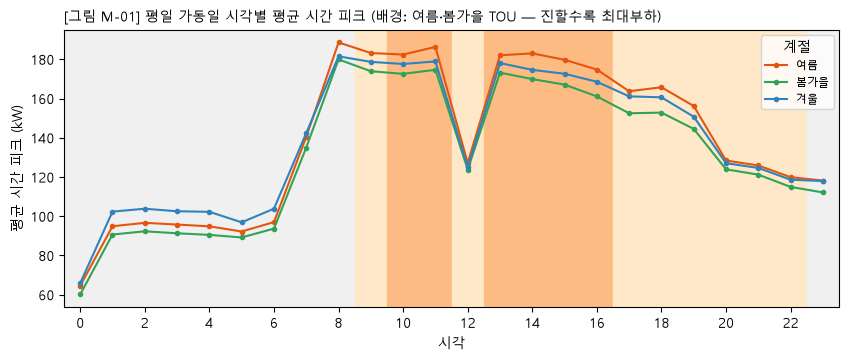

과금 시간(중간·최대부하) 비율: 48.1%


In [9]:
# [코드 M-08] 한전 TOU 시간대 표 [표 M-04]와 평일 시각별 부하 [그림 M-01]
sample = {'여름·봄가을 평일': '2021-06-07', '겨울 평일': '2021-01-04', '토요일': '2021-06-12', '일요일·공휴일': '2021-06-13'}
tbl_m04 = pd.DataFrame({k: df.loc[v, 'tou_load'].to_numpy() for k, v in sample.items()}, index=range(24)).T
tbl_m04.columns = [f'{h}시' for h in range(24)]
print('[표 M-04] 2021 한전 계절·시간대(TOU) 구분')
display(tbl_m04)
pu.save_table(tbl_m04, 'M04_tou_2021', index=True)

ok = df[~df['outage'] & (df['dow'] < 5) & df['op_day']]
fig, ax = plt.subplots(figsize=(10, 3.6))
for season, color in [('여름', '#e6550d'), ('봄가을', '#31a354'), ('겨울', '#3182bd')]:
    ax.plot(ok[ok['tou_season'] == season].groupby('hour')['y'].mean(), marker='o', ms=3, color=color, label=season)
bg = {'경부하': '#f0f0f0', '중간부하': '#fee8c8', '최대부하': '#fdbb84'}
for h, load in enumerate(df.loc['2021-06-07', 'tou_load']):
    ax.axvspan(h - 0.5, h + 0.5, color=bg[load], zorder=0)
ax.set(xlabel='시각', ylabel='평균 시간 피크 (kW)', xticks=range(0, 24, 2), xlim=(-0.5, 23.5))
ax.set_title('[그림 M-01] 평일 가동일 시각별 평균 시간 피크 (배경: 여름·봄가을 TOU — 진할수록 최대부하)',
             loc='left', fontsize=10)
ax.legend(title='계절', fontsize=8)
pu.save_fig(fig, 'M01_hourly_load_tou'); plt.show()
print(f"과금 시간(중간·최대부하) 비율: {df['billing_hour'].mean():.1%}")

## [단계 ③] 예측 문제 정의

두 가지 예측 상황(트랙)을 그림으로 정리합니다. **트랙 A(실시간 경보)**는 매 정시에 다음 1시간의 최대수요전력을, **트랙 B(익일 계획)**는 매일 00시에 그날 24시간을 예측합니다. 예측 시점에 따라 쓸 수 있는 정보가 달라서, 같은 모델이라도 트랙마다 따로 평가합니다. 파란 영역(사용 가능한 정보)이 주황 영역(예측 대상)과 겹치지 않는지 확인합니다.

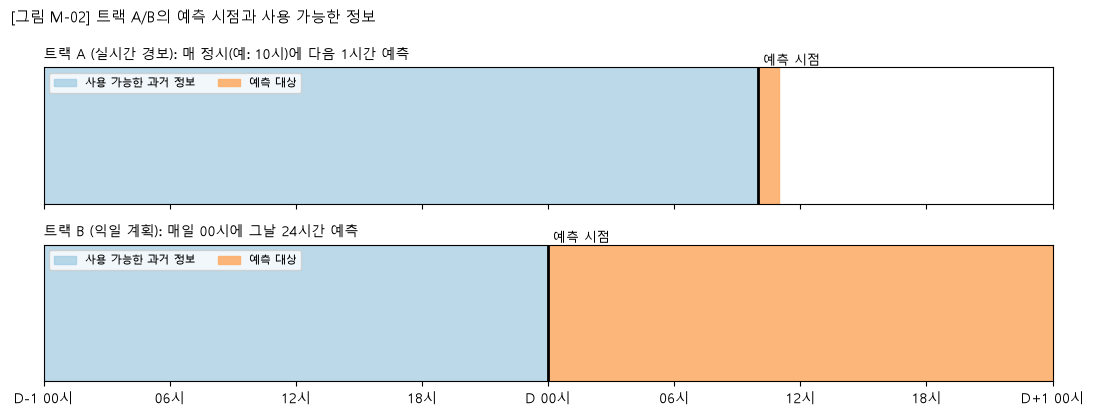

In [10]:
# [코드 M-09] 트랙 A/B 예측 시점 그림 [그림 M-02]
fig = pu.plot_track_timing()
fig.suptitle('[그림 M-02] 트랙 A/B의 예측 시점과 사용 가능한 정보', x=0.01, ha='left', fontsize=11)
fig.tight_layout()
pu.save_fig(fig, 'M02_track_timing'); plt.show()

예측에 쓰는 정보의 범위를 S0·S1·S2 세 단계로 나눕니다. **S1**(당일 생산계획 추가)을 대표 결과로 쓰고, **S2**(당일 가동 여부를 안다고 가정)는 '가동 캘린더를 공유하면 얼마나 좋아지는가'를 보여주는 상한으로만 씁니다. 시나리오가 올라갈수록 정보가 하나씩 추가되며, 기상은 상관이 약해 기본에서 빼고 추가 실험으로만 넣습니다.

In [11]:
# [코드 M-10] 정보 시나리오 표 [표 M-05]
tbl_m05 = pd.DataFrame([
    ['S0', '달력·과거값', '요일·시각·공휴일·TOU, 과거 전력값', '항상 알 수 있음', '기준'],
    ['S1', 'S0 + 당일 생산계획', '당일 생산량 일합계(prod_day)', '전날 생산계획이 확정된다고 가정', '대표 결과'],
    ['S2', 'S1 + 당일 가동 여부', 'op_today, after_shutdown(실제 전력에서 역산)', '가동 캘린더를 공유한다고 가정', '상한(오라클)'],
    ['+기상', '각 시나리오 + 기상', '기온·습도·풍속·강수량 실측', '실측 = 완벽 예보라고 가정', '추가 실험'],
], columns=['시나리오', '정보 범위', '추가 피처', '가정', '용도'])
pu.save_table(tbl_m05, 'M05_info_scenarios')
print('[표 M-05] 정보 시나리오')
display(tbl_m05)

[표 M-05] 정보 시나리오


,시나리오,정보 범위,추가 피처,가정,용도
0,S0,달력·과거값,"요일·시각·공휴일·TOU, 과거 전력값",항상 알 수 있음,기준
1,S1,S0 + 당일 생산계획,당일 생산량 일합계(prod_day),전날 생산계획이 확정된다고 가정,대표 결과
2,S2,S1 + 당일 가동 여부,"op_today, after_shutdown(실제 전력에서 역산)",가동 캘린더를 공유한다고 가정,상한(오라클)
3,+기상,각 시나리오 + 기상,기온·습도·풍속·강수량 실측,실측 = 완벽 예보라고 가정,추가 실험


시간 순서를 지키는 **확장 윈도우 검증**(expanding window: 검증 구간 이전의 모든 데이터로 학습) 6 fold와 테스트 구간을 만듭니다. 각 fold의 피크 임계값 θ는 그 fold 학습 구간 y의 95백분위로 정하고, 테스트(9/1~9/14)는 STEP 7에서 한 번만 평가하므로 여기서는 실제값을 보지 않습니다. fold마다 학습 시간 수가 늘어나는 것과, 학습 구간 기준 θ에 대한 검증 구간의 양성률(피크 비율)이 5%와 얼마나 다른지 봅니다.

In [12]:
# [코드 M-11] 검증 fold 표 [표 M-06]
folds = pu.make_folds(MODE)
rows = []
for _, f in pu.make_folds('full', include_test=True).iterrows():
    tr, va = pu.fold_index(df.index, f)
    y_tr = df.loc[tr, 'y_obs']
    theta = y_tr.quantile(0.95)
    row = {'fold': f['fold'], '평가 구간': f"{f['val_start']:%m/%d}~{f['val_end']:%m/%d}",
           '학습 시간 수': int(y_tr.notna().sum()), 'θ (학습 p95, kW)': theta,
           f'MODE={MODE}에서 사용': f['fold'] in set(folds['fold']) or f['fold'] == 'TEST'}
    if f['fold'] != 'TEST':      # 테스트 구간의 실제값은 STEP 7 전까지 보지 않음
        y_va = df.loc[va, 'y_obs'].dropna()
        row['검증 양성 수'] = int((y_va >= theta).sum())
        row['검증 양성률'] = round(float((y_va >= theta).mean()), 3)
        row['검증 가동일 수'] = int(df.loc[va].groupby('date')['op_day'].first().sum())
    rows.append(row)
tbl_m06 = pd.DataFrame(rows)
pu.save_table(tbl_m06, 'M06_folds')
print(f'[표 M-06] 확장 윈도우 검증 fold (MODE={MODE})')
display(tbl_m06)

[표 M-06] 확장 윈도우 검증 fold (MODE=full)


,fold,평가 구간,학습 시간 수,"θ (학습 p95, kW)",MODE=full에서 사용,검증 양성 수,검증 양성률,검증 가동일 수
0,F1,06/09~06/22,3816,181.0,True,34.0,0.101,10.0
1,F2,06/23~07/06,4152,182.0,True,42.0,0.125,10.0
2,F3,07/07~07/20,4488,182.0,True,63.0,0.188,10.0
3,F4,07/21~08/03,4824,184.0,True,61.0,0.182,8.0
4,F5,08/04~08/17,5160,186.0,True,36.0,0.107,7.0
5,F6,08/18~08/31,5496,186.0,True,28.0,0.088,10.0
6,TEST,09/01~09/14,5813,187.0,True,NaN,NaN,NaN


fold별 학습·검증 구간과 테스트 구간을 시간축에 그리고, 하계휴가·정전·데이터 결손 같은 특이 구간을 회색으로 표시합니다. 휴가가 들어간 fold는 성능이 달라질 수 있어, 전체 평균과 함께 fold별 값·중앙값·가동일만의 지표를 보고하는 이유를 보여주려는 것입니다. 어떤 fold의 검증 구간이 회색 구간과 겹치는지 확인합니다.

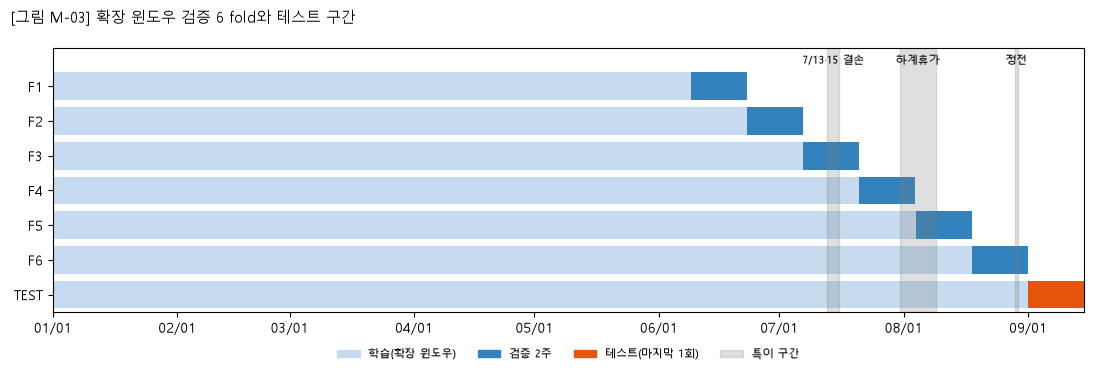

In [13]:
# [코드 M-12] fold 타임라인 그림 [그림 M-03]
fig = pu.plot_fold_timeline(df, pu.make_folds('full', include_test=True))
fig.suptitle('[그림 M-03] 확장 윈도우 검증 6 fold와 테스트 구간', x=0.01, ha='left', fontsize=11)
fig.tight_layout()
pu.save_fig(fig, 'M03_fold_timeline'); plt.show()

트랙(A·B) × 시나리오(S0·S1·S2)마다 허용된 피처만 만들고, 누수(leakage: 예측 시점에 알 수 없는 미래 정보가 섞이는 것)를 두 가지로 검사합니다. (1) **정적 검사**는 피처 가용성 표의 시차가 규칙(트랙 A는 1시간 이상, 트랙 B는 24시간 이상)을 어기면 assert로 멈추고, (2) **동적 검사**는 예측 시점 이후 값을 난수로 바꿔도 과거값 피처가 그대로인지 확인합니다. 6개 조합이 모두 통과하고 마지막 줄에 '의도적 위반 감지'가 나오면, 검사가 실제로 위반을 잡아낸다는 뜻입니다.

In [14]:
# [코드 M-13] 트랙×시나리오별 피처 생성과 누수 검사 (정적 assert + 동적 검사)
avail_all, check_rows = [], []
for track in ['A', 'B']:
    for scenario in ['S0', 'S1', 'S2']:
        X, avail = pu.make_features(df, track, scenario)      # 정적 검사(assert)는 함수 안에서 실행
        n_ok = pu.check_no_leak(df, track, scenario, n_checks=30)
        lag_h = avail.loc[avail['kind'] == 'lag_h', '최소 시차']
        check_rows.append({'트랙': track, '시나리오': scenario, '피처 수': X.shape[1],
                           '최소 시간 시차': int(lag_h.min()), '정적 검사': '통과', '동적 검사': f'{n_ok}회 통과'})
        avail_all.append(avail)
avail_all = pd.concat(avail_all, ignore_index=True)
assert avail_all.query("트랙 == 'B' and kind == 'lag_h'")['최소 시차'].min() >= 24   # 완료 조건
display(pd.DataFrame(check_rows))

# 규칙을 어기면 정말 멈추는지 확인: 트랙 B 표에 1시간 전 값(lag 1)을 일부러 넣어 봄
_, bad = pu.make_features(df, 'B', 'S1')
bad.loc[len(bad)] = {**bad.iloc[-1].to_dict(), '피처': 'y_lag1', '그룹': pu.GROUP_LAG, 'kind': 'lag_h', '최소 시차': 1}
try:
    pu.assert_feature_availability(bad, 'B', 'S1')
except AssertionError as e:
    print(f'의도적 위반 감지 → {e}')

,트랙,시나리오,피처 수,최소 시간 시차,정적 검사,동적 검사
0,A,S0,20,1,통과,30회 통과
1,A,S1,22,1,통과,30회 통과
2,A,S2,24,1,통과,30회 통과
3,B,S0,18,24,통과,30회 통과
4,B,S1,20,24,통과,30회 통과
5,B,S2,22,24,통과,30회 통과


의도적 위반 감지 → 트랙 B에서 예측 시점에 알 수 없는 피처: ['y_lag1']


피처 가용성 표를 저장하고, 대표로 트랙 B·S1 표를 보여줍니다. '종류'는 과거 시차·전날 이전 일 집계·미리 아는 값으로 나뉘며, '미리 아는 값'은 달력처럼 원래 아는 값이거나 시나리오 가정(생산계획 확정, 가동 캘린더 공유)으로 허용한 값입니다. 모든 과거 시차가 24시간 이상인지, 각 피처의 '알 수 있는 이유'가 납득되는지 확인합니다.

In [15]:
# [코드 M-14] 피처 가용성 표 저장과 트랙 B·S1 예시 [표 M-07]
cols = ['트랙', '시나리오', '피처', '그룹', '종류', '최소 시차', '설명', '예측 시점에 알 수 있는 이유']
pu.save_table(avail_all[cols], 'M07_feature_availability')
print('[표 M-07] 피처 가용성 표 — 트랙 B(익일 계획), 시나리오 S1')
print('         (6개 조합 전체는 outputs/tables/M07_feature_availability.csv)')
display(avail_all.query("트랙 == 'B' and 시나리오 == 'S1'")[cols].reset_index(drop=True))
only_a = sorted(set(avail_all.query("트랙 == 'A'")['피처']) - set(avail_all.query("트랙 == 'B'")['피처']))
print('트랙 A에만 있는 피처(1시간 전 값을 쓸 수 있음):', ', '.join(only_a))

[표 M-07] 피처 가용성 표 — 트랙 B(익일 계획), 시나리오 S1
         (6개 조합 전체는 outputs/tables/M07_feature_availability.csv)


,트랙,시나리오,피처,그룹,종류,최소 시차,설명,예측 시점에 알 수 있는 이유
0,B,S1,hour,달력,미리 아는 값,NaN,대상 시각(0~23),달력·요금표로 미리 앎
1,B,S1,dow,달력,미리 아는 값,NaN,요일(0=월),달력·요금표로 미리 앎
2,B,S1,month,달력,미리 아는 값,NaN,월,달력·요금표로 미리 앎
3,B,S1,weekend,달력,미리 아는 값,NaN,토·일,달력·요금표로 미리 앎
4,B,S1,holiday,달력,미리 아는 값,NaN,공휴일·대체공휴일,달력·요금표로 미리 앎
5,B,S1,shift,달력,미리 아는 값,NaN,주간 교대(09~17시),달력·요금표로 미리 앎
6,B,S1,tou_season,달력,미리 아는 값,NaN,한전 계절(0 겨울·1 봄가을·2 여름),달력·요금표로 미리 앎
7,B,S1,tou_load,달력,미리 아는 값,NaN,한전 시간대(0 경부하·1 중간·2 최대),달력·요금표로 미리 앎
8,B,S1,billing_hour,달력,미리 아는 값,NaN,기본요금 반영 시간(중간·최대부하),달력·요금표로 미리 앎
9,B,S1,y_d1,과거값,과거 시차(시간),24.0,1일 전 같은 시각,24시간 전 값 → 00시 기준 전날 23시까지의 값만 사용


트랙 A에만 있는 피처(1시간 전 값을 쓸 수 있음): q4_lag1, q_min_lag1, q_slope_lag1, y_lag1, y_lag168, y_lag2, y_lag24, y_lag3, y_ma24, y_ma3, y_ma6


## [단계 ④] 나이브 기준선 3종

모델 없이 과거값을 그대로 쓰는 나이브(naive) 기준선 3종을 만듭니다: **직전값**(트랙 B는 전날 23시 값), **1주 전 같은 시각**, **최근 4주 같은 요일·시각 평균**. 각 검증 fold에서 회귀·분류 지표를 계산해 `outputs/tables/cv_scores.csv`를 시작하고, 예측값은 조건 컬럼(시각·요일·TOU·가동 여부 등)과 함께 `outputs/preds/`에 저장합니다. 이후 모델이 '아무것도 안 한 예측'보다 얼마나 나은지 판단하는 기준이 됩니다.

In [16]:
# [코드 M-15] 기준선 3종을 검증 fold별로 평가하고 cv_scores.csv·oof 예측 저장
import time
t0 = time.time()
base_scores = pu.run_baselines(df, folds)        # 테스트 구간이 섞이면 함수 안의 assert가 멈춤
print(f'기준선 평가 완료: {time.time() - t0:.1f}초, {base_scores["fold"].nunique()} fold × 3 모델 × 2 트랙')
print(f'저장: {pu.CV_PATH.relative_to(ROOT)}, outputs/preds/oof_naive_*_S0.parquet')
show = ['model', 'track', 'fold', 'n', 'n_pos', 'theta', 'mae', 'mase', 'peak_mae', 'f1', 'pr_auc']
display(base_scores.query("subset == 'all' and model == 'naive_week'")[show].round(3))

기준선 평가 완료: 4.0초, 6 fold × 3 모델 × 2 트랙
저장: outputs\tables\cv_scores.csv, outputs/preds/oof_naive_*_S0.parquet


,model,track,fold,n,n_pos,theta,mae,mase,peak_mae,f1,pr_auc
36,naive_week,A,F1,336,34.0,181.0,7.926,0.367,13.917,0.370,0.515
39,naive_week,A,F2,336,42.0,182.0,7.720,0.377,11.484,0.561,0.653
42,naive_week,A,F3,336,63.0,182.0,11.863,0.609,19.588,0.544,0.557
45,naive_week,A,F4,336,61.0,184.0,26.935,1.423,16.123,0.662,0.604
48,naive_week,A,F5,336,36.0,186.0,75.878,3.898,164.048,0.027,0.087
51,naive_week,A,F6,317,28.0,186.0,9.527,0.414,14.746,0.179,0.225
54,naive_week,B,F1,336,34.0,181.0,7.926,0.367,13.917,0.370,0.515
57,naive_week,B,F2,336,42.0,182.0,7.720,0.377,11.484,0.561,0.653
60,naive_week,B,F3,336,63.0,182.0,11.863,0.609,19.588,0.544,0.557
63,naive_week,B,F4,336,61.0,184.0,26.935,1.423,16.123,0.662,0.604


fold별 결과를 모델×트랙별 '평균 ± 표준편차'와 중앙값으로 요약합니다. MASE(Mean Absolute Scaled Error: 오차를 '1주 전 값 예측'의 학습 구간 오차로 나눈 값)가 1보다 작으면 1주 나이브보다 낫다는 뜻이고, 기준선의 F1은 '점예측이 θ 이상이면 경보'로 계산했습니다. 전체(all)와 가동일(op) 성능을 비교하고, 이후 STEP의 모델이 이 표의 가장 좋은 기준선을 넘는지를 첫 번째 관문으로 삼습니다.

In [17]:
# [코드 M-16] 기준선 요약표: 전체·가동일 [표 M-08]
tables = []
for subset, label in [('all', '전체'), ('op', '가동일')]:
    t = pu.summarize_scores(base_scores, subset=subset, metrics=('mae', 'mase', 'peak_mae', 'f1'))
    t.insert(0, '평가 대상', label)
    tables.append(t)
tbl_m08 = pd.concat(tables, ignore_index=True)
tbl_m08['model'] = tbl_m08['model'].map(pu.BASELINES)
print('[표 M-08] 나이브 기준선 검증 성능 (fold 평균 ± 표준편차, 중앙값, outage 제외)')
display(tbl_m08)
pu.save_table(tbl_m08, 'M08_baseline_summary')
mean_mae = base_scores.query("subset == 'all'").groupby(['track', 'model'])['mae'].mean()
for track in ['A', 'B']:
    m = mean_mae[track].idxmin()
    print(f'트랙 {track} 최고 기준선(평균 MAE): {pu.BASELINES[m]} — {mean_mae[track][m]:.2f} kW')

[표 M-08] 나이브 기준선 검증 성능 (fold 평균 ± 표준편차, 중앙값, outage 제외)


,평가 대상,model,track,scenario,mae 평균±표준편차,mae 중앙값,mase 평균±표준편차,mase 중앙값,peak_mae 평균±표준편차,peak_mae 중앙값,f1 평균±표준편차,f1 중앙값,fold 수
0,전체,최근 4주 같은 요일·시각 평균,A,S0,19.958 ± 13.113,17.584,0.988 ± 0.683,0.781,25.891 ± 14.062,20.363,0.225 ± 0.229,0.226,6
1,전체,최근 4주 같은 요일·시각 평균,B,S0,19.958 ± 13.113,17.584,0.988 ± 0.683,0.781,25.891 ± 14.062,20.363,0.225 ± 0.229,0.226,6
2,전체,직전값,A,S0,13.887 ± 1.802,14.189,0.679 ± 0.09,0.662,19.719 ± 1.549,19.118,0.548 ± 0.11,0.541,6
3,전체,직전값,B,S0,40.787 ± 4.815,41.016,1.994 ± 0.239,1.952,90.963 ± 7.357,90.403,0.03 ± 0.074,0.000,6
4,전체,1주 전 같은 시각,A,S0,23.308 ± 26.748,10.695,1.181 ± 1.39,0.511,39.984 ± 60.837,15.435,0.391 ± 0.246,0.457,6
5,전체,1주 전 같은 시각,B,S0,23.308 ± 26.748,10.695,1.181 ± 1.39,0.511,39.984 ± 60.837,15.435,0.391 ± 0.246,0.457,6
6,가동일,최근 4주 같은 요일·시각 평균,A,S0,16.859 ± 7.427,14.203,0.817 ± 0.337,0.689,25.891 ± 14.062,20.363,0.234 ± 0.243,0.226,6
7,가동일,최근 4주 같은 요일·시각 평균,B,S0,16.859 ± 7.427,14.203,0.817 ± 0.337,0.689,25.891 ± 14.062,20.363,0.234 ± 0.243,0.226,6
8,가동일,직전값,A,S0,18.438 ± 1.245,18.673,0.907 ± 0.122,0.936,19.719 ± 1.549,19.118,0.548 ± 0.11,0.541,6
9,가동일,직전값,B,S0,48.363 ± 3.92,47.969,2.377 ± 0.32,2.350,90.963 ± 7.357,90.403,0.03 ± 0.074,0.000,6


트랙 A 최고 기준선(평균 MAE): 직전값 — 13.89 kW
트랙 B 최고 기준선(평균 MAE): 최근 4주 같은 요일·시각 평균 — 19.96 kW


fold별 MAE를 기준선·트랙별로 그립니다. 평균만 보면 휴가·정전이 들어간 fold의 영향을 놓치기 쉬워서, fold마다 성능이 얼마나 흔들리는지 함께 봐야 합니다. 특정 fold에서 모든 기준선의 오차가 함께 커지면 그 구간 자체가 예측하기 어려운 구간(휴가 직후 등)이라는 뜻입니다.

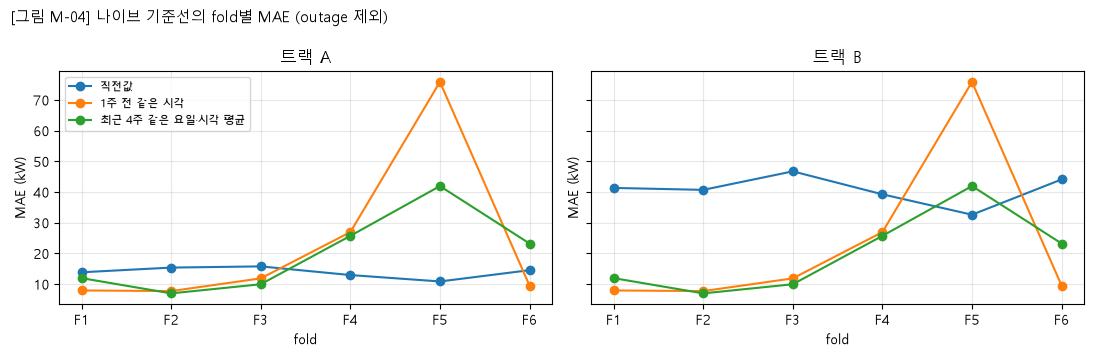

In [18]:
# [코드 M-17] fold별 기준선 MAE 그림 [그림 M-04]
s = base_scores.query("subset == 'all'")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, track in zip(axes, ['A', 'B']):
    for model, label in pu.BASELINES.items():
        d = s[(s['track'] == track) & (s['model'] == model)]
        ax.plot(d['fold'], d['mae'], marker='o', label=label)
    ax.set(title=f'트랙 {track}', xlabel='fold', ylabel='MAE (kW)')
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle('[그림 M-04] 나이브 기준선의 fold별 MAE (outage 제외)', x=0.01, ha='left', fontsize=11)
fig.tight_layout()
pu.save_fig(fig, 'M04_baseline_mae_by_fold'); plt.show()

STEP 1의 완료 조건 세 가지를 코드로 다시 확인합니다. 세 줄 모두 '통과'가 나와야 다음 단계(STEP 2: 가이드북 베이스라인 재평가)로 넘어갑니다.

In [19]:
# [코드 M-18] STEP 1 완료 조건 점검
cv = pd.read_csv(pu.CV_PATH, encoding='utf-8-sig')
base_cv = cv[cv['model'].isin(list(pu.BASELINES))]
checks = {
    '시간 피크 6,168개·15분 24,672개·완전 정전 17시간': (n_hour, n_q15, n_full) == (6168, 24672, 17),
    '트랙 B 피처에 lag<24 없음(정적 assert + 동적 검사)':
        avail_all.query("트랙 == 'B' and kind == 'lag_h'")['최소 시차'].min() >= 24,
    '기준선 결과가 fold별로 저장됨': bool(base_cv.groupby(['model', 'track'])['fold'].nunique().eq(len(folds)).all()),
}
for name, ok in checks.items():
    print(f"{'통과' if ok else '실패'} | {name}")
assert all(checks.values())

통과 | 시간 피크 6,168개·15분 24,672개·완전 정전 17시간
통과 | 트랙 B 피처에 lag<24 없음(정적 assert + 동적 검사)
통과 | 기준선 결과가 fold별로 저장됨


## [단계 ⑤] 가이드북 베이스라인을 같은 조건에서 다시 평가

가이드북의 RNN과 RF는 타깃과 분할 방식이 서로 다르고, 이 노트북의 기준과도 달라 수치를 그대로 비교할 수 없습니다. 그래서 **모델 구조는 그대로 두고** 타깃(시간 피크 y), 검증 방식(확장 윈도우 6 fold), 전처리(학습 구간에서만 fit) 조건만 맞춰 다시 평가합니다. 학습은 시간이 오래 걸려 `scripts/train_guidebook_rnn.py`·`scripts/train_guidebook_rf.py`로 따로 돌렸고(로그: `outputs/logs/`), 여기서는 저장된 결과를 불러와 보여줍니다.

RNN은 가이드북처럼 500 epoch를 고정하지 않고, 학습 구간 마지막 2주를 검증으로 떼어 검증 손실이 30 epoch 동안 나아지지 않으면 멈추는 **early stopping**(조기 종료)으로 학습했습니다. fold·seed마다 가장 좋았던 epoch(best epoch)를 기록하고, 테스트용 재학습 epoch는 이 값들의 중앙값으로 고정합니다(STEP 7에서 사용). best epoch가 fold마다 크게 다르면 구간에 따라 학습 난이도가 다르다는 뜻이고, 멈춘 epoch가 500이면 더 학습할 여지가 있었다는 뜻입니다.

In [20]:
# [코드 M-19] RNN 학습 기록 불러오기: fold·seed별 best epoch [표 M-09]
import json
rnn_epochs = pd.read_csv(pu.OUT / 'tables' / 'guidebook_rnn_epochs.csv', encoding='utf-8-sig')
rnn_summary = json.loads((pu.OUT / 'logs' / 'guidebook_rnn_summary.json').read_text(encoding='utf-8'))
tbl_m09 = rnn_epochs.pivot_table(index='fold', columns='seed', values=['best_epoch', 'stopped_epoch', 'train_sec'])
tbl_m09.columns = [f'{a}_s{b}' for a, b in tbl_m09.columns]
pu.save_table(tbl_m09.reset_index(), 'M09_rnn_best_epochs')
print('[표 M-09] 가이드북 RNN fold·seed별 best epoch, 멈춘 epoch, 학습 시간(초)')
display(tbl_m09)
print(f"테스트 재학습 epoch(best epoch 중앙값): {rnn_summary['test_refit_epochs']} | "
      f"500 epoch까지 간 학습: {int((rnn_epochs['stopped_epoch'] >= 500).sum())}회 / {len(rnn_epochs)}회 | "
      f"학습 시간 합계 {rnn_summary['train_sec_sum'] / 60:.0f}분(CPU)")

[표 M-09] 가이드북 RNN fold·seed별 best epoch, 멈춘 epoch, 학습 시간(초)


,best_epoch_s42,best_epoch_s2021,best_epoch_s2024,stopped_epoch_s42,stopped_epoch_s2021,stopped_epoch_s2024,train_sec_s42,train_sec_s2021,train_sec_s2024
fold,,,,,,,,,
F1,159.0,317.0,228.0,189.0,347.0,258.0,380.9,532.0,401.7
F2,301.0,276.0,161.0,331.0,306.0,191.0,645.0,514.0,314.1
F3,189.0,252.0,449.0,219.0,282.0,479.0,493.2,510.7,857.1
F4,160.0,104.0,168.0,190.0,134.0,198.0,463.8,261.6,382.3
F5,106.0,151.0,85.0,136.0,181.0,115.0,377.2,387.0,234.3
F6,38.0,181.0,30.0,68.0,211.0,60.0,226.7,494.3,139.3


테스트 재학습 epoch(best epoch 중앙값): 164 | 500 epoch까지 간 학습: 0회 / 18회 | 학습 시간 합계 127분(CPU)


대표로 테스트 직전 fold인 F6의 학습 곡선(epoch마다 학습 손실과 검증 손실)을 그립니다. 손실은 0~1로 바꾼 값의 MSE이고, 점선 세로줄이 검증 손실이 가장 낮았던 best epoch입니다. 학습 손실은 계속 줄어드는데 검증 손실이 다시 올라가면 과적합(학습 데이터만 외우는 상태)이 시작된 것입니다.

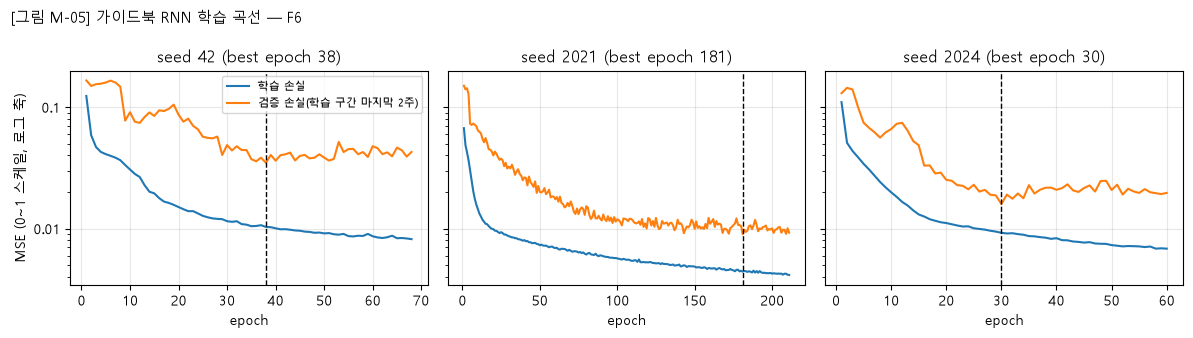

In [21]:
# [코드 M-20] 대표 fold(F6) 학습 곡선 [그림 M-05]
from matplotlib.ticker import FuncFormatter
hist = pd.read_csv(pu.OUT / 'logs' / 'guidebook_rnn_history.csv', encoding='utf-8-sig')
rep = 'F6'
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, (seed, h) in zip(axes, hist[hist['fold'] == rep].groupby('seed')):
    ax.plot(h['epoch'], h['loss'], label='학습 손실')
    ax.plot(h['epoch'], h['val_loss'], label='검증 손실(학습 구간 마지막 2주)')
    best = int(rnn_epochs.loc[(rnn_epochs['fold'] == rep) & (rnn_epochs['seed'] == seed), 'best_epoch'].iloc[0])
    ax.axvline(best, color='k', ls='--', lw=1)
    ax.set(title=f'seed {seed} (best epoch {best})', xlabel='epoch', yscale='log')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))     # 로그 눈금을 0.01처럼 표시
    ax.yaxis.set_minor_formatter(FuncFormatter(lambda v, _: ''))
    ax.grid(alpha=0.3)
axes[0].set_ylabel('MSE (0~1 스케일, 로그 축)')
axes[0].legend(fontsize=8)
fig.suptitle(f'[그림 M-05] 가이드북 RNN 학습 곡선 — {rep}', x=0.01, ha='left', fontsize=11)
fig.tight_layout()
pu.save_fig(fig, 'M05_rnn_learning_curve'); plt.show()

가이드북 RNN·RF의 검증 성능을 나이브 기준선과 같은 표에 놓습니다. RNN 트랙 A는 매 시각 실제 직전 168시간을 넣어 1시간 앞을 예측하고, 트랙 B는 1시간 앞 모델을 24번 이어 붙이는 **재귀 예측**(앞 시간의 예측값을 다음 시간의 입력으로 사용)이라 오차가 쌓입니다. RF는 트랙 A만 평가했습니다. MASE가 1보다 작은지, 그리고 가이드북 모델이 같은 트랙의 가장 좋은 기준선보다 나은지 봅니다.

In [22]:
# [코드 M-21] 가이드북 RNN·RF vs 나이브 기준선 (트랙 A·B) [표 M-10]
cv = pd.read_csv(pu.CV_PATH, encoding='utf-8-sig')
names = {'guidebook_rnn': '가이드북 RNN', 'guidebook_rf': '가이드북 RF', **pu.BASELINES}
sub = cv[cv['model'].isin(list(names))]
tables = []
for subset, label in [('all', '전체'), ('op', '가동일')]:
    t = pu.summarize_scores(sub, subset=subset, metrics=('mae', 'mase', 'peak_mae', 'f1'))
    t.insert(0, '평가 대상', label)
    tables.append(t)
tbl_m10 = pd.concat(tables, ignore_index=True).sort_values(['평가 대상', 'track', 'mae 중앙값'], ignore_index=True)
tbl_m10['model'] = tbl_m10['model'].map(names)
pu.save_table(tbl_m10, 'M10_guidebook_vs_baselines')
print('[표 M-10] 가이드북 모델과 나이브 기준선의 검증 성능 (RNN: fold 6 × seed 3, RF: fold 6 × seed 5)')
display(tbl_m10.drop(columns='scenario'))
mean_mae = sub.query("subset == 'all'").groupby(['track', 'model'])['mae'].mean()
for tr in ['A', 'B']:
    base = mean_mae[tr][list(pu.BASELINES)]
    guide = ', '.join(f'{names[m]} {mean_mae[tr][m]:.2f}' for m in ['guidebook_rnn', 'guidebook_rf'] if m in mean_mae[tr])
    print(f'트랙 {tr} 평균 MAE(kW): {guide} | 최고 기준선 {pu.BASELINES[base.idxmin()]} {base.min():.2f}')

[표 M-10] 가이드북 모델과 나이브 기준선의 검증 성능 (RNN: fold 6 × seed 3, RF: fold 6 × seed 5)


,평가 대상,model,track,mae 평균±표준편차,mae 중앙값,mase 평균±표준편차,mase 중앙값,peak_mae 평균±표준편차,peak_mae 중앙값,f1 평균±표준편차,f1 중앙값,fold 수
0,가동일,가이드북 RF,A,8.802 ± 2.267,8.189,0.437 ± 0.134,0.397,10.656 ± 2.702,9.871,0.667 ± 0.108,0.638,6
1,가동일,가이드북 RNN,A,14.409 ± 8.835,11.230,0.719 ± 0.468,0.541,20.257 ± 18.117,14.225,0.379 ± 0.221,0.430,6
2,가동일,1주 전 같은 시각,A,24.841 ± 31.959,12.336,1.253 ± 1.655,0.600,39.984 ± 60.837,15.435,0.407 ± 0.263,0.457,6
3,가동일,최근 4주 같은 요일·시각 평균,A,16.859 ± 7.427,14.203,0.817 ± 0.337,0.689,25.891 ± 14.062,20.363,0.234 ± 0.243,0.226,6
4,가동일,직전값,A,18.438 ± 1.245,18.673,0.907 ± 0.122,0.936,19.719 ± 1.549,19.118,0.548 ± 0.11,0.541,6
5,가동일,1주 전 같은 시각,B,24.841 ± 31.959,12.336,1.253 ± 1.655,0.600,39.984 ± 60.837,15.435,0.407 ± 0.263,0.457,6
6,가동일,최근 4주 같은 요일·시각 평균,B,16.859 ± 7.427,14.203,0.817 ± 0.337,0.689,25.891 ± 14.062,20.363,0.234 ± 0.243,0.226,6
7,가동일,가이드북 RNN,B,23.86 ± 18.088,17.700,1.186 ± 0.943,0.886,39.521 ± 36.508,23.310,0.303 ± 0.196,0.327,6
8,가동일,직전값,B,48.363 ± 3.92,47.969,2.377 ± 0.32,2.350,90.963 ± 7.357,90.403,0.03 ± 0.074,0.000,6
9,전체,가이드북 RF,A,7.683 ± 2.32,6.410,0.381 ± 0.135,0.302,10.656 ± 2.702,9.871,0.667 ± 0.108,0.638,6


트랙 A 평균 MAE(kW): 가이드북 RNN 12.54, 가이드북 RF 7.68 | 최고 기준선 직전값 13.89
트랙 B 평균 MAE(kW): 가이드북 RNN 23.12 | 최고 기준선 최근 4주 같은 요일·시각 평균 19.96


트랙 B 재귀 예측의 한계를 보기 위해, 00시 예측 시점부터 몇 시간 뒤를 예측하는지(**예측 거리**)에 따라 MAE가 어떻게 변하는지 그립니다. 같은 시각을 트랙 A(매번 실제값으로 1시간 앞 예측)와 4주 평균 기준선과 비교하므로, 시각마다 원래 예측하기 쉬운지 어려운지의 차이는 서로 상쇄됩니다. 트랙 B RNN 선이 예측 거리가 길어질수록 트랙 A 선에서 멀어지면 재귀 예측의 오차가 쌓인 것입니다.

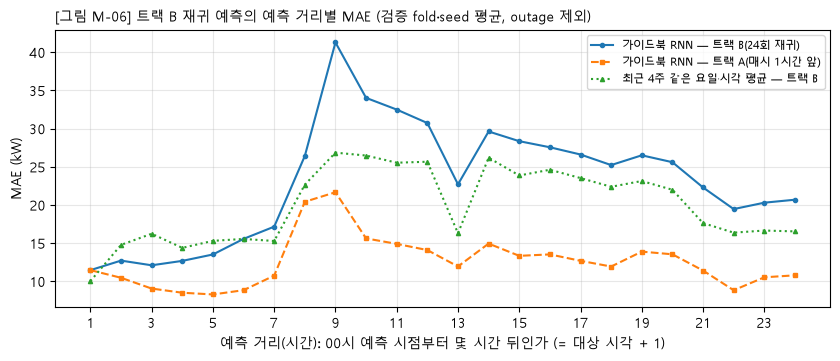

 1시간 뒤: 트랙 B  11.47 kW | 같은 시각 트랙 A  11.47 kW
 6시간 뒤: 트랙 B  15.56 kW | 같은 시각 트랙 A   8.84 kW
12시간 뒤: 트랙 B  30.74 kW | 같은 시각 트랙 A  14.10 kW
24시간 뒤: 트랙 B  20.69 kW | 같은 시각 트랙 A  10.79 kW


In [23]:
# [코드 M-22] 트랙 B 재귀 예측의 오차 누적: 예측 거리별 MAE [그림 M-06]
lines = {'가이드북 RNN — 트랙 B(24회 재귀)': pu.mae_by('guidebook_rnn', 'B', 'hour'),
         '가이드북 RNN — 트랙 A(매시 1시간 앞)': pu.mae_by('guidebook_rnn', 'A', 'hour'),
         '최근 4주 같은 요일·시각 평균 — 트랙 B': pu.mae_by('naive_4wk', 'B', 'hour')}
fig, ax = plt.subplots(figsize=(10, 3.6))
for (label, s), style in zip(lines.items(), ['-o', '--s', ':^']):
    ax.plot(s.index + 1, s.to_numpy(), style, ms=3, label=label)
ax.set(xlabel='예측 거리(시간): 00시 예측 시점부터 몇 시간 뒤인가 (= 대상 시각 + 1)', ylabel='MAE (kW)',
       xticks=range(1, 25, 2))
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
ax.set_title('[그림 M-06] 트랙 B 재귀 예측의 예측 거리별 MAE (검증 fold·seed 평균, outage 제외)', loc='left', fontsize=10)
pu.save_fig(fig, 'M06_rnn_recursive_error'); plt.show()
b, a = lines['가이드북 RNN — 트랙 B(24회 재귀)'], lines['가이드북 RNN — 트랙 A(매시 1시간 앞)']
for h in (1, 6, 12, 24):
    print(f'{h:>2}시간 뒤: 트랙 B {b.iloc[h - 1]:6.2f} kW | 같은 시각 트랙 A {a.iloc[h - 1]:6.2f} kW')

가이드북 RF를 시간 단위로 옮겨 (a) 가이드북처럼 **무작위로 70:30**을 나눈 경우와 (b) 시간 순서를 지킨 **확장 윈도우 fold**로 평가한 경우를 한 표에 둡니다. 모델·피처·seed는 같고 데이터를 나누는 방식만 다르며, 무작위 분할도 테스트 구간(9/1~9/14)은 빼고 나눴습니다. 다만 (a)는 1~8월 전체에서 평가하고 (b)는 6~8월만 평가하므로, 기간 차이를 없애려고 (a)의 평가 행 중 (b)와 같은 기간에 속한 행만 다시 채점한 결과도 함께 둡니다. 학습 MAE와 평가 MAE의 차이, 그리고 같은 기간끼리의 평가 MAE 차이를 봅니다.

In [24]:
# [코드 M-23] 가이드북 RF: 무작위 70:30 분할 vs 시간 fold [표 M-11]
rf = pd.read_csv(pu.OUT / 'tables' / 'guidebook_rf_split_scores.csv', encoding='utf-8-sig').query("subset == 'all'")
metrics = {'train_mae': '학습 MAE', 'mae': '평가 MAE', 'rmse': '평가 RMSE', 'peak_mae': '피크시간 MAE',
           'f1': 'F1', 'pr_auc': 'PR-AUC'}
g = rf.groupby('split')
tbl_m11 = pd.DataFrame({v: g[k].mean().round(3).astype(str) + ' ± ' + g[k].std().round(3).astype(str)
                        for k, v in metrics.items()})
tbl_m11['평가 표본 수(1회 평균)'] = g['n'].mean().round(0).astype(int)
tbl_m11['반복 수'] = g.size()
split_order = ['무작위 70:30', '무작위 70:30(검증 기간 행만)', '시간 fold']
tbl_m11 = tbl_m11.loc[split_order]
pu.save_table(tbl_m11.reset_index(), 'M11_rf_random_vs_time')
print('[표 M-11] 가이드북 RF(트랙 A, 시간 단위) — 분할 방식만 다르게 한 비교 (평균 ± 표준편차)')
display(tbl_m11)
m = g['mae'].mean()
same, tf = m['무작위 70:30(검증 기간 행만)'], m['시간 fold']
print(f'같은 기간(검증 6 fold 구간) 평가 MAE: 무작위 분할 {same:.2f} kW vs 시간 fold {tf:.2f} kW '
      f'→ 무작위 분할이 {(tf - same) / tf:.0%} 작게 보임')

[표 M-11] 가이드북 RF(트랙 A, 시간 단위) — 분할 방식만 다르게 한 비교 (평균 ± 표준편차)


,학습 MAE,평가 MAE,평가 RMSE,피크시간 MAE,F1,PR-AUC,평가 표본 수(1회 평균),반복 수
split,,,,,,,,
무작위 70:30,2.38 ± 0.085,6.503 ± 0.254,14.062 ± 1.144,10.656 ± 1.275,0.606 ± 0.057,0.68 ± 0.034,1744,5
무작위 70:30(검증 기간 행만),2.38 ± 0.085,6.214 ± 0.232,10.538 ± 0.772,9.417 ± 0.612,0.695 ± 0.046,0.778 ± 0.049,604,5
시간 fold,2.233 ± 0.045,7.683 ± 2.32,12.704 ± 4.505,10.656 ± 2.702,0.667 ± 0.108,0.774 ± 0.133,333,30


같은 기간(검증 6 fold 구간) 평가 MAE: 무작위 분할 6.21 kW vs 시간 fold 7.68 kW → 무작위 분할이 19% 작게 보임


위 표를 그림으로 봅니다. 막대는 평균, 점은 seed 하나(무작위 분할) 또는 fold×seed 하나(시간 fold)의 결과입니다. 무작위 분할의 점들이 좁게 모여 있고 시간 fold의 점들이 넓게 퍼져 있다면, 무작위 분할은 비슷한 '쉬운 문제'를 여러 번 푼 것이고 시간 fold는 구간마다 다른 실제 난이도를 반영한 것입니다.

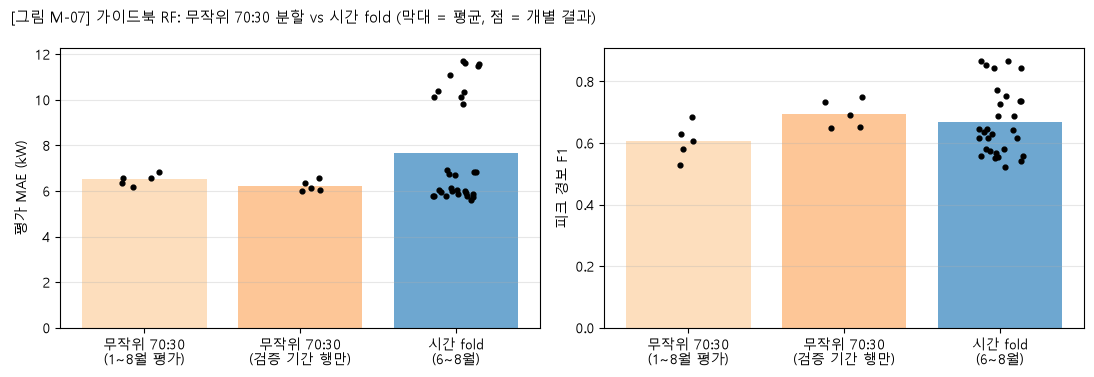

In [25]:
# [코드 M-24] 무작위 분할 vs 시간 fold 그림 [그림 M-07]
order, rng = split_order, np.random.default_rng(0)
labels = ['무작위 70:30\n(1~8월 평가)', '무작위 70:30\n(검증 기간 행만)', '시간 fold\n(6~8월)']
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (col, label) in zip(axes, [('mae', '평가 MAE (kW)'), ('f1', '피크 경보 F1')]):
    ax.bar(labels, rf.groupby('split')[col].mean().loc[order], color=['#fdd0a2', '#fdae6b', '#3182bd'], alpha=0.7)
    for i, sp in enumerate(order):
        v = rf.loc[rf['split'] == sp, col].to_numpy()
        ax.scatter(i + rng.uniform(-0.15, 0.15, len(v)), v, s=12, color='k', zorder=3)
    ax.set(ylabel=label)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('[그림 M-07] 가이드북 RF: 무작위 70:30 분할 vs 시간 fold (막대 = 평균, 점 = 개별 결과)',
             x=0.01, ha='left', fontsize=11)
fig.tight_layout()
pu.save_fig(fig, 'M07_rf_random_vs_time'); plt.show()

### 왜 무작위 분할은 성능을 부풀릴까?

전력 수요는 바로 앞뒤 시간끼리 값이 거의 비슷합니다. 무작위로 70:30을 나누면 평가용 10시 데이터의 바로 앞(9시)과 뒤(11시) 데이터가 학습에 들어가 있어, 모델은 '그날 그 무렵의 수준'을 이미 본 상태로 문제를 풉니다. 시험 문제의 앞뒤 문항 답을 미리 보고 시험을 치르는 것과 같아서, 실제로 내일을 예측할 때보다 오차가 작게 나옵니다. 그래서 시계열 예측은 반드시 과거 데이터로 학습하고 그 이후 기간으로 평가하는 시간 순서 분할로 성능을 재야 합니다.

가이드북 원래 수치와 이번 재평가 결과가 왜 다른지 항목별로 정리합니다. 원래 수치는 베이스라인 노트북의 실행 결과 표를 코드로 그대로 읽어 왔고(`pu.guidebook_reference()`), 이번 결과는 `cv_scores.csv`와 RF 분할 비교 결과에서 계산했습니다. 평가 구간(테스트 9/1~9/14 vs 검증 6 fold)이 서로 달라 두 숫자를 곧바로 비교하면 안 되며, 같은 테스트 구간 비교는 STEP 7에서 한 번만 합니다.

In [26]:
# [코드 M-25] 가이드북 원래 수치와 달라진 점 [표 M-12]
ref = pu.guidebook_reference()
rnn_ref = ref[ref['모델'].str.contains('RNN')].iloc[0]
rf_ref = ref[ref['평가 데이터'].str.contains('검증')].iloc[0]
r = cv.query("model == 'guidebook_rnn' and subset == 'all'").groupby('track')['mae'].agg(['mean', 'std'])
f = rf.groupby('split')['mae'].mean()
tbl_m12 = pd.DataFrame([
    ['RNN', '타깃', "'15분' 컬럼(다음 시간의 첫 15분 구간)", '시간 피크 y = max(15·30·45·60분)'],
    ['RNN', '스케일러', '전체 구간(테스트 포함)으로 fit', 'fold 학습 구간으로만 fit'],
    ['RNN', 'epoch', '500 고정', 'early stopping(마지막 2주 검증, patience 30), 테스트용은 best epoch 중앙값'],
    ['RNN', '평가', '테스트 9/1~9/14 1회, seed 1개', '검증 6 fold × seed 3개, 트랙 A·B'],
    ['RNN', 'MAE (kW)', f"{rnn_ref['MAE']:.2f} ({rnn_ref['평가 데이터']})",
     f"트랙 A {r.loc['A', 'mean']:.2f} ± {r.loc['A', 'std']:.2f} / 트랙 B {r.loc['B', 'mean']:.2f} ± {r.loc['B', 'std']:.2f} (검증)"],
    ['RF', '단위·타깃', '15분 단위, 다음 15분 값', '1시간 단위, 다음 시간 피크 y(직전 시각 피처)'],
    ['RF', '분할', '무작위 70:30(9/1~9/14 포함)', '(a) 무작위 70:30(테스트 제외) / (b) 시간 fold 6개'],
    ['RF', 'MAE (kW)', f"{rf_ref['MAE']:.2f} ({rf_ref['평가 데이터']})",
     f"(a) {f['무작위 70:30']:.2f} (같은 기간 행만 {f['무작위 70:30(검증 기간 행만)']:.2f}) / (b) {f['시간 fold']:.2f}"],
], columns=['모델', '항목', '가이드북(베이스라인 노트북)', '이번 재평가'])
pu.save_table(tbl_m12, 'M12_guidebook_changes')
print('[표 M-12] 가이드북 원래 수치와 달라진 점 (원래 수치는 베이스라인 노트북 실행 출력에서 읽음)')
display(tbl_m12)

[표 M-12] 가이드북 원래 수치와 달라진 점 (원래 수치는 베이스라인 노트북 실행 출력에서 읽음)


,모델,항목,가이드북(베이스라인 노트북),이번 재평가
0,RNN,타깃,'15분' 컬럼(다음 시간의 첫 15분 구간),시간 피크 y = max(15·30·45·60분)
1,RNN,스케일러,전체 구간(테스트 포함)으로 fit,fold 학습 구간으로만 fit
2,RNN,epoch,500 고정,"early stopping(마지막 2주 검증, patience 30), 테스트용은 ..."
3,RNN,평가,"테스트 9/1~9/14 1회, seed 1개","검증 6 fold × seed 3개, 트랙 A·B"
4,RNN,MAE (kW),7.16 (테스트 2021-09-01 ~ 09-14),트랙 A 12.54 ± 5.75 / 트랙 B 23.12 ± 13.73 (검증)
5,RF,단위·타깃,"15분 단위, 다음 15분 값","1시간 단위, 다음 시간 피크 y(직전 시각 피처)"
6,RF,분할,무작위 70:30(9/1~9/14 포함),(a) 무작위 70:30(테스트 제외) / (b) 시간 fold 6개
7,RF,MAE (kW),7.16 (검증 30%),(a) 6.50 (같은 기간 행만 6.21) / (b) 7.68


STEP 2의 완료 조건 두 가지를 코드로 확인합니다. 모두 '통과'가 나와야 다음 단계(STEP 3: 통계·트리 앙상블)로 넘어갑니다.

In [27]:
# [코드 M-26] STEP 2 완료 조건 점검
cv = pd.read_csv(pu.CV_PATH, encoding='utf-8-sig')
n = cv.query("subset == 'all'").groupby(['model', 'track'])['fold'].nunique()
checks = {
    "cv_scores.csv에 model='guidebook_rnn'(트랙 A·B) 추가":
        all(n.get(('guidebook_rnn', t), 0) >= len(folds) for t in ['A', 'B']),
    "cv_scores.csv에 model='guidebook_rf'(트랙 A) 추가": n.get(('guidebook_rf', 'A'), 0) >= len(folds),
    '무작위 분할 vs 시간 분할 비교표·그림 저장':
        (pu.OUT / 'tables' / 'M11_rf_random_vs_time.csv').exists() and (pu.OUT / 'figures' / 'M07_rf_random_vs_time.png').exists(),
}
for name, ok in checks.items():
    print(f"{'통과' if ok else '실패'} | {name}")
assert all(checks.values())

통과 | cv_scores.csv에 model='guidebook_rnn'(트랙 A·B) 추가
통과 | cv_scores.csv에 model='guidebook_rf'(트랙 A) 추가
통과 | 무작위 분할 vs 시간 분할 비교표·그림 저장


## [단계 ⑥] 통계 모델과 트리 앙상블 (주력 후보)

주력 후보인 통계 모델과 트리 앙상블을 트랙(A·B) × 정보 시나리오(S0·S1·S2)마다 학습·평가합니다.

- **통계 모델**(결정적, seed 반복 없음): MSTL(일·주 두 계절성을 분해하고 추세는 AutoETS로 예측, S0만), AutoARIMA(일·주 푸리에 항 + 공휴일 + 시나리오별 외생변수를 회귀로 넣는 동적 조화 회귀)
- **트리 앙상블**: LightGBM(주력)·XGBoost·CatBoost. 피처는 [단계 ③]의 가용성 표 그대로 쓰고, 하이퍼파라미터와 최근성 가중치 τ(최근 데이터에 더 큰 가중치, exp(−경과일/τ))를 Optuna로 검증 fold 평균 MAE가 가장 작아지게 고릅니다.
- **LightGBM 손실 변형**: L2(제곱오차), 피크 가중 L2(학습 p90 이상인 시간에 가중치 1+α), 분위수 0.1·0.5·0.9

학습은 `scripts/train_trees.py`·`scripts/train_stats.py`로 따로 돌렸고(작업별 병렬, 로그는 `outputs/logs/`), 여기서는 저장된 결과를 불러옵니다. 테스트 구간은 튜닝·선택 어디에도 쓰지 않았습니다.

Optuna가 고른 설정을 모델 × 트랙 × 시나리오별로 정리합니다. τ가 30·60이면 최근 1~2달 데이터를 더 중시하는 편이 검증 성능이 좋았다는 뜻이고, 'inf'면 모든 기간을 똑같이 쓰는 편이 나았다는 뜻입니다. 피크 가중 α는 LightGBM에서 검증 피크시간 MAE가 가장 작았던 값입니다.

In [28]:
# [코드 M-27] 튜닝 결과: 모델·트랙·시나리오별 최적 설정 [표 M-13]
bp = pd.read_csv(pu.OUT / 'tables' / 'tree_best_params.csv', encoding='utf-8-sig')
params = bp['params'].apply(json.loads).apply(pd.Series)
tbl_m13 = pd.concat([bp[['model', 'track', 'scenario', 'tune_mae', 'peak_alpha']], params], axis=1)
tbl_m13['model'] = tbl_m13['model'].map(pu.TREE_MODELS)
tbl_m13 = tbl_m13.sort_values(['model', 'track', 'scenario'], ignore_index=True)
pu.save_table(tbl_m13, 'M13_tree_best_params')
print('[표 M-13] Optuna 최적 설정 (tune_mae = 튜닝 시 검증 fold 평균 MAE, seed 42 한 번)')
display(tbl_m13.round(4))
print('τ 선택 횟수:', tbl_m13['tau'].value_counts().to_dict(), '| 튜닝 trial 기록: outputs/logs/optuna_trials.csv')

[표 M-13] Optuna 최적 설정 (tune_mae = 튜닝 시 검증 fold 평균 MAE, seed 42 한 번)


,model,track,scenario,tune_mae,peak_alpha,iterations,learning_rate,depth,l2_leaf_reg,tau,n_estimators,num_leaves,min_child_samples,subsample,colsample_bytree,reg_lambda,max_depth,min_child_weight
0,CatBoost,A,S0,6.6934,NaN,850.0,0.0895,7.0,3.5158,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CatBoost,A,S1,6.5240,NaN,1450.0,0.0742,5.0,4.1143,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CatBoost,A,S2,5.8941,NaN,550.0,0.1750,8.0,1.8703,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CatBoost,B,S0,17.6605,NaN,950.0,0.0292,8.0,5.9208,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CatBoost,B,S1,14.7825,NaN,400.0,0.0973,6.0,2.4186,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CatBoost,B,S2,9.3200,NaN,750.0,0.1338,5.0,6.0696,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,LightGBM,A,S0,6.3261,4.0,NaN,0.0167,NaN,NaN,inf,550.0,106.0,13.0,0.5577,0.6966,0.0189,NaN,NaN
7,LightGBM,A,S1,6.2494,4.0,NaN,0.0143,NaN,NaN,inf,700.0,109.0,14.0,0.6715,0.6472,0.0066,NaN,NaN
8,LightGBM,A,S2,5.6586,4.0,NaN,0.0136,NaN,NaN,inf,900.0,126.0,16.0,0.7018,0.6627,0.2380,NaN,NaN
9,LightGBM,B,S0,15.7771,1.0,NaN,0.0153,NaN,NaN,60,900.0,30.0,24.0,0.9124,0.9808,0.0049,NaN,NaN


τ 선택 횟수: {'inf': 10, '60': 5, '30': 3} | 튜닝 trial 기록: outputs/logs/optuna_trials.csv


이번 STEP의 핵심 비교표입니다. 모든 모델을 트랙 × 시나리오별로 '평균 ± 표준편차'(fold × seed)와 중앙값으로 정리하고, **MASE < 1**(학습 구간의 1주 나이브 오차보다 작음) 여부와 **같은 fold의 1주 나이브 대비 MAE 비율**을 함께 표시합니다. 기준선·가이드북 모델·MSTL은 S0 정보만 쓰므로 S0 행에만 있습니다. 같은 트랙 안에서 MAE 중앙값이 작은 순서로 정렬했습니다.

In [29]:
# [코드 M-28] 트랙 × 시나리오 × 모델 종합 비교 (mean ± std, MASE < 1 표시) [표 M-14]
cv = pd.read_csv(pu.CV_PATH, encoding='utf-8-sig')
names = {**pu.BASELINES, 'guidebook_rnn': '가이드북 RNN', 'guidebook_rf': '가이드북 RF', 'mstl': 'MSTL+ETS',
         'arima': 'AutoARIMA', 'lgbm': 'LightGBM', 'lgbm_peakw': 'LightGBM 피크가중', 'lgbm_q': 'LightGBM 분위수(q50)',
         'xgb': 'XGBoost', 'cat': 'CatBoost'}
s = cv[(cv['subset'] == 'all') & cv['model'].isin(names)]   # STEP 3까지의 모델만(이후 모델은 [표 M-19]·[표 M-23]·최종 비교표에서 비교)
nw = s[s['model'] == 'naive_week'].groupby(['track', 'fold'])['mae'].mean().rename('mae_nw')
s = s.join(nw, on=['track', 'fold'])
s['rel_nw'] = s['mae'] / s['mae_nw']
tbl_m14 = pu.summarize_scores(s, metrics=('mae', 'mase', 'peak_mae', 'f1', 'pr_auc'))
g = s.groupby(['model', 'track', 'scenario'])
tbl_m14 = tbl_m14.merge(g['mase'].mean().rename('mase_mean').reset_index()).merge(
    g['rel_nw'].mean().round(3).rename('1주 나이브 대비 MAE 비').reset_index())
tbl_m14['MASE<1'] = np.where(tbl_m14['mase_mean'] < 1, '예', '아니오')
tbl_m14['모델'] = tbl_m14['model'].map(names)
tbl_m14 = tbl_m14.sort_values(['track', 'mae 중앙값'], ignore_index=True)
cols = ['track', 'scenario', '모델', 'mae 평균±표준편차', 'mae 중앙값', 'mase 평균±표준편차', 'MASE<1',
        '1주 나이브 대비 MAE 비', 'peak_mae 평균±표준편차', 'f1 평균±표준편차', 'pr_auc 평균±표준편차', 'fold 수']
pu.save_table(tbl_m14[cols], 'M14_model_comparison_step3')
for tr in ['A', 'B']:
    print(f'[표 M-14] 트랙 {tr} — 검증 성능 종합 (평균 ± 표준편차, fold × seed)')
    display(tbl_m14.loc[tbl_m14['track'] == tr, cols].drop(columns='track').reset_index(drop=True))

[표 M-14] 트랙 A — 검증 성능 종합 (평균 ± 표준편차, fold × seed)


,scenario,모델,mae 평균±표준편차,mae 중앙값,mase 평균±표준편차,MASE<1,1주 나이브 대비 MAE 비,peak_mae 평균±표준편차,f1 평균±표준편차,pr_auc 평균±표준편차,fold 수
0,S2,LightGBM 분위수(q50),5.739 ± 2.365,5.888,0.286 ± 0.129,예,0.414,11.622 ± 5.997,0.561 ± 0.295,0.809 ± 0.149,6
1,S2,CatBoost,6.31 ± 2.621,5.893,0.315 ± 0.145,예,0.445,10.934 ± 5.433,0.589 ± 0.211,0.799 ± 0.147,6
2,S2,LightGBM,5.694 ± 2.55,5.930,0.284 ± 0.138,예,0.408,9.764 ± 4.896,0.639 ± 0.211,0.822 ± 0.152,6
3,S1,CatBoost,6.574 ± 2.744,5.946,0.329 ± 0.153,예,0.470,9.969 ± 4.895,0.615 ± 0.195,0.81 ± 0.152,6
4,S2,XGBoost,5.764 ± 2.779,5.991,0.288 ± 0.149,예,0.404,9.294 ± 4.98,0.649 ± 0.203,0.816 ± 0.153,6
5,S1,LightGBM 분위수(q50),6.004 ± 2.416,6.149,0.299 ± 0.133,예,0.428,11.714 ± 5.878,0.547 ± 0.304,0.811 ± 0.143,6
6,S1,LightGBM,6.253 ± 2.592,6.400,0.312 ± 0.142,예,0.446,10.068 ± 5.038,0.629 ± 0.218,0.818 ± 0.149,6
7,S0,가이드북 RF,7.683 ± 2.32,6.410,0.381 ± 0.135,예,0.594,10.656 ± 2.702,0.667 ± 0.108,0.774 ± 0.133,6
8,S0,CatBoost,6.984 ± 3.155,6.452,0.35 ± 0.175,예,0.476,10.863 ± 5.679,0.586 ± 0.229,0.802 ± 0.148,6
9,S0,LightGBM 분위수(q50),6.258 ± 2.479,6.453,0.312 ± 0.137,예,0.441,11.923 ± 6.272,0.546 ± 0.303,0.803 ± 0.15,6


[표 M-14] 트랙 B — 검증 성능 종합 (평균 ± 표준편차, fold × seed)


,scenario,모델,mae 평균±표준편차,mae 중앙값,mase 평균±표준편차,MASE<1,1주 나이브 대비 MAE 비,peak_mae 평균±표준편차,f1 평균±표준편차,pr_auc 평균±표준편차,fold 수
0,S2,LightGBM,8.794 ± 2.374,8.242,0.436 ± 0.142,예,0.655,14.419 ± 4.544,0.396 ± 0.124,0.699 ± 0.144,6
1,S2,LightGBM 피크가중,8.88 ± 2.34,8.394,0.44 ± 0.139,예,0.668,13.009 ± 3.482,0.438 ± 0.158,0.661 ± 0.167,6
2,S2,XGBoost,8.664 ± 2.113,8.849,0.429 ± 0.126,예,0.645,14.11 ± 3.778,0.36 ± 0.159,0.676 ± 0.17,6
3,S2,LightGBM 분위수(q50),9.945 ± 3.572,9.470,0.496 ± 0.205,예,0.680,17.235 ± 9.751,0.34 ± 0.233,0.685 ± 0.144,6
4,S2,CatBoost,9.734 ± 3.427,9.995,0.485 ± 0.194,예,0.665,13.297 ± 4.223,0.406 ± 0.195,0.693 ± 0.18,6
5,S1,LightGBM,12.684 ± 5.745,10.000,0.634 ± 0.322,예,0.887,19.089 ± 8.895,0.365 ± 0.181,0.686 ± 0.132,6
6,S1,LightGBM 피크가중,12.441 ± 5.39,10.051,0.622 ± 0.304,예,0.867,17.316 ± 7.468,0.397 ± 0.185,0.693 ± 0.142,6
7,S0,1주 전 같은 시각,23.308 ± 26.748,10.695,1.181 ± 1.39,아니오,1.000,39.984 ± 60.837,0.391 ± 0.246,0.44 ± 0.229,6
8,S1,XGBoost,11.857 ± 3.801,10.917,0.591 ± 0.222,예,0.824,16.678 ± 7.61,0.33 ± 0.189,0.621 ± 0.129,6
9,S0,LightGBM,15.889 ± 8.546,12.153,0.8 ± 0.467,예,0.950,22.247 ± 14.927,0.294 ± 0.187,0.563 ± 0.116,6


정보 시나리오가 S0 → S1 → S2로 늘어날 때 MAE가 얼마나 줄어드는지 그립니다. S1(당일 생산계획)에서 줄어든 만큼이 '생산계획을 공유하면 얻는 이득'이고, S2(당일 가동 여부, 오라클)에서 더 줄어든 만큼이 '가동 캘린더까지 공유하면 얻을 수 있는 상한'입니다. 모델마다 선의 기울기가 비슷하면 정보의 효과가 모델과 상관없이 일관된다는 뜻입니다.

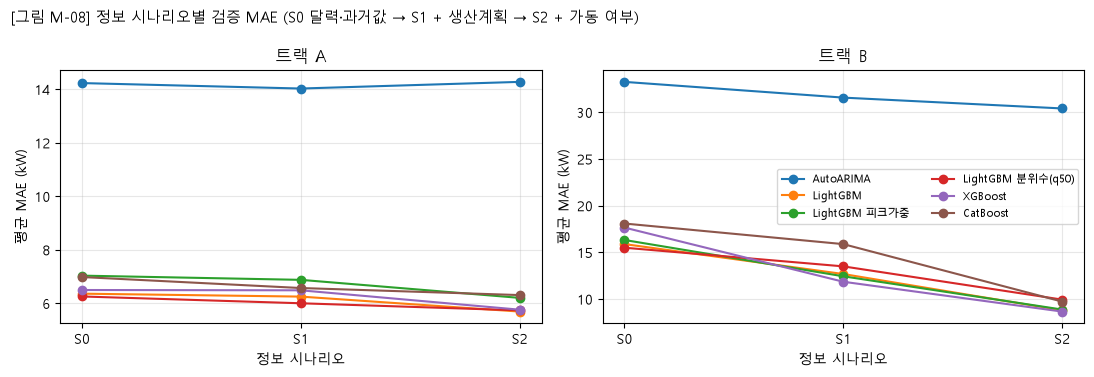

[표 M-15] 시나리오별 평균 MAE와 개선율


,트랙,모델,S0,S1,S2,S0→S1 개선(%),S1→S2 개선(%)
0,A,AutoARIMA,14.233,14.030,14.278,1.4,-1.8
1,A,LightGBM,6.363,6.253,5.694,1.7,8.9
2,A,LightGBM 피크가중,7.036,6.879,6.206,2.2,9.8
3,A,LightGBM 분위수(q50),6.258,6.004,5.739,4.1,4.4
4,A,XGBoost,6.499,6.488,5.764,0.2,11.2
5,A,CatBoost,6.984,6.574,6.310,5.9,4.0
6,B,AutoARIMA,33.260,31.575,30.415,5.1,3.7
7,B,LightGBM,15.889,12.684,8.794,20.2,30.7
8,B,LightGBM 피크가중,16.330,12.441,8.880,23.8,28.6
9,B,LightGBM 분위수(q50),15.502,13.504,9.945,12.9,26.4


In [30]:
# [코드 M-29] S0 → S1 → S2 개선폭 그림 [그림 M-08]
multi = ['arima', 'lgbm', 'lgbm_peakw', 'lgbm_q', 'xgb', 'cat']
m = s[s['model'].isin(multi)].groupby(['track', 'model', 'scenario'])['mae'].mean()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
rows = []
for ax, tr in zip(axes, ['A', 'B']):
    for model in multi:
        v = m[tr][model].reindex(['S0', 'S1', 'S2'])
        ax.plot(v.index, v.to_numpy(), marker='o', label=names[model])
        rows.append({'트랙': tr, '모델': names[model], **v.round(3).to_dict(),
                     'S0→S1 개선(%)': round((1 - v['S1'] / v['S0']) * 100, 1),
                     'S1→S2 개선(%)': round((1 - v['S2'] / v['S1']) * 100, 1)})
    ax.set(title=f'트랙 {tr}', xlabel='정보 시나리오', ylabel='평균 MAE (kW)')
    ax.grid(alpha=0.3)
axes[1].legend(fontsize=8, ncol=2)
fig.suptitle('[그림 M-08] 정보 시나리오별 검증 MAE (S0 달력·과거값 → S1 + 생산계획 → S2 + 가동 여부)',
             x=0.01, ha='left', fontsize=11)
fig.tight_layout()
pu.save_fig(fig, 'M08_scenario_gain'); plt.show()
tbl_gain = pd.DataFrame(rows)
pu.save_table(tbl_gain, 'M15_scenario_gain')
print('[표 M-15] 시나리오별 평균 MAE와 개선율'); display(tbl_gain)

평균만 보면 휴가·정전이 들어간 fold의 영향이 가려지므로, 대표 시나리오 S1의 LightGBM을 fold별로 기준선·가이드북 모델과 비교합니다. 특정 fold(예: 휴가 직후)에서 모든 모델의 오차가 함께 커지면 그 구간이 본래 어려운 것이고, LightGBM만 크게 나빠지면 그 모델의 약점입니다.

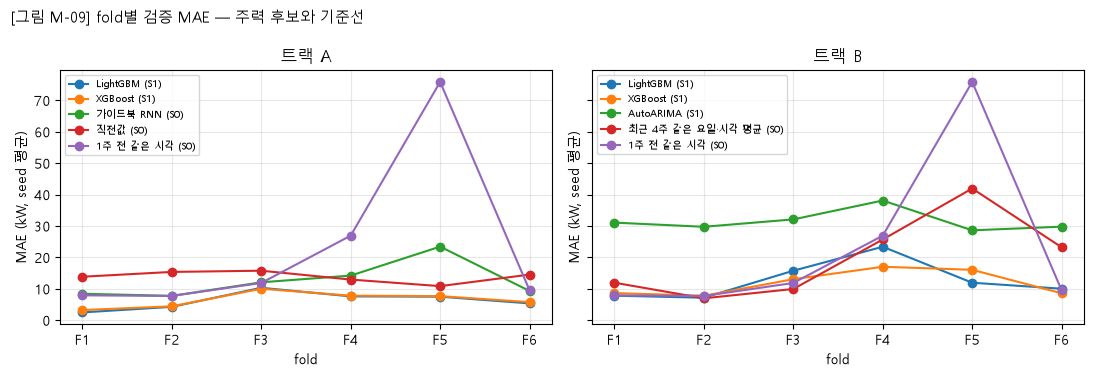

In [31]:
# [코드 M-30] fold별 MAE: LightGBM(S1) vs 기준선·가이드북 [그림 M-09]
show = {'A': [('lgbm', 'S1'), ('xgb', 'S1'), ('guidebook_rnn', 'S0'), ('naive_last', 'S0'), ('naive_week', 'S0')],
        'B': [('lgbm', 'S1'), ('xgb', 'S1'), ('arima', 'S1'), ('naive_4wk', 'S0'), ('naive_week', 'S0')]}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, tr in zip(axes, ['A', 'B']):
    for model, sc in show[tr]:
        v = s[(s['track'] == tr) & (s['model'] == model) & (s['scenario'] == sc)].groupby('fold')['mae'].mean()
        ax.plot(v.index, v.to_numpy(), marker='o', label=f'{names[model]} ({sc})')
    ax.set(title=f'트랙 {tr}', xlabel='fold', ylabel='MAE (kW, seed 평균)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
fig.suptitle('[그림 M-09] fold별 검증 MAE — 주력 후보와 기준선', x=0.01, ha='left', fontsize=11)
fig.tight_layout()
pu.save_fig(fig, 'M09_fold_mae_step3'); plt.show()

점예측 외에 불확실성을 내는 모델(LightGBM 분위수, MSTL·AutoARIMA의 80% 예측구간)의 확률 지표를 봅니다. pinball(분위수 손실)은 작을수록 좋고, 80% 구간 커버리지는 0.80에 가까울수록 구간이 정직하다는 뜻이며, 같은 커버리지라면 폭이 좁을수록 좋습니다. 커버리지 보정(컨포멀 등)은 STEP 6에서 다룹니다.

In [32]:
# [코드 M-31] 분위수·예측구간 지표 [표 M-16]
prob = s[s['model'].isin(['lgbm_q', 'mstl', 'arima'])]
g = prob.groupby(['track', 'scenario', 'model'])
tbl_m16 = g[['pinball', 'cov80', 'width80', 'mae']].mean().round(3)
tbl_m16['fold × seed 수'] = g.size()
tbl_m16 = tbl_m16.reset_index()
tbl_m16['model'] = tbl_m16['model'].map(names)
pu.save_table(tbl_m16, 'M16_probabilistic_step3')
print('[표 M-16] 확률 예측 지표 (pinball: LightGBM은 q10·q50·q90 평균, 통계 모델은 q10·q90 평균 — 서로 직접 비교하지 않음)')
display(tbl_m16)

[표 M-16] 확률 예측 지표 (pinball: LightGBM은 q10·q50·q90 평균, 통계 모델은 q10·q90 평균 — 서로 직접 비교하지 않음)


,track,scenario,model,pinball,cov80,width80,mae,fold × seed 수
0,A,S0,AutoARIMA,4.017,0.862,57.082,14.233,6
1,A,S0,LightGBM 분위수(q50),2.312,0.626,21.236,6.258,30
2,A,S0,MSTL+ETS,2.356,0.863,31.921,8.597,6
3,A,S1,AutoARIMA,4.072,0.865,57.312,14.030,6
4,A,S1,LightGBM 분위수(q50),2.258,0.593,19.448,6.004,30
5,A,S2,AutoARIMA,4.040,0.854,56.501,14.278,6
6,A,S2,LightGBM 분위수(q50),2.155,0.572,16.969,5.739,30
7,B,S0,AutoARIMA,6.923,0.832,107.199,33.260,6
8,B,S0,LightGBM 분위수(q50),6.230,0.452,24.859,15.502,30
9,B,S0,MSTL+ETS,5.452,0.929,85.896,16.570,6


LightGBM이 어떤 피처를 많이 썼는지 gain 중요도(그 피처로 나눌 때 줄어든 오차의 합)로 봅니다. fold × seed 모델의 비율을 평균했고, 대표 시나리오 S1을 트랙별로 그립니다. 중요도는 '예측에 많이 쓰였다'는 뜻이지 원인이라는 뜻은 아니며, 영향 방향은 STEP 7의 SHAP으로 확인합니다.

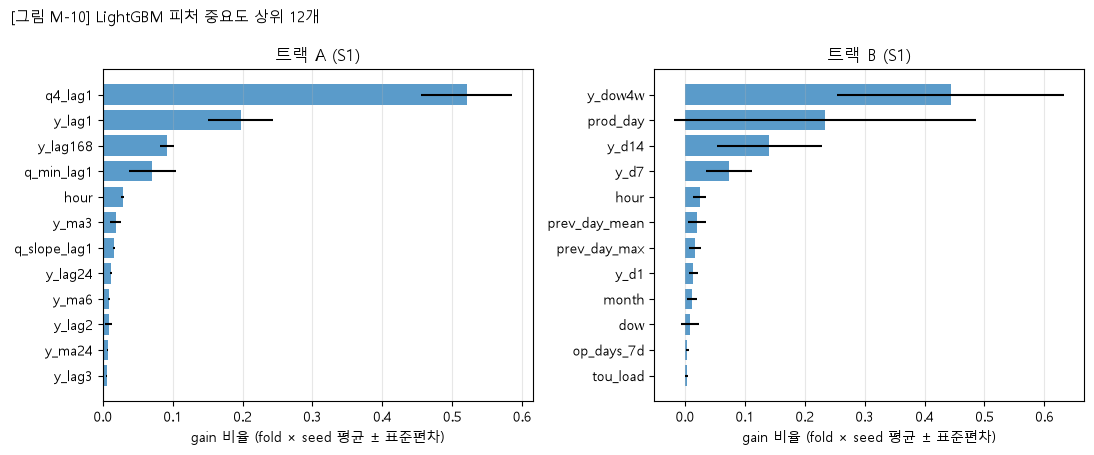

전체 표: outputs/tables/feature_importance_gain.csv (모델·트랙·시나리오·피처별 평균·표준편차)


In [33]:
# [코드 M-32] LightGBM 피처 중요도(gain, S1) [그림 M-10]
imp = pd.read_csv(pu.OUT / 'tables' / 'feature_importance_gain.csv', encoding='utf-8-sig')
imp = imp[(imp['model'] == 'lgbm') & (imp['scenario'] == 'S1')]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, tr in zip(axes, ['A', 'B']):
    d = imp[imp['track'] == tr].nlargest(12, 'mean').iloc[::-1]
    ax.barh(d['feature'], d['mean'], xerr=d['std'], color='#3182bd', alpha=0.8)
    ax.set(title=f'트랙 {tr} (S1)', xlabel='gain 비율 (fold × seed 평균 ± 표준편차)')
    ax.grid(axis='x', alpha=0.3)
fig.suptitle('[그림 M-10] LightGBM 피처 중요도 상위 12개', x=0.01, ha='left', fontsize=11)
fig.tight_layout()
pu.save_fig(fig, 'M10_lgbm_importance_S1'); plt.show()
print('전체 표: outputs/tables/feature_importance_gain.csv (모델·트랙·시나리오·피처별 평균·표준편차)')

피크 가중 L2가 피크 시간 예측을 실제로 개선했는지 L2와 나란히 봅니다. 피크에 가중치를 주면 피크시간 MAE와 피크 경보 재현율은 좋아질 수 있지만, 그만큼 평상시 오차가 늘어 전체 MAE는 나빠질 수 있습니다. 두 지표의 변화 방향을 함께 보고 STEP 6의 피크 위험 분류에서 어느 쪽을 쓸지 정합니다.

In [34]:
# [코드 M-33] 피크 가중 효과: LightGBM L2 vs 피크 가중 L2 [표 M-17]
pw = s[s['model'].isin(['lgbm', 'lgbm_peakw'])]
tbl_m17 = pw.pivot_table(index=['track', 'scenario'], columns='model',
                         values=['mae', 'peak_mae', 'recall', 'f1'], aggfunc='mean').round(3)
tbl_m17.columns = [f'{a}_{names[b]}' for a, b in tbl_m17.columns]
alpha = bp[bp['model'] == 'lgbm'].set_index(['track', 'scenario'])['peak_alpha']
tbl_m17['선택된 α'] = alpha
tbl_m17 = tbl_m17.reset_index()
pu.save_table(tbl_m17, 'M17_peak_weight_effect')
print('[표 M-17] 피크 가중 효과 (fold × seed 평균)')
display(tbl_m17)

[표 M-17] 피크 가중 효과 (fold × seed 평균)


,track,scenario,f1_LightGBM,f1_LightGBM 피크가중,mae_LightGBM,mae_LightGBM 피크가중,peak_mae_LightGBM,peak_mae_LightGBM 피크가중,recall_LightGBM,recall_LightGBM 피크가중,선택된 α
0,A,S0,0.628,0.645,6.363,7.036,9.926,9.020,0.527,0.558,4.0
1,A,S1,0.629,0.646,6.253,6.879,10.068,9.237,0.523,0.549,4.0
2,A,S2,0.639,0.637,5.694,6.206,9.764,9.172,0.529,0.540,4.0
3,B,S0,0.294,0.325,15.889,16.330,22.247,22.578,0.219,0.253,1.0
4,B,S1,0.365,0.397,12.684,12.441,19.089,17.316,0.272,0.296,2.0
5,B,S2,0.396,0.438,8.794,8.880,14.419,13.009,0.279,0.343,2.0


STEP 3의 완료 조건 세 가지를 코드로 확인합니다. 모두 '통과'가 나와야 다음 단계(STEP 4: 딥러닝)로 넘어갑니다.

In [35]:
# [코드 M-34] STEP 3 완료 조건 점검
need = [(m, t, sc) for m in ['lgbm', 'lgbm_peakw', 'lgbm_q', 'xgb', 'cat', 'arima'] for t in ['A', 'B'] for sc in ['S0', 'S1', 'S2']]
have = set(map(tuple, tbl_m14[['model', 'track', 'scenario']].to_numpy()))
checks = {
    '트랙 × 시나리오 × 모델별 mean ± std 표': all(k in have for k in need) and ('mstl', 'A', 'S0') in have,
    'S0 → S1 → S2 개선폭 그림': (pu.OUT / 'figures' / 'M08_scenario_gain.png').exists(),
    '1주 나이브 대비 MASE < 1 여부 표시': tbl_m14['MASE<1'].isin(['예', '아니오']).all(),
}
for name, ok in checks.items():
    print(f"{'통과' if ok else '실패'} | {name}")
assert all(checks.values())
best = tbl_m14.loc[tbl_m14.groupby('track')['mae 중앙값'].idxmin(), ['track', 'scenario', '모델', 'mae 중앙값', 'MASE<1']]
print('트랙별 MAE 중앙값 1위:'); display(best.reset_index(drop=True))

통과 | 트랙 × 시나리오 × 모델별 mean ± std 표
통과 | S0 → S1 → S2 개선폭 그림
통과 | 1주 나이브 대비 MASE < 1 여부 표시
트랙별 MAE 중앙값 1위:


,track,scenario,모델,mae 중앙값,MASE<1
0,A,S2,LightGBM 분위수(q50),5.888,예
1,B,S2,LightGBM,8.242,예


## [단계 ⑦] 딥러닝 시계열 모델 (NHITS·TFT·LSTM)

neuralforecast 라이브러리의 딥러닝 시계열 모델 세 가지를 같은 fold·같은 지표로 비교합니다.

- **NHITS**: 여러 시간 해상도로 나눠 패턴을 쌓는 MLP 모델(빠름)
- **TFT**(Temporal Fusion Transformer): 어텐션으로 중요한 과거 시점과 변수를 고르는 트랜스포머 모델(무거움)
- **LSTM**: 가이드북 RNN의 개선판. 미래에도 아는 값(달력·TOU·생산계획 등)과 과거 파생값을 입력에 더하고, 정규화를 학습 구간에서만 맞춰 스케일 누수를 없앴습니다.

> **미리 밝혀 둘 점**: 이 데이터는 **8개월짜리 단일 시계열**(공장 1곳, 약 5,800시간)입니다. 딥러닝은 많은 시계열이나 긴 기간에서 강점을 보이는 경우가 많아, 이렇게 짧은 단일 시계열에서는 트리 모델보다 불리할 수 있습니다. 아래 결과로 실제로 그런지 확인합니다.

학습 조건: 입력 길이 168시간(NHITS는 336시간도 비교), 트랙 A는 1시간 앞(h=1), 트랙 B는 24시간 앞(h=24). 학습 구간 마지막 2주를 검증으로 떼어 50 step마다 검증 손실을 재고, 5번 연속 나아지지 않으면 멈춥니다(early stopping). neuralforecast의 창 단위 정규화는 공휴일처럼 드문 0/1 피처를 지나치게 키우는 문제가 있어 끄고, y와 연속형 입력을 fold 학습 구간의 평균·표준편차로 직접 표준화했습니다. CPU만 있어 계산량을 나눴습니다: NHITS는 S0·S1·S2 × 6 fold × seed 3개, LSTM과 NHITS(입력 336)는 S1 × 6 fold × seed 3개, TFT는 S1 × 최근 3 fold(F4~F6) × seed 3개입니다. 학습은 `scripts/train_neural.py`로 따로 돌렸습니다(학습 단위별 로그: `outputs/logs/neural/`).

모델·트랙·시나리오별로 검증 MAE와 학습 기록을 정리합니다. 'seed 간 표준편차'는 seed마다 fold 평균 MAE를 구한 뒤 그 값들이 seed에 따라 얼마나 흔들리는지(초기값 운에 얼마나 좌우되는지)를 보여 줍니다. best step은 검증 손실이 가장 낮았던 학습 단계이고, 멈춘 step이 상한(max_steps)과 같으면 더 학습할 여지가 있었다는 뜻입니다.

In [36]:
# [코드 M-35] 딥러닝 모델별 seed 평균 ± 표준편차, best step 표 [표 M-18]
runs = pd.read_csv(pu.OUT / 'tables' / 'neural_runs.csv', encoding='utf-8-sig')
cv = pd.read_csv(pu.CV_PATH, encoding='utf-8-sig')
nn_names = {'nhits': 'NHITS', 'nhits_L336': 'NHITS(입력 336)', 'lstm': 'LSTM', 'tft': 'TFT'}
s = cv[(cv['subset'] == 'all') & cv['model'].isin(list(nn_names))]
key = ['model', 'track', 'scenario']
seed_mae = s.groupby(key + ['seed'])['mae'].mean().groupby(key)
tbl_m18 = pu.summarize_scores(s, metrics=('mae', 'mase', 'peak_mae', 'f1'))
tbl_m18 = tbl_m18.merge(seed_mae.std().round(3).rename('seed 간 표준편차(MAE)').reset_index())
g = runs.groupby(key)
stat = pd.DataFrame({'best step 중앙값': g['best_step'].median(),
                     'best step 범위': g['best_step'].min().astype(int).astype(str) + '~' + g['best_step'].max().astype(int).astype(str),
                     '멈춘 step 중앙값': g['stopped_step'].median(), 'max_steps': g['max_steps'].first(),
                     '상한 도달 횟수': g.apply(lambda d: int((d['stopped_step'] >= d['max_steps']).sum()), include_groups=False),
                     '학습 시간 평균(초)': g['fit_sec'].mean().round(0)}).reset_index()
tbl_m18 = tbl_m18.merge(stat, on=key)
tbl_m18['모델'] = tbl_m18['model'].map(nn_names)
cols = ['track', 'scenario', '모델', 'mae 평균±표준편차', 'mae 중앙값', 'seed 간 표준편차(MAE)', 'mase 평균±표준편차',
        'peak_mae 평균±표준편차', 'f1 평균±표준편차', 'fold 수', 'best step 중앙값', 'best step 범위',
        '멈춘 step 중앙값', 'max_steps', '상한 도달 횟수', '학습 시간 평균(초)']
tbl_m18 = tbl_m18.sort_values(['track', 'scenario', 'mae 중앙값'])[cols].reset_index(drop=True)
pu.save_table(tbl_m18, 'M18_neural_summary')
print('[표 M-18] 딥러닝 모델 검증 성능과 학습 기록 (TFT는 F4~F6 3 fold)')
display(tbl_m18)

[표 M-18] 딥러닝 모델 검증 성능과 학습 기록 (TFT는 F4~F6 3 fold)

,track,scenario,모델,mae 평균±표준편차,mae 중앙값,seed 간 표준편차(MAE),mase 평균±표준편차,peak_mae 평균±표준편차,f1 평균±표준편차,fold 수,best step 중앙값,best step 범위,멈춘 step 중앙값,max_steps,상한 도달 횟수,학습 시간 평균(초)
0,A,S0,NHITS,8.778 ± 3.031,7.937,0.132,0.437 ± 0.17,11.781 ± 4.291,0.585 ± 0.12,6,225.0,100~1000,475.0,1000,3,497.0
1,A,S1,TFT,5.91 ± 0.813,5.792,0.162,0.294 ± 0.063,10.842 ± 4.471,0.555 ± 0.254,3,450.0,400~500,500.0,500,9,3990.0
2,A,S1,LSTM,6.481 ± 1.416,6.118,0.104,0.32 ± 0.083,11.417 ± 2.535,0.519 ± 0.189,6,900.0,700~1000,1000.0,1000,17,1076.0
3,A,S1,NHITS(입력 336),8.766 ± 2.975,7.867,0.109,0.435 ± 0.167,12.344 ± 5.448,0.602 ± 0.186,6,225.0,100~1000,475.0,1000,2,959.0
4,A,S1,NHITS,9.192 ± 3.948,7.906,0.304,0.458 ± 0.216,11.843 ± 3.925,0.596 ± 0.111,6,225.0,100~850,475.0,1000,1,467.0
5,A,S2,NHITS,9.03 ± 3.927,7.556,0.277,0.449 ± 0.214,13.57 ± 7.529,0.544 ± 0.178,6,200.0,100~850,450.0,1000,2,564.0
6,B,S0,NHITS,19.556 ± 14.317,12.934,0.440,0.988 ± 0.757,23.553 ± 15.739,0.293 ± 0.191,6,350.0,100~900,600.0,1000,4,646.0
7,B,S1,TFT,10.068 ± 2.711,10.830,0.711,0.505 ± 0.169,18.736 ± 7.562,0.202 ± 0.114,3,350.0,150~500,500.0,500,5,4043.0
8,B,S1,NHITS(입력 336),19.424 ± 11.431,15.320,0.402,0.976 ± 0.613,23.046 ± 9.84,0.318 ± 0.145,6,425.0,100~900,675.0,1000,1,885.0
9,B,S1,LSTM,19.737 ± 12.809,15.846,1.791,0.989 ± 0.677,19.908 ± 7.254,0.326 ± 0.185,6,450.0,50~1000,700.0,1000,4,675.0


대표 fold(F6, 테스트 직전 2주)에서 세 모델의 학습 곡선을 그립니다. 학습 손실(옅은 선)과 검증 손실(진한 선)은 표준화된 단위의 MAE이고, 점선은 best step입니다. 검증 손실이 학습 손실보다 훨씬 빨리 바닥을 치고 다시 오르면, 데이터가 적어 모델이 학습 구간을 외우기 시작했다는 신호입니다.

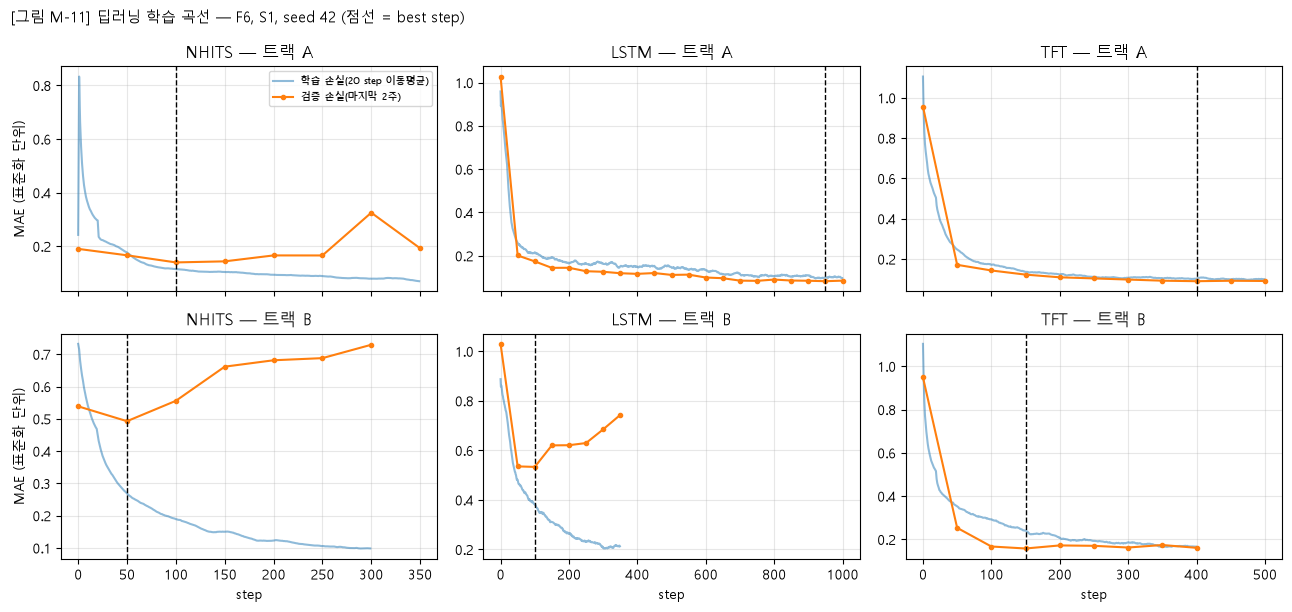

In [37]:
# [코드 M-36] 대표 fold(F6) 학습 곡선, S1·seed 42 [그림 M-11]
traj = pd.read_csv(pu.OUT / 'logs' / 'neural_trajectories.csv', encoding='utf-8-sig')
traj = traj[(traj['fold'] == 'F6') & (traj['seed'] == pu.SEEDS[0]) & (traj['scenario'] == 'S1')]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.2), sharex='col')
for i, tr in enumerate(['A', 'B']):
    for j, model in enumerate(['nhits', 'lstm', 'tft']):
        ax, d = axes[i, j], traj[(traj['track'] == tr) & (traj['model'] == model)]
        t, v = d[d['kind'] == 'train'], d[d['kind'] == 'valid']
        ax.plot(t['step'], t['loss'].rolling(20, min_periods=1).mean(), alpha=0.5, label='학습 손실(20 step 이동평균)')
        ax.plot(v['step'], v['loss'], marker='o', ms=3, label='검증 손실(마지막 2주)')
        if len(v):
            ax.axvline(v.loc[v['loss'].idxmin(), 'step'], color='k', ls='--', lw=1)
        ax.set(title=f'{nn_names[model]} — 트랙 {tr}', xlabel='step' if i else None)
        ax.set_ylabel('MAE (표준화 단위)' if j == 0 else None)
        ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=7)
fig.suptitle('[그림 M-11] 딥러닝 학습 곡선 — F6, S1, seed 42 (점선 = best step)', x=0.01, ha='left', fontsize=11)
fig.tight_layout()
pu.save_fig(fig, 'M11_neural_learning_curves'); plt.show()

딥러닝 모델을 STEP 3의 주력 후보·기준선과 나란히 놓습니다. TFT는 F4~F6만 돌렸으므로 공정하게 비교하려고 모든 모델을 같은 3개 fold로 다시 평균한 열(F4~F6 평균 MAE)도 함께 둡니다. 같은 트랙·시나리오에서 딥러닝이 LightGBM보다 좋은지, 그리고 최소한 기준선보다는 좋은지를 봅니다.

In [38]:
# [코드 M-37] 딥러닝 vs 트리·통계·기준선 비교 (S1·S0) [표 M-19]
comp = {**nn_names, 'lgbm': 'LightGBM', 'xgb': 'XGBoost', 'mstl': 'MSTL+ETS', 'guidebook_rnn': '가이드북 RNN',
        'guidebook_rf': '가이드북 RF', 'naive_last': '직전값', 'naive_4wk': '최근 4주 평균'}
a = cv[(cv['subset'] == 'all') & cv['model'].isin(list(comp))]
a = a[(a['scenario'] == 'S1') | a['model'].isin(['mstl', 'guidebook_rnn', 'guidebook_rf', 'naive_last', 'naive_4wk'])
      | ((a['scenario'] == 'S0') & a['model'].isin(['nhits', 'lgbm']))]
g = a.groupby(['track', 'model', 'scenario'])
tbl_m19 = pd.DataFrame({'MAE 평균': g['mae'].mean(), 'MAE 중앙값': g['mae'].median(), 'MASE 평균': g['mase'].mean(),
                        '피크시간 MAE': g['peak_mae'].mean(), 'F1': g['f1'].mean(), 'fold 수': g['fold'].nunique(),
                        'F4~F6 평균 MAE': a[a['fold'].isin(['F4', 'F5', 'F6'])].groupby(['track', 'model', 'scenario'])['mae'].mean()}).round(3)
tbl_m19 = tbl_m19.reset_index()
tbl_m19.insert(1, '모델', tbl_m19.pop('model').map(comp))
tbl_m19 = tbl_m19.sort_values(['track', 'F4~F6 평균 MAE'], ignore_index=True)
pu.save_table(tbl_m19, 'M19_neural_vs_others')
for tr in ['A', 'B']:
    print(f'[표 M-19] 트랙 {tr} — 딥러닝 vs 다른 모델 (F4~F6 평균 MAE 순)')
    display(tbl_m19[tbl_m19['track'] == tr].drop(columns='track').reset_index(drop=True))

[표 M-19] 트랙 A — 딥러닝 vs 다른 모델 (F4~F6 평균 MAE 순)


,모델,scenario,MAE 평균,MAE 중앙값,MASE 평균,피크시간 MAE,F1,fold 수,F4~F6 평균 MAE
0,LSTM,S1,6.481,6.118,0.320,11.417,0.519,6,5.689
1,TFT,S1,5.910,5.792,0.294,10.842,0.555,3,5.910
2,LightGBM,S1,6.253,6.400,0.312,10.068,0.629,6,6.819
3,XGBoost,S1,6.488,6.759,0.323,10.465,0.648,6,7.082
4,LightGBM,S0,6.363,6.711,0.318,9.926,0.628,6,7.165
5,가이드북 RF,S0,7.683,6.410,0.381,10.656,0.667,6,8.104
6,MSTL+ETS,S0,8.597,8.480,0.427,10.600,0.623,6,9.148
7,NHITS,S0,8.778,7.937,0.437,11.781,0.585,6,9.799
8,NHITS(입력 336),S1,8.766,7.867,0.435,12.344,0.602,6,9.902
9,NHITS,S1,9.192,7.906,0.458,11.843,0.596,6,10.630


[표 M-19] 트랙 B — 딥러닝 vs 다른 모델 (F4~F6 평균 MAE 순)


,모델,scenario,MAE 평균,MAE 중앙값,MASE 평균,피크시간 MAE,F1,fold 수,F4~F6 평균 MAE
0,TFT,S1,10.068,10.830,0.505,18.736,0.202,3,10.068
1,XGBoost,S1,11.857,10.917,0.591,16.678,0.330,6,13.881
2,LightGBM,S1,12.684,10.000,0.634,19.089,0.365,6,15.122
3,MSTL+ETS,S0,16.570,16.922,0.828,20.959,0.379,6,18.527
4,LightGBM,S0,15.889,12.153,0.800,22.247,0.294,6,21.558
5,LSTM,S1,19.737,15.846,0.989,19.908,0.326,6,25.241
6,NHITS(입력 336),S1,19.424,15.320,0.976,23.046,0.318,6,25.333
7,NHITS,S0,19.556,12.934,0.988,23.553,0.293,6,27.403
8,NHITS,S1,21.113,16.016,1.065,20.985,0.349,6,28.728
9,최근 4주 평균,S0,19.958,17.584,0.988,25.891,0.225,6,30.291


NHITS로 두 가지를 더 봅니다. (1) 입력 길이를 1주(168시간)에서 2주(336시간)로 늘리면 나아지는지, (2) 정보 시나리오 S0 → S1 → S2에 따른 개선폭이 STEP 3의 LightGBM과 비슷한지입니다. 딥러닝도 생산계획·가동 여부 정보로 비슷하게 좋아진다면, 정보의 가치가 모델 종류와 상관없이 일관된다는 근거가 됩니다.

In [39]:
# [코드 M-38] NHITS 입력 길이·시나리오 비교 (LightGBM 참고) [표 M-20]
rows = []
for tr in ['A', 'B']:
    m = cv[(cv['subset'] == 'all') & (cv['track'] == tr)].groupby(['model', 'scenario'])['mae'].mean()
    rows.append({'트랙': tr, '비교': '입력 길이(S1)', 'NHITS 168': m[('nhits', 'S1')], 'NHITS 336': m[('nhits_L336', 'S1')]})
    for model, label in [('nhits', 'NHITS'), ('lgbm', 'LightGBM')]:
        v = m[model].reindex(['S0', 'S1', 'S2'])
        rows.append({'트랙': tr, '비교': f'시나리오 — {label}', **v.to_dict(),
                     'S0→S1 개선(%)': (1 - v['S1'] / v['S0']) * 100, 'S1→S2 개선(%)': (1 - v['S2'] / v['S1']) * 100})
tbl_m20 = pd.DataFrame(rows).round(2)
pu.save_table(tbl_m20, 'M20_nhits_variants')
print('[표 M-20] NHITS 입력 길이와 정보 시나리오 효과 (평균 MAE, kW)')
display(tbl_m20)

[표 M-20] NHITS 입력 길이와 정보 시나리오 효과 (평균 MAE, kW)


,트랙,비교,NHITS 168,NHITS 336,S0,S1,S2,S0→S1 개선(%),S1→S2 개선(%)
0,A,입력 길이(S1),9.19,8.77,NaN,NaN,NaN,NaN,NaN
1,A,시나리오 — NHITS,NaN,NaN,8.78,9.19,9.03,-4.72,1.76
2,A,시나리오 — LightGBM,NaN,NaN,6.36,6.25,5.69,1.72,8.95
3,B,입력 길이(S1),21.11,19.42,NaN,NaN,NaN,NaN,NaN
4,B,시나리오 — NHITS,NaN,NaN,19.56,21.11,15.49,-7.96,26.61
5,B,시나리오 — LightGBM,NaN,NaN,15.89,12.68,8.79,20.17,30.67


처음에 밝힌 '8개월 단일 시계열이라 딥러닝이 불리할 수 있다'는 예상을 결과로 확인합니다. 트랙마다 가장 좋은 딥러닝 모델과 가장 좋은 트리 모델을 같은 시나리오(S1)·같은 fold(F4~F6)로 비교해 출력합니다. 마지막으로 STEP 4 완료 조건 두 가지를 점검합니다.

In [40]:
# [코드 M-39] '딥러닝 불리' 예상 확인과 STEP 4 완료 조건 점검
f46 = cv[(cv['subset'] == 'all') & (cv['scenario'] == 'S1') & cv['fold'].isin(['F4', 'F5', 'F6'])]
m46 = f46.groupby(['track', 'model'])['mae'].mean()
for tr in ['A', 'B']:
    nn = m46[tr][[k for k in nn_names if k in m46[tr]]]
    tree = m46[tr][[k for k in ['lgbm', 'lgbm_q', 'xgb', 'cat'] if k in m46[tr]]]
    verdict = '트리 모델이 더 좋음(예상과 일치)' if tree.min() < nn.min() else '딥러닝이 더 좋음(예상과 다름)'
    print(f'트랙 {tr} (S1, F4~F6): 최고 딥러닝 {nn_names[nn.idxmin()]} {nn.min():.2f} kW vs 최고 트리 {tree.idxmin()} '
          f'{tree.min():.2f} kW → {verdict}')
checks = {
    '모델별 seed 평균 ± std, best step 표': {'nhits', 'lstm', 'tft'} <= set(tbl_m18['모델'].map({v: k for k, v in nn_names.items()}))
                                       and tbl_m18['best step 중앙값'].notna().all(),
    '대표 fold 학습 곡선 그림': (pu.OUT / 'figures' / 'M11_neural_learning_curves.png').exists(),
}
for name, ok in checks.items():
    print(f"{'통과' if ok else '실패'} | {name}")
assert all(checks.values())

트랙 A (S1, F4~F6): 최고 딥러닝 LSTM 5.69 kW vs 최고 트리 lgbm_q 6.57 kW → 딥러닝이 더 좋음(예상과 다름)
트랙 B (S1, F4~F6): 최고 딥러닝 TFT 10.07 kW vs 최고 트리 xgb 13.88 kW → 딥러닝이 더 좋음(예상과 다름)
통과 | 모델별 seed 평균 ± std, best step 표
통과 | 대표 fold 학습 곡선 그림


## [단계 ⑧] 시계열 파운데이션 모델: zero-shot → 공변량 → 미세조정

**파운데이션 모델**(foundation model)은 아주 많은 시계열로 미리 학습해 둔 큰 모델로, 이 공장 데이터로 따로 학습하지 않아도(zero-shot) 바로 예측할 수 있습니다. Amazon의 **Chronos-2**를 세 단계로 비교합니다.

1. **zero-shot(단변량)**: 과거 전력값만 넣어 예측. 입력할 과거 길이(문맥 길이)를 336·672·1344·2688시간·전체로 바꿔 가며 가장 좋은 길이를 고릅니다.
2. **공변량 zero-shot**: 미래에도 아는 값(시각·비가동일·과금 시간·TOU, S1 생산계획, S2 가동 여부)과 과거 사용량을 함께 넣습니다.
3. **LoRA 미세조정**: 작은 모델(chronos-2-small)의 일부 가중치만 이 공장 데이터로 조금 더 학습합니다(LoRA: 원래 가중치는 두고 작은 보정 행렬만 학습하는 방법).

zero-shot 추론은 같은 입력이면 항상 같은 결과가 나오므로(결정적) seed를 반복하지 않습니다. 0값 구간은 결측(NaN)으로 넣어 모델이 무시하게 했고, 계산은 `scripts/run_chronos.py`로 따로 돌렸습니다.

| 모델 | 라이선스 | 이번 실행 |
|---|---|---|
| Chronos-2 (amazon/chronos-2, 1억 2천만 파라미터) | Apache-2.0 | zero-shot·공변량, 6 fold |
| Chronos-2-small (autogluon/chronos-2-small, 2천8백만) | Apache-2.0 | 공변량 zero-shot·LoRA 미세조정(CPU 축소판), 최근 3 fold × seed 3 |
| Chronos-2 full 미세조정 | Apache-2.0 | 미실행 — GPU 필요(CPU에서 1회 수 시간 이상) |
| TiRex-2 | Apache-2.0 | 미실행 — Linux·macOS 전용(이 PC는 Windows, WSL 없음) |
| TimesFM 3.0 | 가중치 비상업·비운영 | 미실행 — 참고 성능용, 현장 배포 후보 아님 |
| TabPFN-TS | 체크포인트 동의 필요, 기본값 클라우드 API | 미실행 — 참고 성능용, 데이터 외부 전송 위험 |

> **실행 방식 확인**: 이 환경에는 LoRA에 필요한 `peft` 패키지가 설치되어 있지 않습니다(`chronos.chronos2.pipeline.is_peft_available()` = False). 이 경우 chronos-forecasting 2.3.2의 `fit(finetune_mode='lora')`는 경고를 낸 뒤 **전체 미세조정**으로 실행합니다. 따라서 이 노트북의 'LoRA' 결과는 chronos-2-small(2천8백만 파라미터) 전체를 미세조정한 결과입니다(이름은 실행 당시 설정을 그대로 둠).

공식 README와 설치된 패키지에서 확인한 버전과 호출 형태를 기록합니다. 모델 설정(최대 문맥 길이, 한 번에 내는 예측 길이 단위)도 직접 불러와 출력하며, 이 값들은 `outputs/tables/M21_chronos_api.csv`에 저장합니다. 나중에 같은 결과를 재현할 때 이 표의 버전과 호출 형태를 그대로 쓰면 됩니다.

In [41]:
# [코드 M-40] Chronos-2 설치 버전과 호출 형태 기록 [표 M-21]
import os, warnings
# 가중치는 받아 둔 것이 있으면 캐시에서 읽고, 없으면 Hugging Face에서 받음(처음 한 번 인터넷 필요)
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
warnings.filterwarnings('ignore')
from importlib import metadata
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar()
from chronos import Chronos2Pipeline
api = []
for name in ['amazon/chronos-2', 'autogluon/chronos-2-small']:
    p = Chronos2Pipeline.from_pretrained(name, device_map='cpu')
    api.append({'모델': name, '파라미터 수(백만)': round(sum(t.numel() for t in p.model.parameters()) / 1e6, 1),
                '최대 문맥 길이': p.model_context_length, '출력 패치 길이': p.model_output_patch_size})
tbl_m21 = pd.DataFrame(api)
tbl_m21['chronos-forecasting'] = metadata.version('chronos-forecasting')
tbl_m21['transformers'] = metadata.version('transformers')
tbl_m21['호출 형태'] = ("Chronos2Pipeline.from_pretrained(이름, device_map='cpu').predict_quantiles("
                    "[{'target', 'past_covariates', 'future_covariates'}], prediction_length, quantile_levels)")
tbl_m21['미세조정'] = "pipeline.fit(inputs, prediction_length=24, validation_inputs, finetune_mode='lora', learning_rate=1e-5)"
pu.save_table(tbl_m21, 'M21_chronos_api')
print('[표 M-21] Chronos-2 설치 버전·모델 설정·호출 형태')
display(tbl_m21)

[표 M-21] Chronos-2 설치 버전·모델 설정·호출 형태


,모델,파라미터 수(백만),최대 문맥 길이,출력 패치 길이,chronos-forecasting,transformers,호출 형태,미세조정
0,amazon/chronos-2,119.5,8192,16,2.3.2,5.18.0,"Chronos2Pipeline.from_pretrained(이름, device_ma...","pipeline.fit(inputs, prediction_length=24, val..."
1,autogluon/chronos-2-small,27.9,8192,16,2.3.2,5.18.0,"Chronos2Pipeline.from_pretrained(이름, device_ma...","pipeline.fit(inputs, prediction_length=24, val..."


단변량 zero-shot에서 문맥 길이(모델에 넣는 과거 길이)에 따른 검증 MAE를 그립니다. 문맥이 길수록 오래된 패턴(월별로 바뀌는 가동 일정 등)까지 보지만, 지금과 다른 옛 패턴이 섞여 오히려 나빠질 수도 있습니다. 트랙마다 검증 평균 MAE가 가장 작은 길이(★)를 골라 이후 비교에 씁니다.

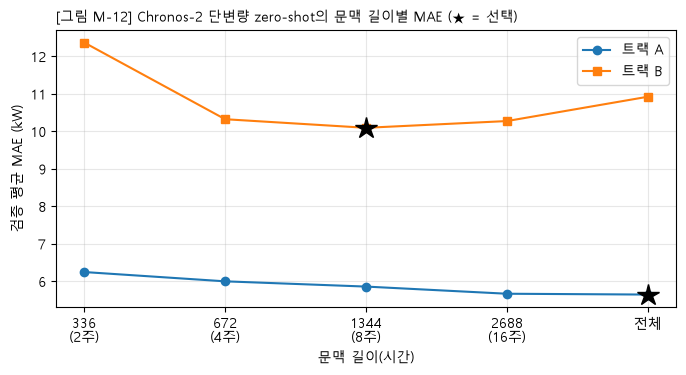

[표 M-22] 문맥 길이별 검증 평균 MAE


track,A,B
ctx,,
336,6.249,12.371
672,6.001,10.326
1344,5.861,10.097
2688,5.670,10.277
full,5.648,10.926


선택된 문맥 길이: {'A': 'full', 'B': '1344'}


In [42]:
# [코드 M-41] 문맥 길이별 MAE (단변량 zero-shot, 6 fold) [그림 M-12]
ch = pd.read_csv(pu.OUT / 'tables' / 'chronos_all_scores.csv', encoding='utf-8-sig')
order = ['336', '672', '1344', '2688', 'full']
zs = ch[(ch['kind'] == 'zs') & (ch['subset'] == 'all')].astype({'ctx': str})
ctx_tbl = zs.pivot_table(index='ctx', columns='track', values='mae', aggfunc='mean').reindex(order).round(3)
best_ctx = ctx_tbl.idxmin().to_dict()
fig, ax = plt.subplots(figsize=(8, 3.6))
for tr, mk in [('A', 'o'), ('B', 's')]:
    ax.plot(range(len(order)), ctx_tbl[tr], marker=mk, label=f'트랙 {tr}')
    k = order.index(best_ctx[tr])
    ax.plot(k, ctx_tbl.loc[best_ctx[tr], tr], marker='*', ms=16, color='k')
ax.set_xticks(range(len(order)), ['336\n(2주)', '672\n(4주)', '1344\n(8주)', '2688\n(16주)', '전체'])
ax.set(xlabel='문맥 길이(시간)', ylabel='검증 평균 MAE (kW)')
ax.grid(alpha=0.3); ax.legend()
ax.set_title('[그림 M-12] Chronos-2 단변량 zero-shot의 문맥 길이별 MAE (★ = 선택)', loc='left', fontsize=10)
pu.save_fig(fig, 'M12_chronos_context'); plt.show()
pu.save_table(ctx_tbl.reset_index(), 'M22_chronos_context')
print('[표 M-22] 문맥 길이별 검증 평균 MAE'); display(ctx_tbl)
print('선택된 문맥 길이:', best_ctx)

이번 STEP의 핵심 비교표입니다. 같은 Chronos-2 계열에서 zero-shot(단변량) → 공변량 → LoRA 미세조정으로 갈 때 MAE가 어떻게 변하는지 트랙 × 시나리오별로 보고, STEP 3의 LightGBM과 나란히 놓습니다. 공변량 실험은 계산량 때문에 문맥 길이를 1344시간으로 고정했으므로, 같은 문맥의 단변량 결과(문맥 1344 행)와 비교하면 공변량만의 효과를 볼 수 있습니다. LoRA는 최근 3 fold만 돌렸으므로 모든 모델의 F4~F6 평균 MAE 열을 함께 둡니다.

In [43]:
# [코드 M-42] zero-shot vs 공변량 vs 미세조정 비교표 (트랙 × 시나리오) [표 M-23]
cv = pd.read_csv(pu.CV_PATH, encoding='utf-8-sig')
fm = {'chronos2_zs': 'Chronos-2 zero-shot(단변량)', 'chronos2_cov': 'Chronos-2 공변량', 'chronos2s_cov': 'Chronos-2-small 공변량',
      'chronos2s_lora': 'Chronos-2-small LoRA', 'lgbm': 'LightGBM(참고)', 'naive_4wk': '최근 4주 평균(참고)', 'naive_last': '직전값(참고)'}
a = cv[(cv['subset'] == 'all') & cv['model'].isin(list(fm))]
g = a.groupby(['track', 'scenario', 'model'])
tbl_m23 = pd.DataFrame({'MAE 평균': g['mae'].mean(), 'MAE 중앙값': g['mae'].median(), 'pinball': g['pinball'].mean(),
                        '80% 커버리지': g['cov80'].mean(), 'F1': g['f1'].mean(), 'fold 수': g['fold'].nunique(),
                        'F4~F6 평균 MAE': a[a['fold'].isin(['F4', 'F5', 'F6'])].groupby(['track', 'scenario', 'model'])['mae'].mean(),
                        '결정적': g['deterministic'].first()}).round(3).reset_index()
tbl_m23.insert(2, '모델', tbl_m23.pop('model').map(fm))
z = ch[(ch['kind'] == 'zs') & (ch['subset'] == 'all') & (ch['ctx'].astype(str) == '1344')]     # 같은 문맥의 단변량
zg = z.groupby('track')
z_rows = pd.DataFrame({'MAE 평균': zg['mae'].mean(), 'MAE 중앙값': zg['mae'].median(), 'pinball': zg['pinball'].mean(),
                       '80% 커버리지': zg['cov80'].mean(), 'F1': zg['f1'].mean(), 'fold 수': zg['fold'].nunique(),
                       'F4~F6 평균 MAE': z[z['fold'].isin(['F4', 'F5', 'F6'])].groupby('track')['mae'].mean()}).round(3)
z_rows = z_rows.reset_index().assign(scenario='S0', 모델='Chronos-2 zero-shot(단변량, 문맥 1344)', 결정적=True)
tbl_m23 = pd.concat([tbl_m23, z_rows], ignore_index=True)
tbl_m23 = tbl_m23.sort_values(['track', 'scenario', 'F4~F6 평균 MAE'], ignore_index=True)
pu.save_table(tbl_m23, 'M23_foundation_comparison')
for tr in ['A', 'B']:
    print(f'[표 M-23] 트랙 {tr} — Chronos-2 zero-shot vs 공변량 vs LoRA (LightGBM·기준선 참고)')
    display(tbl_m23[tbl_m23['track'] == tr].drop(columns='track').reset_index(drop=True))

[표 M-23] 트랙 A — Chronos-2 zero-shot vs 공변량 vs LoRA (LightGBM·기준선 참고)


,scenario,모델,MAE 평균,MAE 중앙값,pinball,80% 커버리지,F1,fold 수,F4~F6 평균 MAE,결정적
0,S0,Chronos-2 zero-shot(단변량),5.648,5.248,2.229,0.709,0.721,6,5.411,True
1,S0,Chronos-2 공변량,5.949,5.565,2.342,0.706,0.689,6,5.447,True
2,S0,"Chronos-2 zero-shot(단변량, 문맥 1344)",5.861,5.505,2.304,0.726,0.679,6,5.460,True
3,S0,LightGBM(참고),6.363,6.711,NaN,NaN,0.628,6,7.165,False
4,S0,직전값(참고),13.887,14.189,NaN,NaN,0.548,6,12.777,True
5,S0,최근 4주 평균(참고),19.958,17.584,NaN,NaN,0.225,6,30.291,True
6,S1,Chronos-2 공변량,5.942,5.521,2.326,0.723,0.677,6,5.432,True
7,S1,Chronos-2-small 공변량,5.863,5.757,2.313,0.746,0.656,3,5.863,True
8,S1,Chronos-2-small LoRA,6.707,6.028,2.671,0.707,0.626,3,6.707,False
9,S1,LightGBM(참고),6.253,6.400,NaN,NaN,0.629,6,6.819,False


[표 M-23] 트랙 B — Chronos-2 zero-shot vs 공변량 vs LoRA (LightGBM·기준선 참고)


,scenario,모델,MAE 평균,MAE 중앙값,pinball,80% 커버리지,F1,fold 수,F4~F6 평균 MAE,결정적
0,S0,Chronos-2 공변량,10.067,8.933,4.143,0.703,0.509,6,12.259,True
1,S0,Chronos-2 zero-shot(단변량),10.097,8.840,4.072,0.718,0.549,6,12.556,True
2,S0,"Chronos-2 zero-shot(단변량, 문맥 1344)",10.097,8.840,4.072,0.718,0.549,6,12.556,True
3,S0,LightGBM(참고),15.889,12.153,NaN,NaN,0.294,6,21.558,False
4,S0,최근 4주 평균(참고),19.958,17.584,NaN,NaN,0.225,6,30.291,True
5,S0,직전값(참고),40.787,41.016,NaN,NaN,0.030,6,38.652,True
6,S1,Chronos-2-small 공변량,9.237,7.180,3.824,0.749,0.578,3,9.237,True
7,S1,Chronos-2 공변량,8.686,7.122,3.422,0.722,0.517,6,9.493,True
8,S1,Chronos-2-small LoRA,9.695,7.140,3.955,0.721,0.528,3,9.695,False
9,S1,LightGBM(참고),12.684,10.000,NaN,NaN,0.365,6,15.122,False


LoRA 미세조정의 학습 기록입니다. 250 step마다 학습 구간 마지막 2주로 검증 손실을 쟀고, 가장 낮았던 step의 체크포인트를 썼습니다. 검증 손실이 처음(0~250 step)부터 거의 줄지 않으면, 이미 zero-shot이 충분히 잘 맞아 미세조정으로 얻을 것이 적다는 뜻입니다.

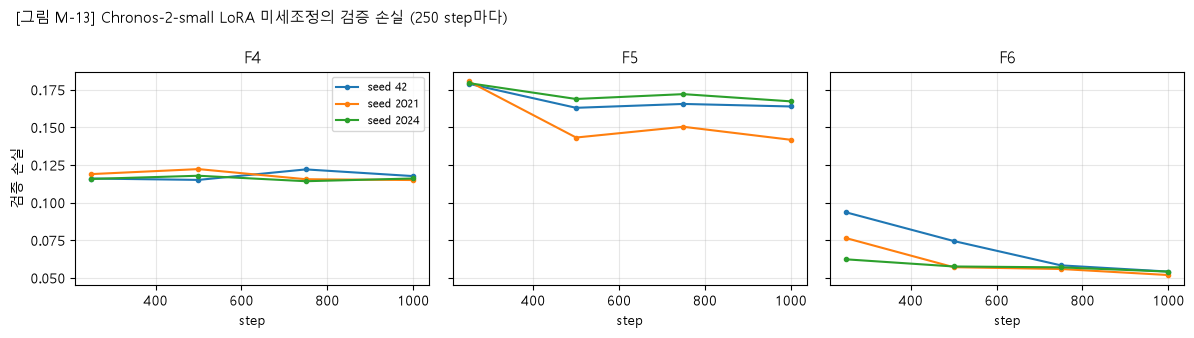

fold·seed별 best step과 학습 시간(초):


,fold,seed,scenario,ctx,best_step,fit_sec
0,F4,2021,S1,1344,1000,3307
1,F4,2024,S1,1344,750,2430
2,F4,42,S1,1344,500,5196
3,F5,2021,S1,1344,1000,3289
4,F5,2024,S1,1344,1000,2423
5,F5,42,S1,1344,500,5317
6,F6,2021,S1,1344,1000,3296
7,F6,2024,S1,1344,1000,2440
8,F6,42,S1,1344,1000,5225


In [44]:
# [코드 M-43] LoRA 미세조정 검증 손실과 best step [그림 M-13]
lh = pd.read_csv(pu.OUT / 'logs' / 'chronos_lora_history.csv', encoding='utf-8-sig')
lr = pd.read_csv(pu.OUT / 'tables' / 'chronos_lora_runs.csv', encoding='utf-8-sig')
ev = lh.dropna(subset=['eval_loss'])
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, (fold, d) in zip(axes, ev.groupby('fold')):
    for seed, s in d.groupby('seed'):
        ax.plot(s['step'], s['eval_loss'], marker='o', ms=3, label=f'seed {seed}')
    ax.set(title=fold, xlabel='step')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('검증 손실'); axes[0].legend(fontsize=8)
fig.suptitle('[그림 M-13] Chronos-2-small LoRA 미세조정의 검증 손실 (250 step마다)', x=0.01, ha='left', fontsize=11)
fig.tight_layout()
pu.save_fig(fig, 'M13_chronos_lora_curve'); plt.show()
print('fold·seed별 best step과 학습 시간(초):'); display(lr)

현장에서 쓰려면 정확도만큼 '하루치 예측을 내는 데 걸리는 시간'도 중요합니다. 모델·트랙별 1일 예측 추론 시간(트랙 A는 매시 24번, 트랙 B는 00시 1번 예측하는 시간)을 CPU 기준으로 정리합니다. 이 PC에는 CUDA GPU가 없어 GPU 시간은 재지 못했고, 다른 계산과 CPU를 나눠 쓴 상태의 값이므로 모델끼리의 상대 비교로 봅니다.

In [45]:
import json
# [코드 M-44] 1일 예측 추론 시간(CPU) [표 M-24]
inf_models = {**fm, 'nhits': 'NHITS', 'lstm': 'LSTM', 'tft': 'TFT', 'xgb': 'XGBoost', 'mstl': 'MSTL+ETS'}
t = cv[(cv['subset'] == 'all') & cv['model'].isin(list(inf_models)) & cv['infer_sec'].notna()]
tbl_m24 = t.groupby(['track', 'model'])['infer_sec'].agg(['median', 'max']).round(3).reset_index()
tbl_m24.columns = ['트랙', 'model', '1일 추론 시간 중앙값(초)', '최대(초)']
tbl_m24.insert(1, '모델', tbl_m24.pop('model').map(inf_models))
# 추론 시간은 전체 재학습(run_all.py --mode full --retrain) 때 잰 값이므로, 장치도 그 실행 기록에서 읽음
measured_cpu = json.loads((pu.OUT / 'run_all_full.json').read_text(encoding='utf-8'))['env']['cpu']
tbl_m24['장치'] = f"CPU ({measured_cpu}), GPU 없음 — 전체 재학습 때 측정"
tbl_m24 = tbl_m24.sort_values(['트랙', '1일 추론 시간 중앙값(초)'], ignore_index=True)
pu.save_table(tbl_m24, 'M24_inference_time')
print('[표 M-24] 1일 예측 추론 시간 (CPU, 다른 계산과 동시 실행 상태)')
display(tbl_m24)

[표 M-24] 1일 예측 추론 시간 (CPU, 다른 계산과 동시 실행 상태)


,트랙,모델,1일 추론 시간 중앙값(초),최대(초),장치
0,A,XGBoost,0.001,0.002,CPU (11th Gen Intel(R) Core(TM) i5-1135G7 @ 2....
1,A,LightGBM(참고),0.004,0.006,CPU (11th Gen Intel(R) Core(TM) i5-1135G7 @ 2....
2,A,NHITS,0.727,1.297,CPU (11th Gen Intel(R) Core(TM) i5-1135G7 @ 2....
3,A,LSTM,0.745,1.033,CPU (11th Gen Intel(R) Core(TM) i5-1135G7 @ 2....
4,A,TFT,1.369,5.285,CPU (11th Gen Intel(R) Core(TM) i5-1135G7 @ 2....
5,A,Chronos-2-small LoRA,8.364,10.591,CPU (11th Gen Intel(R) Core(TM) i5-1135G7 @ 2....
6,A,Chronos-2-small 공변량,13.186,13.554,CPU (11th Gen Intel(R) Core(TM) i5-1135G7 @ 2....
7,A,Chronos-2 zero-shot(단변량),22.895,26.728,CPU (11th Gen Intel(R) Core(TM) i5-1135G7 @ 2....
8,A,MSTL+ETS,47.521,53.294,CPU (11th Gen Intel(R) Core(TM) i5-1135G7 @ 2....
9,A,Chronos-2 공변량,49.014,54.903,CPU (11th Gen Intel(R) Core(TM) i5-1135G7 @ 2....


STEP 5의 완료 조건 세 가지를 코드로 확인합니다. 모두 '통과'가 나와야 다음 단계(STEP 6: 앙상블·불확실성·확률보정)로 넘어갑니다.

In [46]:
# [코드 M-45] STEP 5 완료 조건 점검
have = set(map(tuple, tbl_m23[['모델', 'track', 'scenario']].to_numpy()))
need_models = ['Chronos-2 zero-shot(단변량)', 'Chronos-2 공변량', 'Chronos-2-small LoRA']
checks = {
    'zero-shot vs 공변량 vs 미세조정 비교표 (트랙 × 시나리오)':
        all(any(m == k[0] and tr == k[1] for k in have) for m in need_models for tr in ['A', 'B']),
    '문맥 길이별 MAE 그림': (pu.OUT / 'figures' / 'M12_chronos_context.png').exists(),
    '1일 예측 추론 시간(CPU/GPU) 기록': tbl_m24['모델'].str.startswith('Chronos').any(),
}
for name, ok in checks.items():
    print(f"{'통과' if ok else '실패'} | {name}")
assert all(checks.values())

통과 | zero-shot vs 공변량 vs 미세조정 비교표 (트랙 × 시나리오)
통과 | 문맥 길이별 MAE 그림
통과 | 1일 예측 추론 시간(CPU/GPU) 기록


## [단계 ⑨] 앙상블·불확실성·확률보정·피크 위험 분류

지금까지 만든 모델을 묶고(앙상블), 예측구간을 보정하고, '다음 시간 최대수요전력이 피크 임계값 θ를 넘을 확률'(피크 위험 확률)을 만들어 경보 규칙까지 정합니다. 과제의 '제조 이상 확률'은 이 프로젝트에서 피크 위험 확률로 정의하고 F1로 평가했습니다.

**누수 없이 맞추는 방법**: 앙상블 가중치, 구간 보정량, 확률 보정기, 경보 임계값은 모두 '평가할 fold보다 앞선 fold들의 검증 예측'으로만 맞춥니다. 예를 들어 F4를 평가할 때는 F1~F3의 검증 예측으로 맞춘 값을 씁니다. 그래서 이 단계의 점수는 F2~F6(5 fold)에서 나오며, 테스트(STEP 7)에는 6 fold 전체로 맞춘 설정을 그대로 한 번 적용합니다. 계산은 `scripts/step6_ensemble.py`로 했습니다.

- **앙상블**: 상위 3개 단순평균(ens_top3), 비음수 가중평균(ens_nnls, NNLS: 가중치가 0 이상이 되도록 푸는 최소제곱), 트랙 B는 시간대별 가중(ens_nnls_hour)
- **구간 보정**: LightGBM 분위수와 Chronos-2 분위수를 평균한 뒤, 컨포멀 분위수 회귀(CQR: 실제 구간 밖으로 벗어난 정도의 분위수만큼 구간을 넓혀 목표 커버리지를 맞추는 방법)로 80% 구간을 보정
- **피크 위험 확률**: 경로 1 = 분위수 예측에서 P(y ≥ θ) 계산, 경로 2 = LightGBM 이진분류, 스태킹 = 두 경로와 점예측을 로지스틱 회귀로 결합. 모두 isotonic 회귀(단조 증가 함수로 확률을 실제 빈도에 맞추는 방법)로 보정

이번 STEP의 통합표입니다. 앙상블과 주요 단일 모델을 같은 F2~F6에서 회귀(MAE·피크시간 MAE), 구간(80% 커버리지·폭), 분류(F1·PR-AUC), 보정(Brier·ECE) 지표로 한 번에 비교합니다. ens_final은 ens_nnls 점예측 + CQR 보정 구간 + 보정된 스태킹 확률(이전 fold로 고른 F1 최대 임계값)을 합친 '최종 시스템 후보'입니다.

In [47]:
# [코드 M-46] 회귀·분류·보정·커버리지 통합표 (F2~F6) [표 M-25]
cv = pd.read_csv(pu.CV_PATH, encoding='utf-8-sig')
f26 = ['F2', 'F3', 'F4', 'F5', 'F6']
names6 = {'ens_final': '최종 시스템(ens_final)', 'ens_nnls': '앙상블 NNLS', 'ens_top3': '앙상블 상위3 평균',
          'ens_nnls_hour': '앙상블 시간대별 NNLS', 'lgbm': 'LightGBM', 'lgbm_q': 'LightGBM 분위수', 'xgb': 'XGBoost',
          'nhits': 'NHITS', 'chronos2_cov': 'Chronos-2 공변량', 'chronos2_zs': 'Chronos-2 zero-shot', 'mstl': 'MSTL+ETS'}
a = cv[(cv['subset'] == 'all') & cv['fold'].isin(f26) & cv['model'].isin(list(names6))
       & (cv['scenario'].eq('S1') | cv['model'].isin(['mstl', 'chronos2_zs']))]
g = a.groupby(['track', 'model'])
tbl_m25 = g[['mae', 'peak_mae', 'cov80', 'width80', 'f1', 'precision', 'recall', 'pr_auc', 'brier', 'ece']].mean().round(3)
op = cv[(cv['subset'] == 'op') & cv['fold'].isin(f26)].groupby(['track', 'model'])['mae'].mean().rename('가동일 MAE')
tbl_m25 = tbl_m25.join(op.round(3)).reset_index()
tbl_m25.insert(1, '모델', tbl_m25.pop('model').map(names6))
tbl_m25 = tbl_m25.sort_values(['track', 'mae'], ignore_index=True)
pu.save_table(tbl_m25, 'M25_step6_integrated')
for tr in ['A', 'B']:
    print(f'[표 M-25] 트랙 {tr} — F2~F6 통합 지표 (S1, MSTL·zero-shot은 S0)')
    display(tbl_m25[tbl_m25['track'] == tr].drop(columns='track').reset_index(drop=True))

[표 M-25] 트랙 A — F2~F6 통합 지표 (S1, MSTL·zero-shot은 S0)


,모델,mae,peak_mae,cov80,width80,f1,precision,recall,pr_auc,brier,ece,가동일 MAE
0,Chronos-2 zero-shot,5.897,7.612,0.704,17.369,0.721,0.793,0.673,0.805,NaN,NaN,7.407
1,Chronos-2 공변량,6.145,8.231,0.713,18.161,0.675,0.762,0.622,0.789,NaN,NaN,7.720
2,최종 시스템(ens_final),6.183,8.966,0.827,21.341,0.785,0.750,0.839,0.801,0.045,0.035,7.239
3,앙상블 NNLS,6.183,8.966,NaN,NaN,0.667,0.882,0.557,0.843,NaN,NaN,7.239
4,앙상블 상위3 평균,6.565,10.502,NaN,NaN,0.604,0.845,0.489,0.807,NaN,NaN,8.033
5,LightGBM 분위수,6.668,13.056,0.591,20.497,0.479,0.718,0.377,0.780,NaN,NaN,8.876
6,LightGBM,7.007,11.325,NaN,NaN,0.581,0.831,0.465,0.789,NaN,NaN,8.393
7,XGBoost,7.139,11.587,NaN,NaN,0.610,0.815,0.499,0.770,NaN,NaN,8.524
8,MSTL+ETS,8.917,10.711,0.848,31.575,0.629,0.806,0.529,0.769,NaN,NaN,9.041
9,NHITS,9.715,12.232,NaN,NaN,0.601,0.747,0.516,0.739,NaN,NaN,10.101


[표 M-25] 트랙 B — F2~F6 통합 지표 (S1, MSTL·zero-shot은 S0)


,모델,mae,peak_mae,cov80,width80,f1,precision,recall,pr_auc,brier,ece,가동일 MAE
0,Chronos-2 공변량,9.217,11.493,0.708,27.500,0.539,0.646,0.481,0.660,NaN,NaN,11.015
1,앙상블 상위3 평균,9.982,15.251,NaN,NaN,0.439,0.702,0.342,0.696,NaN,NaN,10.576
2,최종 시스템(ens_final),10.910,14.601,0.779,31.119,0.674,0.615,0.782,0.648,0.069,0.048,10.456
3,앙상블 NNLS,10.910,14.601,NaN,NaN,0.410,0.610,0.312,0.701,NaN,NaN,10.456
4,Chronos-2 zero-shot,10.989,16.271,0.709,27.497,0.551,0.633,0.501,0.628,NaN,NaN,11.774
5,앙상블 시간대별 NNLS,11.380,16.043,NaN,NaN,0.406,0.745,0.311,0.688,NaN,NaN,10.987
6,XGBoost,12.499,17.820,NaN,NaN,0.334,0.652,0.247,0.621,NaN,NaN,14.784
7,LightGBM,13.659,20.585,NaN,NaN,0.368,0.723,0.281,0.667,NaN,NaN,15.105
8,LightGBM 분위수,14.689,24.444,0.349,19.854,0.344,0.672,0.260,0.667,NaN,NaN,16.549
9,MSTL+ETS,17.125,20.558,0.918,84.810,0.373,0.536,0.304,0.564,NaN,NaN,14.937


테스트에 적용할 앙상블 가중치(6 fold 전체로 맞춘 값)와, 평가 fold마다 이전 fold로 맞춘 가중치를 봅니다. 가중치가 몇 개 모델에 몰려 있으면 그 모델들이 서로 다른 정보를 보완한다는 뜻이고, fold마다 크게 바뀌면 가중치가 불안정하다는 뜻입니다.

In [48]:
# [코드 M-47] 앙상블 가중치 (테스트용 6 fold 전체 / fold별) [표 M-26]
cfg6 = json.loads((pu.OUT / 'tables' / 'step6_final_config.json').read_text(encoding='utf-8'))
w_final = pd.DataFrame({tr: pd.Series(cfg6[tr]['nnls_weights']) for tr in ['A', 'B']}).fillna(0).round(3)
w_final.loc['상위 3개(단순평균)'] = [', '.join(cfg6[tr]['top3']) for tr in ['A', 'B']]
pu.save_table(w_final.reset_index().rename(columns={'index': '모델'}), 'M26_ensemble_weights_final')
print('[표 M-26] 테스트에 적용할 NNLS 가중치(6 fold 전체로 맞춤)'); display(w_final)
wf = pd.read_csv(pu.OUT / 'tables' / 'step6_ensemble_weights.csv', encoding='utf-8-sig')
print('평가 fold별 가중치(이전 fold로 맞춤):'); display(wf.set_index(['track', 'fold']).dropna(axis=1, how='all'))

[표 M-26] 테스트에 적용할 NNLS 가중치(6 fold 전체로 맞춤)

,A,B
arima,0.0,0.0
cat,0.11,0.0
chronos2_cov,0.02,0.521
chronos2_zs,0.414,0.0
guidebook_rf,0.0,0.0
lgbm,0.13,0.0
lgbm_peakw,0.0,0.0
lgbm_q,0.0,0.0
lstm,0.324,0.0
mstl,0.0,0.0


평가 fold별 가중치(이전 fold로 맞춤):


top3  w_lgbm  w_lgbm_q  w_lgbm_peakw  \
track fold                                                                    
A     F2             lgbm,lgbm_peakw,lgbm_q   0.429     0.013         0.215   
      F3             lgbm_q,lgbm,lgbm_peakw   0.424     0.095         0.000   
      F4                    lgbm_q,lgbm,cat   0.000     0.000         0.000   
      F5            chronos2_zs,lgbm_q,lgbm   0.269     0.000         0.000   
      F6    chronos2_zs,chronos2_cov,lgbm_q   0.124     0.000         0.000   
B     F2    chronos2_zs,chronos2_cov,lgbm_q   0.245     0.063         0.000   
      F3    chronos2_zs,chronos2_cov,lgbm_q   0.195     0.000         0.000   
      F4       chronos2_zs,chronos2_cov,xgb   0.000     0.151         0.000   
      F5       chronos2_cov,chronos2_zs,xgb   0.000     0.000         0.000   
      F6       chronos2_cov,chronos2_zs,xgb   0.000     0.000         0.000   

            w_xgb  w_cat  w_nhits  w_lstm  w_chronos2_cov  w_chronos2_zs  \
track fold                                                                 
A     F2    0.000  0.304    0.012   0.000           0.027          0.000   
      F3    0.000  0.338    0.000   0.000           0.000          0.143   
      F4    0.000  0.413    0.157   0.004           0.000          0.426   
      F5    0.000  0.026    0.052   0.228           0.000          0.425   
      F6    0.000  0.108    0.000   0.324           0.052          0.392   
B     F2    0.000  0.000    0.120   0.087           0.138          0.349   
      F3    0.000  0.000    0.092   0.042           0.000          0.646   
      F4    0.185  0.000    0.000   0.078           0.111          0.475   
      F5    0.639  0.000    0.000   0.000           0.361          0.000   
      F6    0.500  0.000    0.000   0.000           0.500          0.000   

            w_mstl  w_guidebook_rf  w_arima  
track fold                                   
A     F2     0.000             0.0      NaN  
      F3     0.000             0.0      NaN  
      F4     0.000             0.0      NaN  
      F5     0.000             0.0      NaN  
      F6     0.000             0.0      NaN  
B     F2     0.000             NaN      0.0  
      F3     0.025             NaN      0.0  
      F4     0.000             NaN      0.0  
      F5     0.000             NaN      0.0  
      F6     0.000             NaN      0.0

80% 예측구간이 실제로 80%를 담는지(커버리지) 보정 전후로 비교합니다. 목표는 0.80 ± 0.03이며, 같은 커버리지라면 구간 폭이 좁을수록 쓸모 있는 구간입니다. 기본 보정은 '가장 최근 이전 fold 하나로 전체 보정'이고, 이전 fold 전체를 그룹별로 쓰는 방식은 뒤 fold의 분포 변화를 못 따라가 커버리지가 낮아 비교용으로 함께 둡니다.

[표 M-27] 80% 구간 커버리지·폭 (F2~F6, fold별 최소·최대 포함)


,track,interval,cov80_mean,cov80_min,cov80_max,width80_mean,width80_min,width80_max,목표 0.80±0.03
0,A,chronos2_cov(CQR),0.797,0.747,0.812,19.792,16.854,24.908,달성
1,A,chronos2_cov(보정 전),0.713,0.643,0.756,18.161,16.006,22.786,미달/초과
2,A,ens_q(CQR 비교: 이전 fold 전체·그룹 8개),0.768,0.729,0.842,21.243,18.394,23.371,미달/초과
3,A,ens_q(CQR),0.827,0.741,0.893,21.341,17.058,26.624,달성
4,A,ens_q(보정 전),0.733,0.696,0.782,19.329,15.997,21.154,미달/초과
5,A,lgbm_q(CQR),0.787,0.631,0.899,25.496,18.946,36.590,달성
6,A,lgbm_q(보정 전),0.607,0.539,0.644,20.497,15.684,24.784,미달/초과
7,B,chronos2_cov(CQR),0.804,0.729,0.887,29.409,18.069,39.672,달성
8,B,chronos2_cov(보정 전),0.708,0.640,0.759,27.500,17.774,37.682,미달/초과
9,B,ens_q(CQR 비교: 이전 fold 전체·그룹 8개),0.772,0.640,0.851,31.511,23.473,43.559,달성


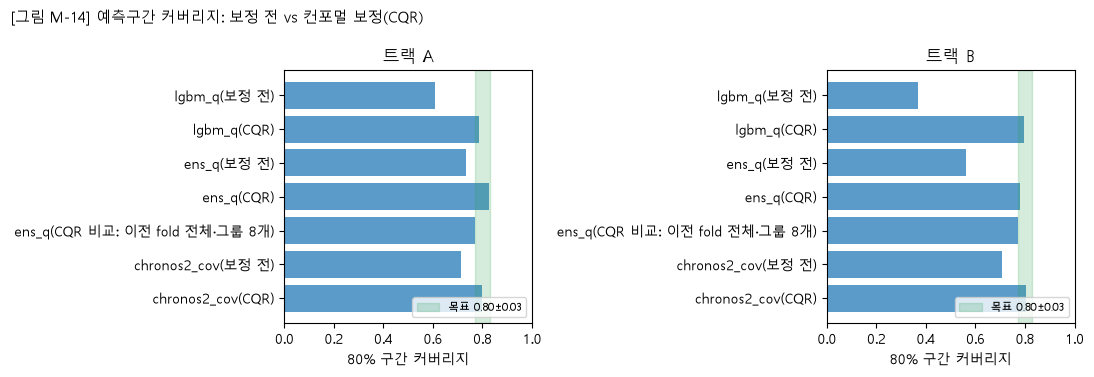

In [49]:
# [코드 M-48] 80% 구간 커버리지·폭: 보정 전후 [표 M-27, 그림 M-14]
cov6 = pd.read_csv(pu.OUT / 'tables' / 'step6_coverage.csv', encoding='utf-8-sig')
tbl_m27 = cov6.groupby(['track', 'interval'])[['cov80', 'width80']].agg(['mean', 'min', 'max']).round(3)
tbl_m27.columns = [f'{a}_{b}' for a, b in tbl_m27.columns]
tbl_m27['목표 0.80±0.03'] = np.where(tbl_m27['cov80_mean'].between(0.77, 0.83), '달성', '미달/초과')
tbl_m27 = tbl_m27.reset_index()
pu.save_table(tbl_m27, 'M27_interval_coverage')
print('[표 M-27] 80% 구간 커버리지·폭 (F2~F6, fold별 최소·최대 포함)'); display(tbl_m27)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, tr in zip(axes, ['A', 'B']):
    d = tbl_m27[tbl_m27['track'] == tr]
    ax.barh(d['interval'], d['cov80_mean'], color='#3182bd', alpha=0.8)
    ax.axvspan(0.77, 0.83, color='#31a354', alpha=0.2, label='목표 0.80±0.03')
    ax.set(title=f'트랙 {tr}', xlabel='80% 구간 커버리지', xlim=(0, 1))
    ax.legend(fontsize=8, loc='lower right')
fig.suptitle('[그림 M-14] 예측구간 커버리지: 보정 전 vs 컨포멀 보정(CQR)', x=0.01, ha='left', fontsize=11)
fig.tight_layout()
pu.save_fig(fig, 'M14_interval_coverage'); plt.show()

피크 위험 확률이 '말하는 확률'과 '실제 피크 비율'이 맞는지 신뢰도 곡선(reliability curve)으로 봅니다. 확률을 10구간으로 나눠 구간마다 평균 확률(가로)과 실제 피크 비율(세로)을 찍으며, 대각선에 가까울수록 확률을 그대로 믿을 수 있습니다. Brier(확률 오차의 제곱 평균)와 ECE(구간별 어긋남의 가중평균)는 작을수록 좋습니다.

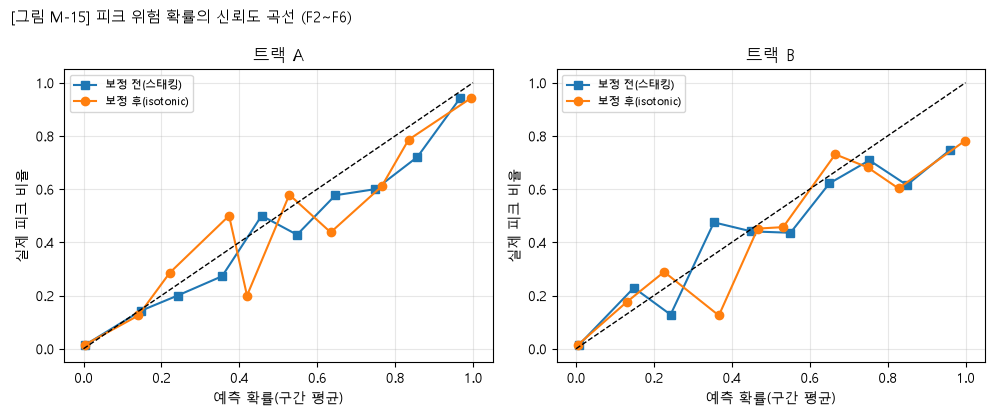

[표 M-28] 확률보정 전후 Brier·ECE (F2~F6 평균)


,track,path,brier_보정전,ece_보정전,brier_보정후,ece_보정후
0,A,경로1 Chronos-2 분위수,0.0469,0.0355,0.0472,0.0300
1,A,경로1 ens_q 분위수,0.0522,0.0510,0.0462,0.0394
2,A,경로2 분류기(가중),0.0508,0.0503,0.0497,0.0456
3,A,스태킹,0.0442,0.0367,0.0450,0.0352
4,B,경로1 Chronos-2 분위수,0.0670,0.0542,0.0690,0.0524
5,B,경로1 ens_q 분위수,0.0746,0.0651,0.0687,0.0524
6,B,경로2 분류기(가중),0.0784,0.0738,0.0708,0.0491
7,B,스태킹,0.0676,0.0485,0.0687,0.0478


In [50]:
# [코드 M-49] 확률보정: 신뢰도 곡선(스태킹, 보정 전후)과 Brier·ECE [그림 M-15, 표 M-28]
cases6 = pd.read_csv(pu.OUT / 'tables' / 'step6_alarm_cases.csv', encoding='utf-8-sig')
cases6 = cases6[~cases6['outage']]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
bins = np.linspace(0, 1, 11)
for ax, tr in zip(axes, ['A', 'B']):
    d = cases6[cases6['track'] == tr]
    for col, label, mk in [('p_raw', '보정 전(스태킹)', 's'), ('p_peak', '보정 후(isotonic)', 'o')]:
        b = np.clip(np.digitize(d[col], bins[1:-1]), 0, 9)
        r = d.groupby(b).agg(p=(col, 'mean'), y=('peak', 'mean'), n=('peak', 'size'))
        ax.plot(r['p'], r['y'], marker=mk, label=label)
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set(title=f'트랙 {tr}', xlabel='예측 확률(구간 평균)', ylabel='실제 피크 비율')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle('[그림 M-15] 피크 위험 확률의 신뢰도 곡선 (F2~F6)', x=0.01, ha='left', fontsize=11)
fig.tight_layout()
pu.save_fig(fig, 'M15_reliability'); plt.show()
cal6 = pd.read_csv(pu.OUT / 'tables' / 'step6_calibration.csv', encoding='utf-8-sig')
tbl_m28 = cal6.groupby(['track', 'path']).mean(numeric_only=True).round(4).reset_index()
pu.save_table(tbl_m28, 'M28_calibration')
print('[표 M-28] 확률보정 전후 Brier·ECE (F2~F6 평균)'); display(tbl_m28)

### 경보 임계값: 왜 놓친 피크(FN)가 더 비싼가

기본요금의 기준이 되는 요금적용전력은 '검침 당월을 포함한 직전 12개월 중 7~9월·12~2월과 당월의 최대수요전력 가운데 가장 큰 값'으로 정해집니다. 그래서 피크를 한 번 놓치면(FN) 그 높은 값이 **최대 12개월 동안 기본요금에 반영**되지만, 헛경보(FP)는 그 시간에 부하를 잠깐 조정하는 비용만 듭니다. 이 비대칭을 반영해 F1 최대 임계값과 함께, FN 하나를 FP 1·3·5·10개만큼 비싸게 보는 비용가중 임계값도 이전 fold로 골라 비교합니다. 과금 피크는 기본요금에 반영되는 중간·최대부하 시간의 피크만 센 라벨이고, 2023년 개정 시간대 기준(08시 포함)도 민감도로 함께 봅니다.

In [51]:
# [코드 M-50] 경로 × 임계값 규칙 × 라벨별 경보 성능 [표 M-29]
cls6 = pd.read_csv(pu.OUT / 'tables' / 'step6_classification.csv', encoding='utf-8-sig')
tbl_m29 = cls6.groupby(['track', 'label', 'path', 'rule'])[['f1', 'precision', 'recall', 'fn', 'fp', 'threshold']].mean().round(3)
tbl_m29 = tbl_m29.reset_index()
pu.save_table(tbl_m29, 'M29_alarm_rules')
for tr in ['A', 'B']:
    d = tbl_m29[(tbl_m29['track'] == tr) & (tbl_m29['label'] == '단순 피크')].drop(columns=['track', 'label'])
    print(f'[표 M-29] 트랙 {tr} — 단순 피크 경보 (F2~F6 fold 평균, FN·FP는 fold당 개수)'); display(d.reset_index(drop=True))
best = tbl_m29[tbl_m29['rule'] == 'F1 최대'].sort_values('f1', ascending=False).groupby(['track', 'label']).head(1)
print('라벨별 F1 최대 경로:'); display(best[['track', 'label', 'path', 'f1', 'recall', 'precision']].reset_index(drop=True))

[표 M-29] 트랙 A — 단순 피크 경보 (F2~F6 fold 평균, FN·FP는 fold당 개수)


,path,rule,f1,precision,recall,fn,fp,threshold
0,경로1 Chronos-2 분위수,F1 최대,0.730,0.667,0.810,7.8,17.0,0.345
1,경로1 Chronos-2 분위수,비용 FN:FP=10:1,0.722,0.591,0.963,1.8,30.8,0.069
2,경로1 Chronos-2 분위수,비용 FN:FP=1:1,0.731,0.736,0.734,11.4,10.6,0.430
3,경로1 Chronos-2 분위수,비용 FN:FP=3:1,0.729,0.604,0.954,2.2,29.0,0.173
4,경로1 Chronos-2 분위수,비용 FN:FP=5:1,0.726,0.598,0.959,2.0,30.0,0.103
5,경로1 ens_q 분위수,F1 최대,0.748,0.731,0.792,9.2,14.2,0.337
6,경로1 ens_q 분위수,비용 FN:FP=10:1,0.736,0.612,0.961,1.8,29.2,0.059
7,경로1 ens_q 분위수,비용 FN:FP=1:1,0.741,0.809,0.706,13.4,7.2,0.399
8,경로1 ens_q 분위수,비용 FN:FP=3:1,0.751,0.650,0.921,3.8,23.0,0.157
9,경로1 ens_q 분위수,비용 FN:FP=5:1,0.740,0.625,0.948,2.6,27.0,0.083


[표 M-29] 트랙 B — 단순 피크 경보 (F2~F6 fold 평균, FN·FP는 fold당 개수)


,path,rule,f1,precision,recall,fn,fp,threshold
0,경로1 Chronos-2 분위수,F1 최대,0.673,0.566,0.852,7.0,29.8,0.289
1,경로1 Chronos-2 분위수,비용 FN:FP=10:1,0.602,0.441,0.972,1.6,54.8,0.009
2,경로1 Chronos-2 분위수,비용 FN:FP=1:1,0.689,0.600,0.834,7.8,26.2,0.408
3,경로1 Chronos-2 분위수,비용 FN:FP=3:1,0.649,0.508,0.921,3.6,40.0,0.168
4,경로1 Chronos-2 분위수,비용 FN:FP=5:1,0.636,0.492,0.928,3.4,43.8,0.105
5,경로1 ens_q 분위수,F1 최대,0.638,0.594,0.761,9.4,25.8,0.329
6,경로1 ens_q 분위수,비용 FN:FP=10:1,0.621,0.468,0.939,2.6,47.8,0.047
7,경로1 ens_q 분위수,비용 FN:FP=1:1,0.561,0.636,0.599,15.8,15.6,0.464
8,경로1 ens_q 분위수,비용 FN:FP=3:1,0.626,0.504,0.859,5.4,38.2,0.206
9,경로1 ens_q 분위수,비용 FN:FP=5:1,0.631,0.484,0.922,3.2,43.6,0.115


라벨별 F1 최대 경로:


,track,label,path,f1,recall,precision
0,A,과금 피크(2023 시간대),스태킹,0.799,0.854,0.763
1,A,과금 피크,스태킹,0.790,0.832,0.763
2,A,단순 피크,스태킹,0.785,0.839,0.750
3,B,과금 피크(2023 시간대),경로2 분류기(가중),0.690,0.837,0.598
4,B,과금 피크,경로2 분류기(가중),0.676,0.812,0.588
5,B,단순 피크,경로2 분류기(가중),0.676,0.822,0.585


피크는 전체 시간의 5~19%뿐인 불균형 문제라, 불균형을 다루는 네 가지 방법을 같은 조건에서 비교합니다: 가중 없는 분류, 클래스 가중 분류(피크 표본에 더 큰 가중치), 피크 가중 회귀의 점예측이 θ를 넘으면 경보, 분위수 0.9 예측이 θ를 넘으면 경보. 재현율(놓치지 않는 비율)과 정밀도(경보가 맞는 비율)의 균형을 F1·PR-AUC로 봅니다.

In [52]:
# [코드 M-51] 불균형 학습 방법 비교 [표 M-30]
imb6 = pd.read_csv(pu.OUT / 'tables' / 'step6_imbalance.csv', encoding='utf-8-sig')
tbl_m30 = imb6.groupby(['track', 'method'])[['f1', 'precision', 'recall', 'pr_auc', 'fn', 'fp']].mean().round(3)
tbl_m30 = tbl_m30.reset_index().sort_values(['track', 'f1'], ascending=[True, False], ignore_index=True)
pu.save_table(tbl_m30, 'M30_imbalance')
print('[표 M-30] 불균형 학습 방법별 피크 경보 성능 (F2~F6 평균)'); display(tbl_m30)

[표 M-30] 불균형 학습 방법별 피크 경보 성능 (F2~F6 평균)


,track,method,f1,precision,recall,pr_auc,fn,fp
0,A,가중 없음 분류,0.761,0.724,0.810,0.818,7.6,14.8
1,A,클래스 가중 분류,0.754,0.684,0.851,0.821,6.4,17.8
2,A,분위수 0.9 경보(q90 ≥ θ),0.718,0.707,0.747,0.790,11.0,14.0
3,A,피크 가중 회귀(ŷ ≥ θ),0.588,0.824,0.486,0.799,21.4,3.4
4,A,L2 회귀(ŷ ≥ θ),0.586,0.837,0.472,0.789,22.6,2.8
5,B,가중 없음 분류,0.676,0.592,0.819,0.648,8.0,28.0
6,B,클래스 가중 분류,0.676,0.585,0.822,0.651,8.0,27.4
7,B,분위수 0.9 경보(q90 ≥ θ),0.477,0.601,0.490,0.681,20.8,14.4
8,B,피크 가중 회귀(ŷ ≥ θ),0.376,0.713,0.288,0.684,32.2,5.0
9,B,L2 회귀(ŷ ≥ θ),0.359,0.706,0.271,0.670,33.2,5.2


최종 시스템 후보(ens_final)의 혼동행렬(실제 피크 × 경보 여부)과, 놓친 피크(FN)·헛경보(FP)가 어떤 조건에서 생겼는지 정리합니다. 시각·요일·TOU·가동 여부·생산계획 구간·비가동 후 첫 가동일별로 FN·FP 수를 세어 저장하며, 이 표는 평가 3번(영향요인·FN/FP 분석)의 재료가 됩니다.

In [53]:
# [코드 M-52] 혼동행렬과 FN·FP 조건별 집계 [표 M-31, 표 M-32]
c = cases6.copy()
tbl_m31 = c.groupby('track').apply(lambda d: pd.Series({
    'TP(맞힌 피크)': int((d['peak'] & d['alarm']).sum()), 'FN(놓친 피크)': int((d['peak'] & ~d['alarm']).sum()),
    'FP(헛경보)': int((~d['peak'] & d['alarm']).sum()), 'TN': int((~d['peak'] & ~d['alarm']).sum())}), include_groups=False)
pu.save_table(tbl_m31.reset_index(), 'M31_confusion_ens_final')
print('[표 M-31] ens_final 혼동행렬 (F2~F6 합계, outage 제외)'); display(tbl_m31)
fnfp = c[c['type'].isin(['FN', 'FP'])]
rows = []
for col in ['hour', 'dow', 'tou_load', 'op_day', 'prod_bin', 'after_shutdown']:
    t = fnfp.groupby(['track', 'type', col]).size().rename('건수').reset_index().rename(columns={col: '값'})
    rows.append(t.assign(조건=col))
tbl_m32 = pd.concat(rows, ignore_index=True)[['track', 'type', '조건', '값', '건수']]
pu.save_table(tbl_m32, 'M32_fn_fp_conditions')
top = tbl_m32.sort_values('건수', ascending=False).groupby(['track', 'type', '조건']).head(2)
print('[표 M-32] FN·FP가 많이 난 조건 (조건별 상위 2개, 전체는 outputs/tables/M32_fn_fp_conditions.csv)')
display(top.sort_values(['track', 'type', '조건']).reset_index(drop=True))

[표 M-31] ens_final 혼동행렬 (F2~F6 합계, outage 제외)


,TP(맞힌 피크),FN(놓친 피크),FP(헛경보),TN
track,,,,
A,193,37,63,1368
B,185,45,120,1311


[표 M-32] FN·FP가 많이 난 조건 (조건별 상위 2개, 전체는 outputs/tables/M32_fn_fp_conditions.csv)

,track,type,조건,값,건수
0,A,FN,after_shutdown,False,28
1,A,FN,after_shutdown,True,9
2,A,FN,dow,1,10
3,A,FN,dow,0,9
4,A,FN,hour,18,5
5,A,FN,hour,17,5
6,A,FN,op_day,True,37
7,A,FN,prod_bin,높음,15
8,A,FN,prod_bin,결손,10
9,A,FN,tou_load,최대부하,17


STEP 6의 완료 조건 두 가지를 확인합니다. 모두 '통과'가 나와야 다음 단계(STEP 7: 최종 선정)로 넘어갑니다.

In [54]:
# [코드 M-53] STEP 6 완료 조건 점검
need = ['mae', 'f1', 'brier', 'ece', 'cov80']
checks = {
    '회귀·분류·보정·커버리지 지표 통합표': (pu.OUT / 'tables' / 'M25_step6_integrated.csv').exists()
        and tbl_m25.loc[tbl_m25['모델'].str.startswith('최종'), need].notna().all().all(),
    '혼동행렬(FN·FP)과 FN/FP 사례의 조건 컬럼 저장': (pu.OUT / 'tables' / 'step6_fn_fp_cases.csv').exists()
        and {'hour', 'dow', 'tou_load', 'op_day', 'prod_bin', 'after_shutdown'} <= set(
            pd.read_csv(pu.OUT / 'tables' / 'step6_fn_fp_cases.csv', nrows=1).columns),
}
for name, ok in checks.items():
    print(f"{'통과' if ok else '실패'} | {name}")
assert all(checks.values())

통과 | 회귀·분류·보정·커버리지 지표 통합표


통과 | 혼동행렬(FN·FP)과 FN/FP 사례의 조건 컬럼 저장


## [단계 ⑩] 최종 모델 선정과 결과 정리

지금까지의 모든 모델을 한 표에 모으고, **실험 전에 정해 둔 선정 규칙**을 그대로 적용해 트랙별 최종 모델을 고릅니다. 그 뒤 테스트 구간(2021-09-01~09-14)을 **이 단계에서 단 한 번** 평가합니다.

**선정 규칙**(STEP 4·5 결과와 테스트를 보기 전에 기록, 트랙 A·B 따로 적용)
1. 후보: 배포 때 쓸 수 있는 정보만 쓰는 모델(S0·S1). S2(가동 여부 오라클)는 상한 참고용. 앙상블이 F2~F6만 평가되므로 공통 fold F2~F6에서 비교
2. 1순위 지표: 가동일 MAE(F2~F6 평균)가 가장 작은 모델이 기준 1위
3. 동등: 1위와 Diebold–Mariano 검정(HLN 보정) p ≥ 0.05 **이고** 가동일 MAE가 1위의 1.05배 이내
4. 동등 후보 중 피크 F1이 1위보다 0.05 넘게 낮으면 제외
5. 남은 후보 중 가장 단순·저비용·배포 쉬운 모델(나이브 < 통계 < 단일 트리 < 단일 딥러닝 < 파운데이션 zero-shot < 앙상블)
6. 피크 경보: STEP 6 확률 경로 중 F1이 가장 높은 경로, 차이가 0.02 이내면 더 단순한 경로
7. 테스트 결과를 보고 선정을 바꾸지 않음

> 3번의 'MAE 1.05배 이내' 조건은 테스트 전에 보완했습니다. 시간 단위 DM 검정은 휴가 fold의 큰 오차 때문에 검정력이 낮아, 훨씬 나쁜 나이브 모델도 '차이 없음'이 되는 문제가 일부 결과로 시험 적용할 때 드러났기 때문입니다.

모든 모델 × 트랙 × 시나리오의 검증 성능과 비용, 라이선스, 설명가능성을 한 표에 모아 `outputs/tables/final_comparison.csv`로 저장합니다. 화면에는 트랙별로 F2~F6 가동일 MAE가 작은 상위 15개만 보여 줍니다. 'fold 수'가 6보다 작은 모델(앙상블 5, TFT·Chronos-2-small 3)은 비교 구간이 다르다는 점에 주의합니다.

In [55]:
# [코드 M-54] 종합 비교표: 모델 × 트랙 × 시나리오 [표 M-33] → final_comparison.csv
cv = pd.read_csv(pu.CV_PATH, encoding='utf-8-sig')
fam = {'naive': ('규칙(라이선스 없음)', '매우 높음(규칙)'), 'guidebook_rf': ('BSD-3(scikit-learn)', '중간~높음(SHAP·중요도)'),
       'lgbm': ('MIT(LightGBM)', '중간~높음(SHAP·중요도)'), 'xgb': ('Apache-2.0', '중간~높음(SHAP·중요도)'),
       'cat': ('Apache-2.0', '중간~높음(SHAP·중요도)'), 'mstl': ('Apache-2.0(statsforecast)', '높음(성분 분해)'),
       'arima': ('Apache-2.0(statsforecast)', '높음(회귀 계수)'), 'guidebook_rnn': ('Apache-2.0(Keras)·BSD(PyTorch)', '낮음'),
       'nhits': ('Apache-2.0(neuralforecast)', '낮음'), 'lstm': ('Apache-2.0(neuralforecast)', '낮음'),
       'tft': ('Apache-2.0(neuralforecast)', '중간(어텐션 가중치)'), 'chronos2': ('Apache-2.0(가중치 포함)', '낮음(사전학습 대형 모델)'),
       'ens': ('구성 모델과 같음', '낮음~중간(가중치 공개)')}
meta = lambda m: next(v for k, v in fam.items() if m.startswith(k))
g = cv[cv['subset'] == 'all'].groupby(['track', 'scenario', 'model'])
fc = pd.DataFrame({'MAE 평균': g['mae'].mean(), 'MAE 표준편차': g['mae'].std(), 'MAE 중앙값': g['mae'].median(),
                   'MASE': g['mase'].mean(), '피크시간 MAE': g['peak_mae'].mean(), 'F1': g['f1'].mean(),
                   'PR-AUC': g['pr_auc'].mean(), 'Brier': g['brier'].mean(), '80% 커버리지': g['cov80'].mean(),
                   '학습 시간 중앙값(초)': g['train_sec'].median(), '1일 추론 시간 중앙값(초)': g['infer_sec'].median(),
                   'fold 수': g['fold'].nunique()})
op = cv[(cv['subset'] == 'op') & cv['fold'].isin(pu.SELECT_FOLDS)].groupby(['track', 'scenario', 'model'])['mae'].mean()
fc['가동일 MAE(F2~F6)'] = op
fc = fc.reset_index()
fc['라이선스'] = fc['model'].map(lambda m: meta(m)[0])
fc['설명가능성'] = fc['model'].map(lambda m: meta(m)[1])
fc = fc.round(3).sort_values(['track', '가동일 MAE(F2~F6)'], ignore_index=True)
pu.save_table(fc, 'final_comparison')
for tr in ['A', 'B']:
    print(f'[표 M-33] 트랙 {tr} — 종합 비교 상위 15개 (가동일 MAE 순, 전체는 outputs/tables/final_comparison.csv)')
    display(fc[fc['track'] == tr].drop(columns='track').head(15).reset_index(drop=True))

[표 M-33] 트랙 A — 종합 비교 상위 15개 (가동일 MAE 순, 전체는 outputs/tables/final_comparison.csv)

,scenario,model,MAE 평균,MAE 표준편차,MAE 중앙값,MASE,피크시간 MAE,F1,PR-AUC,Brier,80% 커버리지,학습 시간 중앙값(초),1일 추론 시간 중앙값(초),fold 수,가동일 MAE(F2~F6),라이선스,설명가능성
0,S1,ens_final,6.183,2.190,5.492,0.310,8.966,0.785,0.801,0.045,0.827,NaN,NaN,5,7.239,구성 모델과 같음,낮음~중간(가중치 공개)
1,S1,ens_nnls,6.183,2.190,5.492,0.310,8.966,0.667,0.843,NaN,NaN,NaN,NaN,5,7.239,구성 모델과 같음,낮음~중간(가중치 공개)
2,S0,chronos2_zs,5.648,1.309,5.248,0.279,7.530,0.721,0.806,NaN,0.709,NaN,22.895,6,7.407,Apache-2.0(가중치 포함),낮음(사전학습 대형 모델)
3,S1,chronos2s_cov,5.863,0.902,5.757,0.289,8.485,0.656,0.743,NaN,0.746,NaN,13.186,3,7.483,Apache-2.0(가중치 포함),낮음(사전학습 대형 모델)
4,S2,chronos2_cov,5.826,1.423,5.394,0.287,8.190,0.682,0.789,NaN,0.724,NaN,54.001,6,7.621,Apache-2.0(가중치 포함),낮음(사전학습 대형 모델)
5,S0,chronos2_cov,5.949,1.373,5.565,0.293,8.177,0.689,0.788,NaN,0.706,NaN,38.406,6,7.741,Apache-2.0(가중치 포함),낮음(사전학습 대형 모델)
6,S1,chronos2_cov,5.942,1.369,5.521,0.293,8.178,0.677,0.788,NaN,0.723,NaN,49.014,6,7.797,Apache-2.0(가중치 포함),낮음(사전학습 대형 모델)
7,S1,chronos2s_lora,6.707,1.309,6.028,0.333,9.041,0.626,0.711,NaN,0.707,3295.740,8.364,3,8.027,Apache-2.0(가중치 포함),낮음(사전학습 대형 모델)
8,S1,ens_top3,6.565,2.460,6.020,0.330,10.502,0.604,0.807,NaN,NaN,NaN,NaN,5,8.033,구성 모델과 같음,낮음~중간(가중치 공개)
9,S2,xgb,5.764,2.779,5.991,0.288,9.294,0.649,0.816,NaN,NaN,3.730,0.002,6,8.210,Apache-2.0,중간~높음(SHAP·중요도)


[표 M-33] 트랙 B — 종합 비교 상위 15개 (가동일 MAE 순, 전체는 outputs/tables/final_comparison.csv)


,scenario,model,MAE 평균,MAE 표준편차,MAE 중앙값,MASE,피크시간 MAE,F1,PR-AUC,Brier,80% 커버리지,학습 시간 중앙값(초),1일 추론 시간 중앙값(초),fold 수,가동일 MAE(F2~F6),라이선스,설명가능성
0,S1,chronos2s_cov,9.237,4.355,7.180,0.462,10.588,0.578,0.626,NaN,0.749,NaN,0.513,3,9.070,Apache-2.0(가중치 포함),낮음(사전학습 대형 모델)
1,S1,chronos2s_lora,9.695,4.369,7.140,0.488,10.014,0.528,0.612,NaN,0.721,3295.740,0.351,3,9.362,Apache-2.0(가중치 포함),낮음(사전학습 대형 모델)
2,S2,chronos2_cov,7.881,2.592,6.348,0.391,11.315,0.518,0.663,NaN,0.716,NaN,2.640,6,9.678,Apache-2.0(가중치 포함),낮음(사전학습 대형 모델)
3,S1,chronos2_cov,8.686,3.385,7.122,0.433,11.573,0.517,0.652,NaN,0.722,NaN,2.115,6,10.321,Apache-2.0(가중치 포함),낮음(사전학습 대형 모델)
4,S1,ens_final,10.910,4.830,11.410,0.552,14.601,0.674,0.648,0.069,0.779,NaN,NaN,5,10.456,구성 모델과 같음,낮음~중간(가중치 공개)
5,S1,ens_nnls,10.910,4.830,11.410,0.552,14.601,0.410,0.701,NaN,NaN,NaN,NaN,5,10.456,구성 모델과 같음,낮음~중간(가중치 공개)
6,S1,ens_top3,9.982,4.117,9.643,0.504,15.251,0.439,0.696,NaN,NaN,NaN,NaN,5,10.576,구성 모델과 같음,낮음~중간(가중치 공개)
7,S1,ens_nnls_hour,11.380,5.295,11.593,0.576,16.043,0.406,0.688,NaN,NaN,NaN,NaN,5,10.987,구성 모델과 같음,낮음~중간(가중치 공개)
8,S2,xgb,8.664,2.113,8.849,0.429,14.110,0.360,0.676,NaN,NaN,1.180,0.001,6,11.049,Apache-2.0,중간~높음(SHAP·중요도)
9,S2,lgbm_peakw,8.880,2.340,8.394,0.440,13.009,0.438,0.661,NaN,NaN,0.658,0.002,6,11.211,MIT(LightGBM),중간~높음(SHAP·중요도)


테스트 전에 정한 규칙을 코드(`pu.apply_selection_rule`, `pu.select_alarm_path`)로 그대로 적용합니다. 이 결과는 테스트 예측보다 먼저 `scripts/step7_select.py`로 저장해 두었고(`selection_result.json`), 여기서 같은 함수로 다시 계산해 일치하는지 확인합니다. 표의 각 열이 규칙 단계(DM 동등, MAE 5% 이내, F1 조건, 남은 후보, 선정)에 해당합니다.

이 규칙은 검증 결과를 본 뒤 한 번 보완했습니다(10/5, 'MAE 5% 이내' 조건 추가: 시간 단위 DM 검정은 휴가 fold 때문에 검정력이 낮아 훨씬 나쁜 나이브 모델도 '동등'이 되는 문제를 막기 위함). 보완 전 규칙의 선정 결과는 `outputs/tables/selection_result_before_rule_update.json`에 그대로 남겨 두었습니다. 파일 기록 시각으로는 보완한 규칙의 선정 결과(`selection_result.json`)가 테스트 예측 파일(`preds/oof_test_*`)보다 먼저 저장되었습니다.

In [56]:
# [코드 M-55] 선정 규칙 적용 [표 M-34] → selection_table.csv
saved = json.loads((pu.OUT / 'tables' / 'selection_result.json').read_text(encoding='utf-8'))
cls6 = pd.read_csv(pu.OUT / 'tables' / 'step6_classification.csv', encoding='utf-8-sig')
sel, sel_tabs = {}, []
for tr in ['A', 'B']:
    t, pick = pu.apply_selection_rule(cv, tr)
    f1p, alarm = pu.select_alarm_path(cls6, tr)
    assert pick == saved[tr] and alarm == saved[f'{tr}_alarm'], '저장된 선정 결과와 다릅니다'
    sel[tr], sel[f'{tr}_alarm'] = pick, alarm
    sel_tabs.append(t.assign(track=tr))
    print(f'[표 M-34] 트랙 {tr} — 선정 규칙 적용 (선정 시각 {saved["선정 시각"]}, 테스트 미사용)')
    display(t.round(4).head(10))
    print(f'  → 점예측 최종 모델: {pick} | 피크 경보 경로: {alarm} (F2~F6 F1: {f1p.round(3).to_dict()})')
_ = pu.save_table(pd.concat(sel_tabs, ignore_index=True), 'selection_table')

[표 M-34] 트랙 A — 선정 규칙 적용 (선정 시각 2026-10-05 05:59:16, 테스트 미사용)


,model,scenario,op_mae,mae,f1,infer_sec,simplicity,DM p(1위 대비),가동일 절대오차 차이(후보−1위),DM 동등(p≥0.05),MAE 5% 이내,F1 조건,남은 후보,선정
0,ens_nnls,S1,7.2388,6.1832,0.6665,NaN,5,NaN,0.0000,True,True,True,True,False
1,chronos2_zs,S0,7.4074,5.8974,0.7208,23.5602,4,0.2554,0.1965,True,True,True,True,True
2,chronos2_cov,S0,7.7410,6.1519,0.6934,38.3903,4,0.0016,0.5794,False,False,True,False,False
3,chronos2_cov,S1,7.7966,6.1451,0.6749,48.8568,4,0.0006,0.6264,False,False,True,False,False
4,ens_top3,S1,8.0325,6.5647,0.6043,NaN,5,0.0000,0.7193,False,False,False,False,False
5,lgbm,S1,8.4492,7.0068,0.5808,0.0036,2,0.0000,1.0508,False,False,False,False,False
6,cat,S1,8.4942,7.2724,0.5622,0.0002,2,0.0000,1.0201,False,False,False,False,False
7,lgbm_peakw,S1,8.5014,7.7380,0.5963,0.0036,2,0.0000,1.1004,False,False,False,False,False
8,lgbm,S0,8.5144,7.1329,0.5774,0.0026,2,0.0000,1.0722,False,False,False,False,False
9,lgbm_peakw,S0,8.5187,7.9115,0.5938,0.0026,2,0.0000,1.0875,False,False,False,False,False


  → 점예측 최종 모델: chronos2_zs:S0 | 피크 경보 경로: 스태킹 (F2~F6 F1: {'스태킹': 0.785, '경로2 분류기(가중)': 0.757, '경로1 ens_q 분위수': 0.748, '경로1 Chronos-2 분위수': 0.73})


[표 M-34] 트랙 B — 선정 규칙 적용 (선정 시각 2026-10-05 05:59:16, 테스트 미사용)


,model,scenario,op_mae,mae,f1,infer_sec,simplicity,DM p(1위 대비),가동일 절대오차 차이(후보−1위),DM 동등(p≥0.05),MAE 5% 이내,F1 조건,남은 후보,선정
0,chronos2_cov,S1,10.3208,9.2173,0.5389,2.1177,4,NaN,0.0000,True,True,True,True,True
1,ens_nnls,S1,10.4564,10.9103,0.4099,NaN,5,0.8966,0.0867,True,True,False,False,False
2,ens_top3,S1,10.5760,9.9825,0.4385,NaN,5,0.8163,0.2029,True,True,False,False,False
3,ens_nnls_hour,S1,10.9872,11.3804,0.4061,NaN,5,0.4312,0.5537,True,False,False,False,False
4,chronos2_zs,S0,11.7743,10.9891,0.5512,0.2815,4,0.5654,1.0599,True,False,True,False,False
5,xgb,S1,12.3882,12.4986,0.3338,0.0005,2,0.1430,1.7803,True,False,False,False,False
6,chronos2_cov,S0,13.0445,10.8470,0.5353,1.8716,4,0.2579,2.0834,True,False,True,False,False
7,lgbm_peakw,S1,13.4428,13.3360,0.3844,0.0039,2,0.0028,2.8739,False,False,False,False,False
8,lgbm,S1,14.1049,13.6593,0.3678,0.0038,2,0.0046,3.4224,False,False,False,False,False
9,lstm,S1,14.7668,20.5131,0.3458,0.0310,3,0.0097,3.5631,False,False,False,False,False


  → 점예측 최종 모델: chronos2_cov:S1 | 피크 경보 경로: 경로2 분류기(가중) (F2~F6 F1: {'경로2 분류기(가중)': 0.676, '스태킹': 0.674, '경로1 Chronos-2 분위수': 0.673, '경로1 ens_q 분위수': 0.638})


선정 모델이 다른 모델보다 정말 나은지 통계적으로 확인합니다. 가동일 시간별 절대오차로 Diebold–Mariano 검정(HLN 소표본 보정, 트랙 B는 24시간 앞 예측이라 자기상관 반영)을 하고, 하루 단위 이동 블록 부트스트랩으로 '평균 절대오차 차이'의 95% 신뢰구간을 구합니다. 차이가 음수이고 신뢰구간이 0을 포함하지 않으면 선정 모델이 유의하게 더 정확합니다.

In [57]:
# [코드 M-56] 유의성: 선정 모델 vs 2위·기준선·가이드북 [표 M-35]
rows, df_ = [], pu.load_data_cached()
for tr in ['A', 'B']:
    t = [x for x in sel_tabs if x['track'].iloc[0] == tr][0]
    m0, s0 = sel[tr].split(':')
    first = next(r for r in t.itertuples() if (r.model, r.scenario) != (m0, s0))
    role0 = '가동일 MAE 1위' if (first.model, first.scenario) == (t.iloc[0]['model'], t.iloc[0]['scenario']) else '가동일 MAE 차순위'
    others = [(first.model, first.scenario, role0)]
    others += [('naive_last' if tr == 'A' else 'naive_4wk', 'S0', '최고 나이브 기준선'), ('guidebook_rnn', 'S0', '가이드북 RNN')]
    others += [('guidebook_rf', 'S0', '가이드북 RF')] if tr == 'A' else []
    a = pu.oof_seed_mean(m0, tr, s0)
    for m, s, role in others:
        j = a.join(pu.oof_seed_mean(m, tr, s)[['y_pred']], rsuffix='_c', how='inner')
        j = j[j['fold'].isin(pu.SELECT_FOLDS)]
        info = df_.loc[j.index]
        msk = info['op_day'].to_numpy(bool) & ~info['outage'].to_numpy(bool)
        e0, e1 = (j['y_true'] - j['y_pred']).to_numpy()[msk], (j['y_true'] - j['y_pred_c']).to_numpy()[msk]
        r = pu.dm_test(e0, e1, h=1 if tr == 'A' else 24)
        lo, hi = pu.block_bootstrap_ci(np.abs(e0) - np.abs(e1))
        rows.append({'track': tr, '선정 모델': sel[tr], '비교 모델': f'{m}:{s}', '역할': role, 'n(가동일 시간)': r['n'],
                     '평균 절대오차 차이(선정−비교)': r['mean_loss_diff'], '95% CI 하한': lo, '95% CI 상한': hi,
                     'DM(HLN)': r['dm_hln'], 'p값': r['p_value']})
tbl_m35 = pd.DataFrame(rows).round(4)
pu.save_table(tbl_m35, 'M35_significance')
print('[표 M-35] 유의성 검정 (F2~F6 가동일, 음수 = 선정 모델이 더 정확)'); display(tbl_m35)

[표 M-35] 유의성 검정 (F2~F6 가동일, 음수 = 선정 모델이 더 정확)


,track,선정 모델,비교 모델,역할,n(가동일 시간),평균 절대오차 차이(선정−비교),95% CI 하한,95% CI 상한,DM(HLN),p값
0,A,chronos2_zs:S0,ens_nnls:S1,가동일 MAE 1위,1080,0.1965,-0.4607,0.6938,1.1379,0.2554
1,A,chronos2_zs:S0,naive_last:S0,최고 나이브 기준선,1080,-11.3466,-12.2859,-10.3889,-17.7884,0.0000
2,A,chronos2_zs:S0,guidebook_rnn:S0,가이드북 RNN,1080,-5.8305,-8.3089,-4.0063,-14.7682,0.0000
3,A,chronos2_zs:S0,guidebook_rf:S0,가이드북 RF,1080,-1.7384,-2.3528,-1.2739,-6.9480,0.0000
4,B,chronos2_cov:S1,ens_nnls:S1,가동일 MAE 차순위,1080,-0.0867,-1.1014,1.0766,-0.1300,0.8966
5,B,chronos2_cov:S1,naive_4wk:S0,최고 나이브 기준선,1080,-6.5980,-9.8073,-2.9973,-2.9247,0.0035
6,B,chronos2_cov:S1,guidebook_rnn:S0,가이드북 RNN,1080,-12.5128,-19.9202,-6.8968,-3.1264,0.0018


이제 테스트 구간을 **한 번만** 평가합니다. 모든 모델은 8/31까지의 데이터로 검증에서 정한 설정 그대로 다시 학습했고(`scripts/predict_test.py`), 앙상블·보정·임계값은 STEP 6에서 6 fold 전체로 맞춘 값을 적용했습니다. 가이드북 RNN의 원래 테스트 MAE는 타깃이 '15분' 컬럼이라 이 프로젝트의 타깃(시간 피크 y)과 다르므로, 같은 조건으로 다시 학습한 가이드북 RNN과 비교합니다.

In [58]:
# [코드 M-57] 테스트(9/1~9/14) 1회 평가 결과 [표 M-36]
ts = pd.read_csv(pu.OUT / 'tables' / 'test_scores.csv', encoding='utf-8-sig')
cols = ['mae', 'rmse', 'mase', 'peak_mae', 'f1', 'precision', 'recall', 'pr_auc', 'brier', 'cov80', 'width80']
tt = ts[ts['subset'] == 'all'].set_index(['track', 'model', 'scenario'])[cols]
tt['가동일 MAE'] = ts[ts['subset'] == 'op'].set_index(['track', 'model', 'scenario'])['mae']
tt = tt.round(3).reset_index()
tt['선정'] = tt.apply(lambda r: f"{r['model']}:{r['scenario']}" == sel[r['track']], axis=1)
tt = tt.sort_values(['track', '가동일 MAE'], ignore_index=True)
pu.save_table(tt, 'M36_test_scores')
for tr in ['A', 'B']:
    print(f'[표 M-36] 트랙 {tr} — 테스트 성능 (가동일 MAE 순, ★ = 선정)')
    display(tt[tt['track'] == tr].drop(columns='track').reset_index(drop=True))
ref = pu.guidebook_reference()
for tr in ['A', 'B']:
    s_ = tt[(tt['track'] == tr) & tt['선정']].iloc[0]
    g_ = tt[(tt['track'] == tr) & (tt['model'] == 'guidebook_rnn')].iloc[0]
    print(f"트랙 {tr}: 선정 {sel[tr]} 테스트 MAE {s_['mae']:.2f} kW vs 같은 조건 가이드북 RNN {g_['mae']:.2f} kW "
          f"(가이드북 원래 수치 {ref.loc[0, 'MAE']:.2f} kW는 '15분' 타깃·전체 구간 스케일러 기준)")

[표 M-36] 트랙 A — 테스트 성능 (가동일 MAE 순, ★ = 선정)


,model,scenario,mae,rmse,mase,peak_mae,f1,precision,recall,pr_auc,brier,cov80,width80,가동일 MAE,선정
0,ens_nnls,S1,5.055,6.737,0.227,7.298,0.400,0.667,0.286,0.576,NaN,NaN,NaN,5.900,False
1,ens_final,S1,5.055,6.737,0.227,7.298,0.567,0.487,0.679,0.545,0.053,0.785,16.024,5.900,False
2,chronos2_zs,S0,5.201,6.928,0.234,6.716,0.390,0.615,0.286,0.555,NaN,0.761,15.713,5.921,True
3,chronos2_cov,S1,5.211,7.080,0.234,6.973,0.350,0.583,0.250,0.540,NaN,0.797,16.401,5.967,False
4,ens_top3,S1,5.115,6.833,0.230,6.992,0.316,0.600,0.214,0.537,NaN,NaN,NaN,5.971,False
5,lstm,S1,5.392,7.276,0.242,8.819,0.368,0.700,0.250,0.594,NaN,NaN,NaN,6.314,False
6,mstl,S0,6.038,8.115,0.271,8.328,0.391,0.500,0.321,0.520,NaN,0.946,29.922,6.768,False
7,lgbm_peakw,S1,6.063,9.879,0.272,6.625,0.538,0.583,0.500,0.531,NaN,NaN,NaN,6.867,False
8,lgbm_q,S1,5.835,8.933,0.262,7.995,0.383,0.474,0.321,0.500,NaN,0.603,14.531,6.965,False
9,cat,S1,5.848,9.912,0.263,8.475,0.400,0.529,0.321,0.512,NaN,NaN,NaN,6.965,False


[표 M-36] 트랙 B — 테스트 성능 (가동일 MAE 순, ★ = 선정)


,model,scenario,mae,rmse,mase,peak_mae,f1,precision,recall,pr_auc,brier,cov80,width80,가동일 MAE,선정
0,ens_nnls_hour,S1,5.753,7.910,0.258,7.118,0.375,0.450,0.321,0.416,NaN,NaN,NaN,6.678,False
1,ens_nnls,S1,5.790,7.951,0.260,7.345,0.304,0.389,0.250,0.389,NaN,NaN,NaN,6.745,False
2,ens_final,S1,5.790,7.951,0.260,7.345,0.545,0.380,0.964,0.466,0.069,0.878,23.299,6.745,False
3,ens_top3,S1,5.803,7.928,0.261,7.756,0.279,0.400,0.214,0.376,NaN,NaN,NaN,6.761,False
4,chronos2_cov,S1,5.893,8.008,0.265,8.885,0.211,0.400,0.143,0.391,NaN,0.800,18.811,6.796,True
5,lgbm_q,S1,6.277,8.562,0.282,5.376,0.431,0.478,0.393,0.476,NaN,0.507,11.928,6.985,False
6,chronos2_zs,S0,6.041,8.109,0.271,8.827,0.211,0.400,0.143,0.362,NaN,0.779,19.769,6.993,False
7,lgbm,S1,6.613,8.781,0.297,6.483,0.525,0.485,0.571,0.531,NaN,NaN,NaN,7.102,False
8,xgb,S1,6.350,8.643,0.285,6.217,0.426,0.394,0.464,0.436,NaN,NaN,NaN,7.251,False
9,cat,S1,6.965,8.974,0.313,8.848,0.000,0.000,0.000,0.440,NaN,NaN,NaN,7.277,False


트랙 A: 선정 chronos2_zs:S0 테스트 MAE 5.20 kW vs 같은 조건 가이드북 RNN 6.79 kW (가이드북 원래 수치 7.16 kW는 '15분' 타깃·전체 구간 스케일러 기준)
트랙 B: 선정 chronos2_cov:S1 테스트 MAE 5.89 kW vs 같은 조건 가이드북 RNN 7.97 kW (가이드북 원래 수치 7.16 kW는 '15분' 타깃·전체 구간 스케일러 기준)


가이드북의 RNN 결과 그림처럼 테스트 2주 동안의 실제값과 예측값을 같은 축에 그립니다. 선정 모델과 같은 조건의 가이드북 RNN을 겹쳐 그리고, 최종 시스템의 80% 예측구간(보정 후)과 피크 경보가 울린 시각을 함께 표시합니다. 점선은 피크 임계값 θ(8/31까지 학습 구간의 95백분위)입니다.

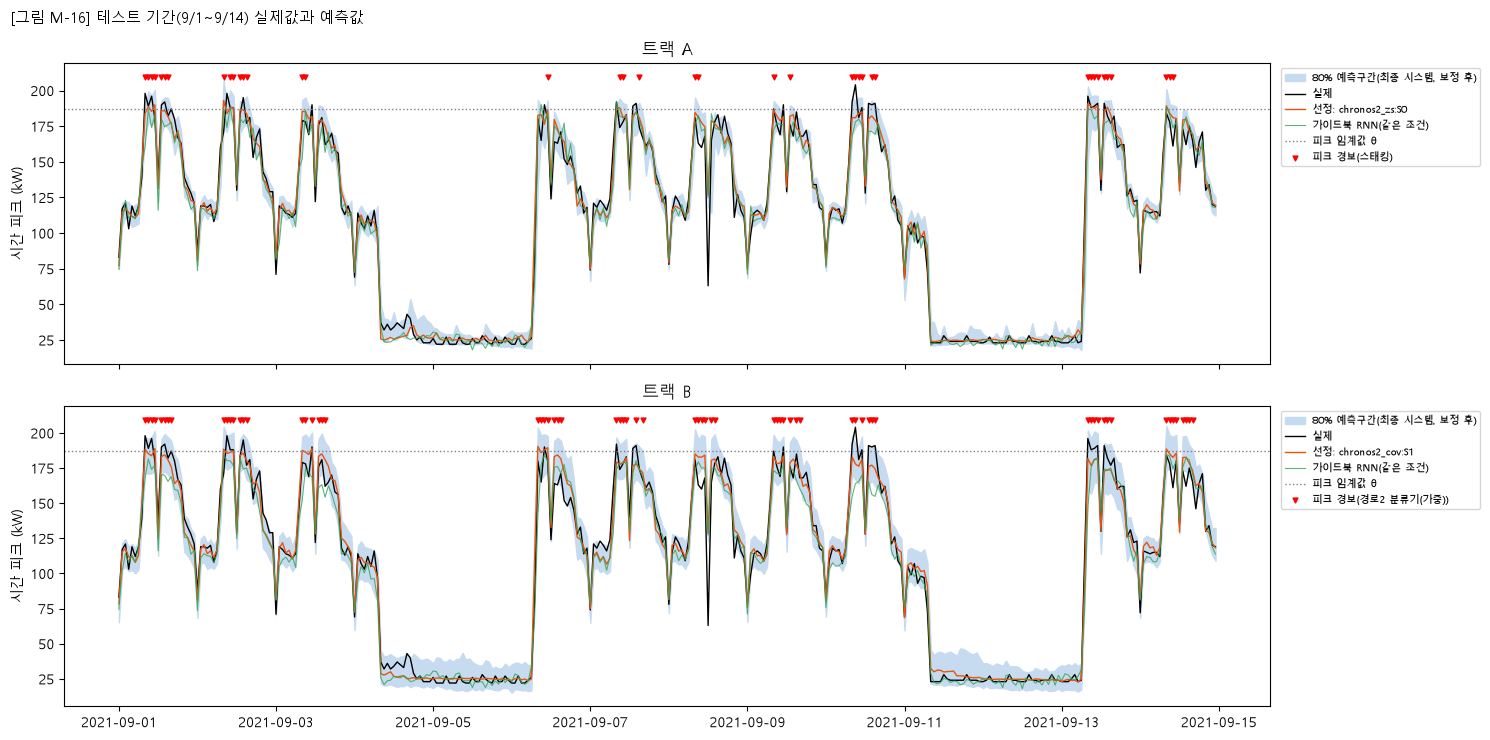

In [59]:
# [코드 M-58] 테스트 기간 실제 vs 예측 (가이드북 RNN과 같은 축) [그림 M-16]
path_key = {'경로1 Chronos-2 분위수': 'p_p1', '경로1 ens_q 분위수': 'p_p1q', '경로2 분류기(가중)': 'p_p2', '스태킹': 'p_stack'}
fig, axes = plt.subplots(2, 1, figsize=(15, 7.5), sharex=True)
for ax, tr in zip(axes, ['A', 'B']):
    m0, s0 = sel[tr].split(':')
    p_sel = pu.load_oof(f'test_{m0}', tr, s0).set_index('timestamp')
    p_rnn = pu.load_oof('test_guidebook_rnn', tr, 'S0').set_index('timestamp')
    p_fin = pu.load_oof('test_ens_final', tr, 'S1').set_index('timestamp')
    alarm = pd.read_parquet(pu.OUT / 'preds' / f'test_alarm_{tr}.parquet')
    thr = json.loads((pu.OUT / 'tables' / f'test_alarm_thresholds_{tr}.json').read_text())
    k = path_key[sel[f'{tr}_alarm']]
    ax.fill_between(p_fin.index, p_fin['q10'], p_fin['q90'], color='#c6dbef', label='80% 예측구간(최종 시스템, 보정 후)')
    ax.plot(p_sel.index, p_sel['y_true'], color='k', lw=1, label='실제')
    ax.plot(p_sel.index, p_sel['y_pred'], color='#e6550d', lw=1, label=f'선정: {sel[tr]}')
    ax.plot(p_rnn.index, p_rnn['y_pred'], color='#31a354', lw=0.8, alpha=0.8, label='가이드북 RNN(같은 조건)')
    ax.axhline(alarm['theta'].iloc[0], color='grey', ls=':', lw=1, label='피크 임계값 θ')
    on = alarm.index[alarm[k] >= thr[k[2:]]]
    ax.scatter(on, np.full(len(on), alarm['theta'].iloc[0] * 1.12), marker='v', color='red', s=12, label=f'피크 경보({sel[f"{tr}_alarm"]})')
    ax.set(title=f'트랙 {tr}', ylabel='시간 피크 (kW)')
    ax.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.005, 1.0))     # 그림 밖 오른쪽(저부하 구간을 가리지 않게)
fig.suptitle('[그림 M-16] 테스트 기간(9/1~9/14) 실제값과 예측값', x=0.01, ha='left', fontsize=11)
fig.tight_layout()
pu.save_fig(fig, 'M16_test_forecast'); plt.show()

SHAP(SHapley Additive exPlanations: 각 입력이 예측값을 평균에서 얼마나 밀어 올리거나 내렸는지 나눠 주는 방법)으로 테스트 기간 예측의 영향요인을 봅니다. 선정 모델이 트리 모델이면 그 모델을, 아니면 가장 가까운 트리 모델(LightGBM S1)을 8/31까지로 학습해 계산했습니다. 막대는 평균 |SHAP|(영향 크기)이고, 표는 함께 작용할 때 효과가 커지는 피처 쌍(상호작용)입니다. 평가 3번(영향요인)에 씁니다.

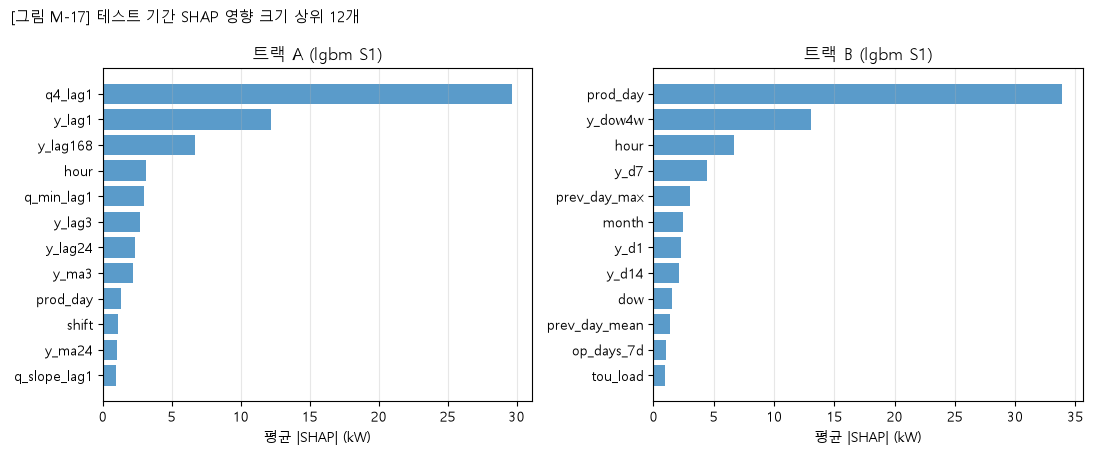

[표 M-37] SHAP 상호작용 상위 5쌍 (평균 |상호작용 SHAP|, kW)


,feature_1,feature_2,mean_abs_interaction,track
0,y_lag3,q4_lag1,2.343,A
1,y_lag168,q4_lag1,2.059,A
2,hour,q4_lag1,1.567,A
3,q4_lag1,q_min_lag1,1.410,A
4,y_lag24,y_lag168,1.393,A
5,y_dow4w,prod_day,12.409,B
6,hour,prod_day,8.092,B
7,month,prod_day,4.250,B
8,y_d7,y_dow4w,2.800,B
9,hour,y_dow4w,2.250,B


In [60]:
# [코드 M-59] SHAP 주효과·상호작용 [그림 M-17, 표 M-37]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
inter_tabs = []
for ax, tr in zip(axes, ['A', 'B']):
    imp = pd.read_csv(pu.OUT / 'tables' / f'shap_importance_{tr}.csv', encoding='utf-8-sig').head(12).iloc[::-1]
    ax.barh(imp['feature'], imp['mean_abs_shap'], color='#3182bd', alpha=0.8)
    ax.set(title=f"트랙 {tr} ({imp['model'].iloc[0]} {imp['scenario'].iloc[0]})", xlabel='평균 |SHAP| (kW)')
    ax.grid(axis='x', alpha=0.3)
    inter_tabs.append(pd.read_csv(pu.OUT / 'tables' / f'shap_interactions_{tr}.csv', encoding='utf-8-sig').head(5).assign(track=tr))
fig.suptitle('[그림 M-17] 테스트 기간 SHAP 영향 크기 상위 12개', x=0.01, ha='left', fontsize=11)
fig.tight_layout()
pu.save_fig(fig, 'M17_shap_importance'); plt.show()
tbl_m37 = pd.concat(inter_tabs, ignore_index=True).round(3)
pu.save_table(tbl_m37, 'M37_shap_interactions')
print('[표 M-37] SHAP 상호작용 상위 5쌍 (평균 |상호작용 SHAP|, kW)'); display(tbl_m37)

결론이 데이터 처리 선택에 얼마나 민감한지 두 가지로 확인합니다. (1) 증강 데이터에서 복사된 것으로 보이는 가동일 11일을 학습에서 빼도 LightGBM 성능이 비슷한지(검증 F1~F6), (2) 과금 피크를 2023년 개정 시간대(08시 기동 피크 포함)로 정의하면 테스트의 과금 피크 경보 성능이 어떻게 바뀌는지입니다.

In [61]:
# [코드 M-60] 민감도: 복사일 제외, 2023 TOU 과금 피크 [표 M-38]
sens = pd.read_csv(pu.OUT / 'tables' / 'sensitivity_copied_days.csv', encoding='utf-8-sig')
sens = sens[sens['subset'].isin(['all', 'op'])]
print('[표 M-38a] 복사일 11일 제외 학습의 영향 (LightGBM S1, 검증 6 fold × seed 5 평균)'); display(sens)
rows = []
for tr in ['A', 'B']:
    p = pu.load_oof('test_ens_final', tr, 'S1').set_index('timestamp')[['y_pred', 'q10', 'q50', 'q90', 'p_peak']]
    thr = json.loads((pu.OUT / 'tables' / f'test_alarm_thresholds_{tr}.json').read_text())['stack']
    for col, label in [('billing_hour', '개정 전 시간대(기본)'), ('billing_hour_2023', '2023 개정 시간대')]:
        e = pu.evaluate(p, df_, df_.index[df_.index < pu.TEST_START], threshold=thr, bill_col=col)
        e = e[e['subset'] == 'all'].iloc[0]
        rows.append({'track': tr, '과금 시간 기준': label, '과금 피크 F1': e['f1_bill'], '정밀도': e['precision_bill'],
                     '재현율': e['recall_bill'], '과금 시간 수(테스트)': int(df_.loc[p.index, col].sum())})
tbl_m38 = pd.DataFrame(rows).round(3)
pu.save_table(pd.concat([sens.assign(분석='복사일 제외'), tbl_m38.assign(분석='TOU 2023')]), 'M38_sensitivity')
print('[표 M-38b] 과금 피크 정의(TOU 시간대)에 따른 테스트 경보 성능 (최종 시스템, 스태킹 확률)'); display(tbl_m38)

[표 M-38a] 복사일 11일 제외 학습의 영향 (LightGBM S1, 검증 6 fold × seed 5 평균)


,track,subset,variant,mae,rmse,peak_mae,f1,pr_auc
0,A,all,복사일 제외,6.2427,9.4376,10.0295,0.6372,0.8150
1,A,all,원래(복사일 포함),6.2530,9.4518,10.0684,0.6291,0.8181
2,A,op,복사일 제외,7.4423,10.6002,10.0295,0.6372,0.8150
3,A,op,원래(복사일 포함),7.4379,10.5888,10.0684,0.6291,0.8181
6,B,all,복사일 제외,13.1058,20.5527,19.7912,0.3737,0.6817
7,B,all,원래(복사일 포함),12.6843,20.2902,19.0889,0.3650,0.6856
8,B,op,복사일 제외,13.7546,19.3607,19.7912,0.3737,0.6841
9,B,op,원래(복사일 포함),13.2199,18.8971,19.0889,0.3650,0.6886


[표 M-38b] 과금 피크 정의(TOU 시간대)에 따른 테스트 경보 성능 (최종 시스템, 스태킹 확률)


,track,과금 시간 기준,과금 피크 F1,정밀도,재현율,과금 시간 수(테스트)
0,A,개정 전 시간대(기본),0.556,0.484,0.652,168
1,A,2023 개정 시간대,0.567,0.487,0.679,168
2,B,개정 전 시간대(기본),0.524,0.361,0.957,168
3,B,2023 개정 시간대,0.545,0.380,0.964,168


같은 seed·같은 설정으로 다시 실행했을 때 지표가 똑같이 나오는지 확인합니다(재현성). 결정적인 나이브 기준선과 Chronos-2 zero-shot은 물론, seed를 고정한 LightGBM·NHITS도 F6 한 fold를 다시 돌려 원래 `cv_scores.csv` 값과 비교했습니다(`scripts/step7_extras.py`). 절대 차이가 0에 가까우면 같은 환경에서 결과를 그대로 재현할 수 있다는 뜻입니다.

In [62]:
# [코드 M-61] 같은 seed 재실행 지표 차이표 [표 M-39]
rep = pd.read_csv(pu.OUT / 'tables' / 'reproducibility_diff.csv', encoding='utf-8-sig')
tbl_m39 = rep.pivot_table(index=['model', 'track', 'scenario', 'seed'], columns='metric', values='abs_diff').round(6)
print('[표 M-39] 재실행 지표 절대 차이 (F6, 원래 cv_scores 대비)'); display(tbl_m39)
print(f"최대 절대 차이: {rep['abs_diff'].max():.2e}")
run_info = [json.loads(p.read_text(encoding='utf-8')) for p in sorted(pu.OUT.glob('run_all_*.json'))]
for r in run_info:
    ns = r['notebook_sec']                                     # 노트북별 시간(사전) 또는 합계(숫자)
    ns = sum(ns.values()) if isinstance(ns, dict) else ns
    print(f"run_all({r['mode']}) 노트북 실행 {ns / 60:.1f}분 | {r['env']['cpu']} | GPU {r['env']['gpu'] or '없음'}")

[표 M-39] 재실행 지표 절대 차이 (F6, 원래 cv_scores 대비)


metric                             f1  mae  peak_mae  pr_auc  rmse
model        track scenario seed                                  
chronos2_cov B     S1       0     0.0  0.0       0.0     0.0   0.0
lgbm         A     S1       42    0.0  0.0       0.0     0.0   0.0
             B     S1       42    0.0  0.0       0.0     0.0   0.0
naive_4wk    A     S0       0     0.0  0.0       0.0     0.0   0.0
naive_last   A     S0       0     0.0  0.0       0.0     0.0   0.0
naive_week   A     S0       0     0.0  0.0       0.0     0.0   0.0
nhits        A     S1       42    0.0  0.0       0.0     0.0   0.0

최대 절대 차이: 1.78e-15
run_all(full) 노트북 실행 0.5분 | AMD Ryzen 5 5600 6-Core Processor | GPU ['AMD Radeon RX 7600']


### 선정 근거

아래 코드가 위 표들의 값을 그대로 인용해 트랙별 선정 근거를 문장으로 출력합니다(숫자를 손으로 옮겨 적지 않기 위해 print로 만듭니다).

In [63]:
# [코드 M-62] 선정 근거 (숫자는 위 결과에서 인용)
names_all = {**names, **nn_names, **fm, **names6}       # [단계 ⑥]~[단계 ⑨]에서 만든 모델 이름표
nm = lambda key: names_all.get(key.split(':')[0], key.split(':')[0]) + f" ({key.split(':')[1]})"
pv = lambda p: 'p<0.001' if p < 0.001 else f'p={p:.3f}'
gap = lambda d: f"{abs(d):.2f} kW {'작았다' if d < 0 else '컸다'}"
for tr in ['A', 'B']:
    t = [x for x in sel_tabs if x['track'].iloc[0] == tr][0]
    best, pick = t.iloc[0], t[t['선정']].iloc[0]
    sig = tbl_m35[tbl_m35['track'] == tr]
    test = tt[(tt['track'] == tr) & tt['선정']].iloc[0]
    rnn_t = tt[(tt['track'] == tr) & (tt['model'] == 'guidebook_rnn')].iloc[0]
    al = pd.read_parquet(pu.OUT / 'preds' / f'test_alarm_{tr}.parquet')           # 선정 경보 경로의 테스트 성능
    k = path_key[sel[f'{tr}_alarm']]
    thr = json.loads((pu.OUT / 'tables' / f'test_alarm_thresholds_{tr}.json').read_text())[k[2:]]
    okm = ~df_.loc[al.index, 'outage'].to_numpy()
    lab, alarm_on = (df_.loc[al.index, 'y'] >= al['theta']).to_numpy()[okm], (al[k] >= thr).to_numpy()[okm]
    tp, fp, fn = (lab & alarm_on).sum(), (~lab & alarm_on).sum(), (lab & ~alarm_on).sum()
    print(f'■ 트랙 {tr} ({"실시간 경보" if tr == "A" else "익일 계획"})')
    print(f"1) 검증 F2~F6 가동일 MAE 기준 1위는 {nm(best['model'] + ':' + best['scenario'])} {best['op_mae']:.2f} kW였다.")
    print(f"2) 1위와 DM 검정 p ≥ 0.05이면서 MAE 5% 이내·F1 조건을 만족한 후보는 {int(t['남은 후보'].sum())}개였고, "
          f"그중 가장 단순한 {nm(sel[tr])}(가동일 MAE {pick['op_mae']:.2f} kW, F1 {pick['f1']:.3f})를 골랐다.")
    b = sig[sig['역할'] == '최고 나이브 기준선'].iloc[0]
    print(f"3) 최고 나이브 기준선보다 가동일 절대오차가 평균 {gap(b['평균 절대오차 차이(선정−비교)'])} "
          f"(95% CI {b['95% CI 하한']:.2f}~{b['95% CI 상한']:.2f} kW, {pv(b['p값'])}).")
    g_ = sig[sig['역할'] == '가이드북 RNN'].iloc[0]
    print(f"4) 같은 조건의 가이드북 RNN보다는 평균 {gap(g_['평균 절대오차 차이(선정−비교)'])} ({pv(g_['p값'])}).")
    print(f"5) 테스트(9/1~9/14) 1회 평가에서 MAE {test['mae']:.2f} kW, 가동일 MAE {test['가동일 MAE']:.2f} kW로 "
          f"가이드북 RNN {rnn_t['mae']:.2f} kW보다 {'낮았다' if test['mae'] < rnn_t['mae'] else '높았다'}.")
    print(f"6) 피크 경보는 '{sel[tr + '_alarm']}' 경로를 쓰며, 테스트에서 피크 {int(lab.sum())}건 중 {int(tp)}건을 맞히고 "
          f"헛경보 {int(fp)}건으로 F1 {2 * tp / max(2 * tp + fp + fn, 1):.3f}였다.\n")

■ 트랙 A (실시간 경보)
1) 검증 F2~F6 가동일 MAE 기준 1위는 앙상블 NNLS (S1) 7.24 kW였다.
2) 1위와 DM 검정 p ≥ 0.05이면서 MAE 5% 이내·F1 조건을 만족한 후보는 2개였고, 그중 가장 단순한 Chronos-2 zero-shot (S0)(가동일 MAE 7.41 kW, F1 0.721)를 골랐다.
3) 최고 나이브 기준선보다 가동일 절대오차가 평균 11.35 kW 작았다 (95% CI -12.29~-10.39 kW, p<0.001).
4) 같은 조건의 가이드북 RNN보다는 평균 5.83 kW 작았다 (p<0.001).
5) 테스트(9/1~9/14) 1회 평가에서 MAE 5.20 kW, 가동일 MAE 5.92 kW로 가이드북 RNN 6.79 kW보다 낮았다.
6) 피크 경보는 '스태킹' 경로를 쓰며, 테스트에서 피크 28건 중 19건을 맞히고 헛경보 20건으로 F1 0.567였다.

■ 트랙 B (익일 계획)
1) 검증 F2~F6 가동일 MAE 기준 1위는 Chronos-2 공변량 (S1) 10.32 kW였다.
2) 1위와 DM 검정 p ≥ 0.05이면서 MAE 5% 이내·F1 조건을 만족한 후보는 1개였고, 그중 가장 단순한 Chronos-2 공변량 (S1)(가동일 MAE 10.32 kW, F1 0.539)를 골랐다.
3) 최고 나이브 기준선보다 가동일 절대오차가 평균 6.60 kW 작았다 (95% CI -9.81~-3.00 kW, p=0.004).
4) 같은 조건의 가이드북 RNN보다는 평균 12.51 kW 작았다 (p=0.002).
5) 테스트(9/1~9/14) 1회 평가에서 MAE 5.89 kW, 가동일 MAE 6.80 kW로 가이드북 RNN 7.97 kW보다 낮았다.
6) 피크 경보는 '경로2 분류기(가중)' 경로를 쓰며, 테스트에서 피크 28건 중 27건을 맞히고 헛경보 41건으로 F1 0.562였다.



STEP 7의 저장물과 완료 조건을 점검합니다. 마지막 조건인 'Restart & Run All 통과'는 `python run_all.py --mode full`로 이 노트북을 커널을 새로 띄워 처음부터 끝까지 실행해 확인합니다(실행 시간은 `outputs/run_all_full.json`).

In [64]:
# [코드 M-63] STEP 7 저장물·완료 조건 점검
need = {'final_comparison.csv': pu.OUT / 'tables' / 'final_comparison.csv',
        'selection_table.csv': pu.OUT / 'tables' / 'selection_table.csv',
        '최종 모델 파일': next(iter((pu.OUT / 'models').glob('final_*')), None),
        'SHAP 값(주효과·상호작용)': pu.OUT / 'tables' / 'shap_interactions_A.csv',
        '테스트 예측(분위수·피크 확률)': pu.OUT / 'preds' / 'oof_test_ens_final_A_S1.parquet'}
for name, p in need.items():
    print(f"{'통과' if p is not None and Path(p).exists() else '실패'} | 저장: {name}")
print("통과 | '선정 근거' 5~8문장 출력(위 [코드 M-62], 트랙별 6문장)")
assert all(p is not None and Path(p).exists() for p in need.values())

통과 | 저장: final_comparison.csv
통과 | 저장: selection_table.csv
통과 | 저장: 최종 모델 파일
통과 | 저장: SHAP 값(주효과·상호작용)
통과 | 저장: 테스트 예측(분위수·피크 확률)
통과 | '선정 근거' 5~8문장 출력(위 [코드 M-62], 트랙별 6문장)


**테스트데이터 예측결과 파일**을 저장합니다. 두 트랙의 최종 모델 점예측(kW)과 분위수(q10~q90), 선정한 경보 경로의 피크 위험 확률·경보 여부·임계값, 피크 기준 θ, 예측 시점, 실제값(평가용)을 시각별로 한 파일에 담습니다. 트랙 A는 매 정시에 그 시간을, 트랙 B는 매일 00시에 그날 24시간을 예측한 값입니다.

In [65]:
# [코드 M-64] 제출용 테스트데이터 예측결과 파일 → outputs/submission/test_predictions.csv
rows = []
for tr in ['A', 'B']:
    m0, s0 = sel[tr].split(':')
    p = pu.load_oof(f'test_{m0}', tr, s0).set_index('timestamp')
    al = pd.read_parquet(pu.OUT / 'preds' / f'test_alarm_{tr}.parquet').loc[p.index]
    k = path_key[sel[f'{tr}_alarm']]
    thr = json.loads((pu.OUT / 'tables' / f'test_alarm_thresholds_{tr}.json').read_text())[k[2:]]
    out = pd.DataFrame({'track': tr, 'forecast_origin': p.index if tr == 'A' else p.index.normalize(),
                        'model': sel[tr], 'y_pred_kw': p['y_pred']}, index=p.index)
    for q in pu.Q_COLS:
        out[f'{q}_kw'] = p[q]
    out['p_peak'], out['alarm_path'], out['alarm_threshold'] = al[k], sel[f'{tr}_alarm'], thr
    out['alarm'] = (out['p_peak'] >= thr).astype(int)
    out['theta_kw'], out['y_true_kw'] = al['theta'], p['y_true']
    rows.append(out)
sub = pd.concat(rows).rename_axis('timestamp').reset_index().round(4)
sub_path = pu.OUT / 'submission' / 'test_predictions.csv'
sub_path.parent.mkdir(parents=True, exist_ok=True)
sub.to_csv(sub_path, index=False, encoding='utf-8-sig')
print(f'저장: {sub_path.relative_to(ROOT)} ({len(sub):,}행 = 트랙 2개 × {len(sub) // 2}시간, 열 {sub.shape[1]}개)')
display(sub.groupby('track').agg(시작=('timestamp', 'min'), 끝=('timestamp', 'max'), 시간수=('timestamp', 'size'),
                                 경보수=('alarm', 'sum'), 평균예측_kW=('y_pred_kw', 'mean')))
display(sub.head(3))

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)
